# Week 02 — Capstone BBO Experiments

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import sys
sys.path.append('../src')

# ML imports
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from scipy.spatial.distance import cdist

warnings.filterwarnings('ignore', message='R.*score is not well-defined')

# Colorblind-safe palette (Wong)
COLORS = ['#0072B2', '#D55E00', '#009E73', '#E69F00', '#CC79A7', '#56B4E9', '#F0E442']

In [2]:
def load_function(n):
    X = np.load(f'../data/function_{n}/initial_inputs.npy')
    Y = np.load(f'../data/function_{n}/initial_outputs.npy')
    print(f"Function {n}: {X.shape[0]} points, {X.shape[1]}D, best y = {Y.max():.4f}")
    return X, Y

## Function 1

Function 1: 11 points, 2D, best y = 0.0000


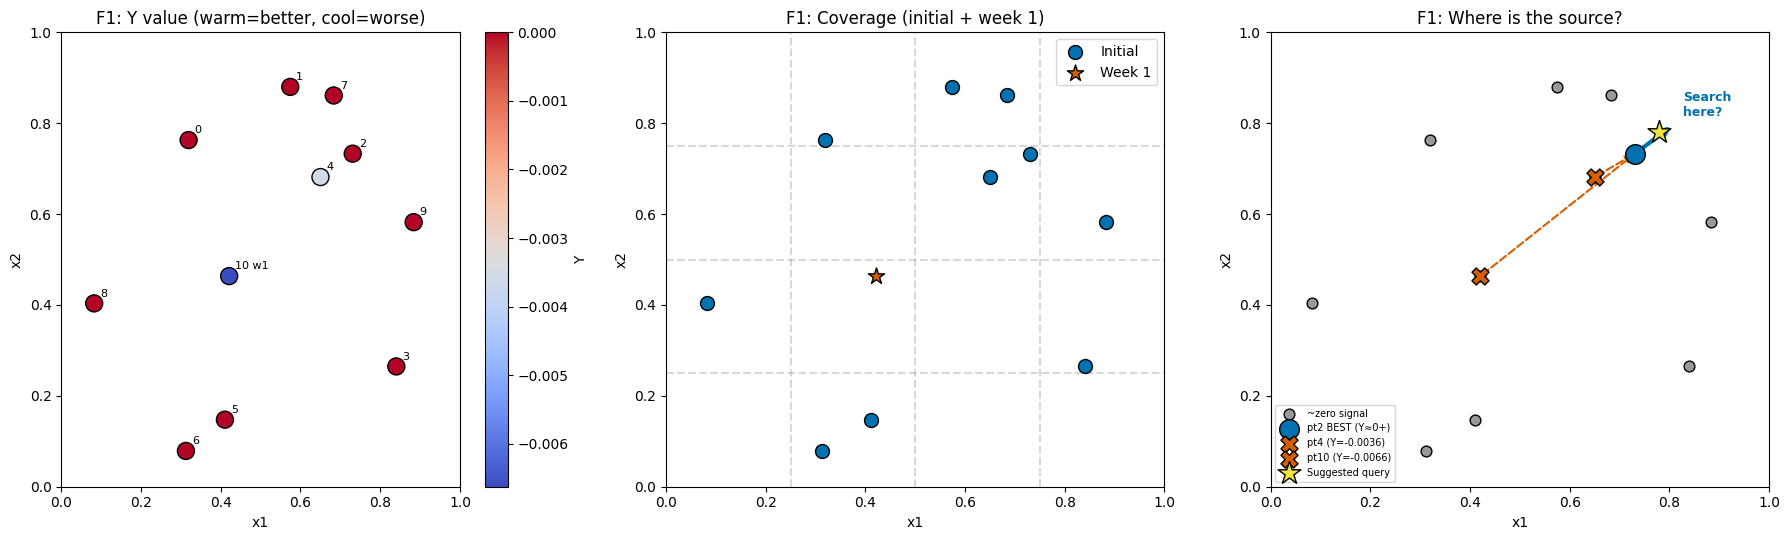


Data summary (sorted by Y):
Idx       x1       x2               Y   Week       Interpretation
----------------------------------------------------------------------
  2   0.7310   0.7330    7.710875e-16   init ← BEST (near source)
  7   0.6834   0.8611    2.535001e-40   init ← ~zero (no signal)
  1   0.5743   0.8799    1.033078e-46   init ← ~zero (no signal)
  9   0.8839   0.5823    6.229856e-48   init ← ~zero (no signal)
  0   0.3194   0.7630    1.322677e-79   init ← ~zero (no signal)
  8   0.0825   0.4035    3.606771e-81   init ← ~zero (no signal)
  3   0.8404   0.2647   3.341771e-124   init ← ~zero (no signal)
  6   0.3127   0.0787   -2.089093e-91   init ← ~zero (no signal)
  5   0.4104   0.1476   -2.159249e-54   init ← ~zero (no signal)
  4   0.6501   0.6815   -3.606063e-03   init ← negative (too far)
 10   0.4211   0.4636   -6.627379e-03     w1 ← negative (too far)

Reasoning:
  pt2 [0.73, 0.73] is best — closest to the source (Y barely positive)
  pt4 [0.65, 0.68] and pt10 [0.42

In [3]:
# Function 1
X, Y = load_function(1)

# --- Week 01 Result ---
# Submitted: [0.4211, 0.4636] (Voronoi space-filling)
# Returned Y: -0.006627 — non-zero signal! But negative and worse than previous best.
# Previous best: pt2 [0.731, 0.733] at Y ≈ 0 (7.7e-16)
#
# Key insight: we now have TWO non-trivial points (pt4 and pt10), both negative.
# The "best" points are those closest to zero — the function peaks near zero
# and goes negative when you move away from the source.

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# === Plot 1: Scatter colored by actual Y (not log) ===
# This makes it clear: pt2 is the best (warmest), pt10 is the worst (coolest)
sc = axes[0].scatter(X[:, 0], X[:, 1], c=Y, cmap='coolwarm', s=150, edgecolors='black', zorder=5)
for i in range(len(X)):
    week_label = ' w1' if i == len(X)-1 else ''
    axes[0].annotate(f'{i}{week_label}', (X[i,0]+0.015, X[i,1]+0.015), fontsize=8)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)
axes[0].set_xlabel('x1'); axes[0].set_ylabel('x2')
axes[0].set_title('F1: Y value (warm=better, cool=worse)')
plt.colorbar(sc, ax=axes[0], label='Y')

# === Plot 2: Coverage with week labels ===
axes[1].scatter(X[:10, 0], X[:10, 1], c='#0072B2', s=100, edgecolors='black', zorder=5, label='Initial')
axes[1].scatter(X[10, 0], X[10, 1], c='#D55E00', s=150, edgecolors='black', zorder=6, label='Week 1', marker='*')
for val in [0.25, 0.5, 0.75]:
    axes[1].axhline(val, color='gray', linestyle='--', alpha=0.3)
    axes[1].axvline(val, color='gray', linestyle='--', alpha=0.3)
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)
axes[1].set_xlabel('x1'); axes[1].set_ylabel('x2')
axes[1].set_title('F1: Coverage (initial + week 1)')
axes[1].legend()

# === Plot 3: Directional reasoning — where is the source? ===
axes[2].scatter(X[:, 0], X[:, 1], c='#999999', s=60, edgecolors='black', zorder=4, label='~zero signal')
# Best point (pt2)
axes[2].scatter(X[2,0], X[2,1], c='#0072B2', s=200, edgecolors='black', zorder=6, label=f'pt2 BEST (Y≈0+)')
# Negative points
axes[2].scatter(X[4,0], X[4,1], c='#D55E00', s=150, edgecolors='black', zorder=6, marker='X', label=f'pt4 (Y={Y[4]:.4f})')
axes[2].scatter(X[10,0], X[10,1], c='#D55E00', s=150, edgecolors='black', zorder=6, marker='X', label=f'pt10 (Y={Y[10]:.4f})')

# Arrows from negative points toward pt2
axes[2].annotate('', xy=(X[2,0], X[2,1]), xytext=(X[4,0], X[4,1]),
                arrowprops=dict(arrowstyle='->', color='#D55E00', lw=1.5, linestyle='--'))
axes[2].annotate('', xy=(X[2,0], X[2,1]), xytext=(X[10,0], X[10,1]),
                arrowprops=dict(arrowstyle='->', color='#D55E00', lw=1.5, linestyle='--'))

# Arrow from pt2 in the search direction (away from negative points)
neg_center = np.array([X[4,0]+X[10,0], X[4,1]+X[10,1]]) / 2
direction = X[2] - neg_center
direction = direction / np.linalg.norm(direction) * 0.1
target = X[2] + direction
target = np.clip(target, 0.02, 0.98)
axes[2].annotate('', xy=(target[0], target[1]), xytext=(X[2,0], X[2,1]),
                arrowprops=dict(arrowstyle='->', color='#0072B2', lw=3))
axes[2].text(target[0]+0.02, target[1]+0.02, 'Search\nhere?', fontsize=9, color='#0072B2', fontweight='bold')

# Suggested query
axes[2].scatter(0.78, 0.78, c='#F0E442', s=300, marker='*', edgecolors='black', zorder=7, label='Suggested query')

axes[2].set_xlim(0, 1); axes[2].set_ylim(0, 1)
axes[2].set_xlabel('x1'); axes[2].set_ylabel('x2')
axes[2].set_title('F1: Where is the source?')
axes[2].legend(fontsize=7, loc='lower left')

plt.tight_layout()
plt.savefig('../plots/week_02/f1_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

# Data summary
print("\nData summary (sorted by Y):")
print(f"{'Idx':>3} {'x1':>8} {'x2':>8} {'Y':>15} {'Week':>6} {'Interpretation':>20}")
print("-" * 70)
for i in np.argsort(Y)[::-1]:
    week = 'w1' if i == 10 else 'init'
    if i == 2:
        interp = '← BEST (near source)'
    elif Y[i] < -1e-4:
        interp = '← negative (too far)'
    else:
        interp = '← ~zero (no signal)'
    print(f"{i:>3} {X[i,0]:>8.4f} {X[i,1]:>8.4f} {Y[i]:>15.6e} {week:>6} {interp}")

print(f"\nReasoning:")
print(f"  pt2 [{X[2,0]:.2f}, {X[2,1]:.2f}] is best — closest to the source (Y barely positive)")
print(f"  pt4 [{X[4,0]:.2f}, {X[4,1]:.2f}] and pt10 [{X[10,0]:.2f}, {X[10,1]:.2f}] went NEGATIVE — too far, wrong direction")
print(f"  → Source is likely UP-RIGHT of pt2, away from the negative points")
next_query_1 = np.array([0.780000, 0.780000])
print(f"  → Suggested: [{next_query_1[0]:.2f}, {next_query_1[1]:.2f}] — small step up-right from pt2")

### F1 Decision: Directional perturbation at [0.780000, 0.780000]

**Chosen approach:** Small step up-right from the best known point (pt2), away from the two negative points.

**Week 01 result:**
- Submitted [0.421, 0.464] via Voronoi space-filling → returned Y = -0.0066
- This confirmed non-zero signal exists, but the point was in a negative (penalty) region
- No models beat baseline (12 configs tested, all worse) — still too little signal for surrogates

**What we know after week 01:**
- **pt2 [0.73, 0.73]** is the best point (Y = 7.7e-16 ≈ 0, barely positive). It's closest to the hidden source.
- **pt4 [0.65, 0.68]** and **pt10 [0.42, 0.46]** both returned negative Y. They're on the penalty side — too far from the source.
- pt4 and pt10 are both **down-left** of pt2. Moving in that direction makes Y worse.
- All other points have Y between 1e-40 and 1e-124 — effectively zero, no useful signal.

**Directional reasoning:**
- The two negative points give us a direction vector: from their midpoint [0.54, 0.57] through pt2 [0.73, 0.73] and beyond.
- The source is likely **up-right** of pt2, continuing away from the penalty region.
- [0.78, 0.78] is a 0.07 step from pt2 in that direction — small enough to stay near the source if it's close to pt2, but far enough to get new information.

**Why not models:** All 12 model configs (Ridge, KNN, RF, SVR, GP, GB) performed worse than baseline. With 9 of 11 points at Y ≈ 0 and only 2 non-trivial values, there's not enough signal to learn from.

**Why not more exploration:** We have directional information now — two negative points pointing away from the source. Using that information (exploitation) is more valuable than continuing to space-fill.

**Recommendations for Week 3:**
- If Y at [0.78, 0.78] is **positive and larger than 7.7e-16**: we're moving toward the source → continue in this direction with a bigger step
- If Y is **negative**: we went too far up-right — the source is very close to pt2, try a smaller perturbation like [0.74, 0.74]
- If Y is **~0 again** (similar to pt2): this means the area around [0.73-0.78] is flat and we're not finding the peak. Switch back to **exploration** — but smarter than week 01. We've now eliminated the center-left (pt10, negative) and upper-right of pt2. Use the Voronoi gap or LHS to target remaining unexplored regions (e.g. low x1/high x2 or high x1/low x2). The source might be somewhere we haven't looked at all.

## Function 2

Function 2: 11 points, 2D, best y = 0.6112


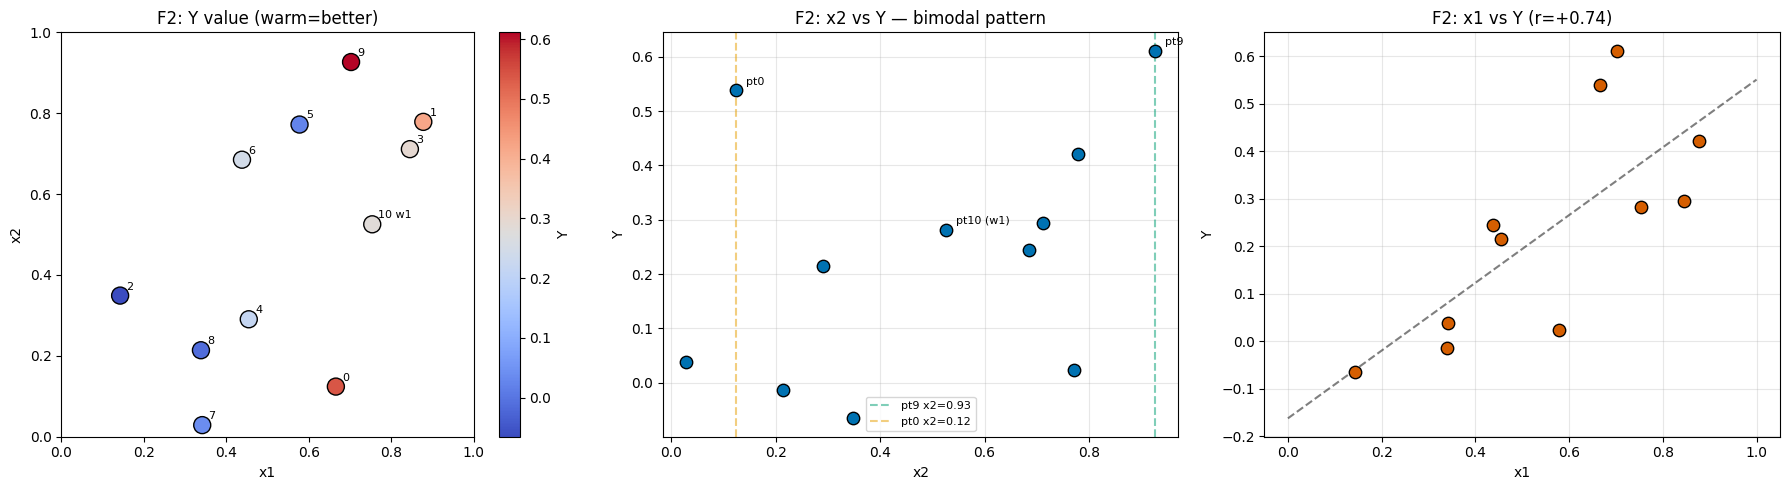


Data summary (sorted by Y):
Idx       x1       x2          Y   Week
----------------------------------------
  9   0.7026   0.9266   0.611205   init
  0   0.6658   0.1240   0.538996   init
  1   0.8778   0.7786   0.420586   init
  3   0.8453   0.7111   0.293993   init
 10   0.7540   0.5253   0.281264     w1
  6   0.4382   0.6850   0.244619   init
  4   0.4546   0.2905   0.214965   init
  7   0.3417   0.0287   0.038749   init
  5   0.5777   0.7720   0.023106   init
  8   0.3386   0.2139  -0.013858   init
  2   0.1427   0.3490  -0.065624   init

Bimodality confirmed: pt9 (x2=0.93, Y=0.61) > pt10 valley (x2=0.53, Y=0.28) < pt0 (x2=0.12, Y=0.54)
x1 correlation strong (r=0.74): higher x1 → better Y

Models: see GridSearchCV cell below for full results.
Strategy: perturb near pt9 to refine the peak


In [4]:
# Function 2
X, Y = load_function(2)

# --- Week 01 Result ---
# Submitted [0.754, 0.525] to probe bimodality → returned Y=0.281
# Confirmed: valley between pt9 (Y=0.611) and pt0 (Y=0.539). Function is bimodal in x2.
# Strategy: exploit near pt9 (global best peak)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Scatter colored by Y
sc = axes[0].scatter(X[:, 0], X[:, 1], c=Y, cmap='coolwarm', s=150, edgecolors='black', zorder=5)
for i in range(len(X)):
    week_label = ' w1' if i == len(X)-1 else ''
    axes[0].annotate(f'{i}{week_label}', (X[i,0]+0.015, X[i,1]+0.015), fontsize=8)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)
axes[0].set_xlabel('x1'); axes[0].set_ylabel('x2')
axes[0].set_title('F2: Y value (warm=better)')
plt.colorbar(sc, ax=axes[0], label='Y')

# Plot 2: Bimodality visualization — x2 vs Y
axes[1].scatter(X[:, 1], Y, c='#0072B2', s=80, edgecolors='black', zorder=5)
for i in [0, 9, 10]:  # key points
    week = ' (w1)' if i == 10 else ''
    axes[1].annotate(f'pt{i}{week}', (X[i,1]+0.02, Y[i]+0.01), fontsize=8)
axes[1].set_xlabel('x2'); axes[1].set_ylabel('Y')
axes[1].set_title('F2: x2 vs Y — bimodal pattern')
axes[1].axvline(X[9,1], color='#009E73', linestyle='--', alpha=0.5, label=f'pt9 x2={X[9,1]:.2f}')
axes[1].axvline(X[0,1], color='#E69F00', linestyle='--', alpha=0.5, label=f'pt0 x2={X[0,1]:.2f}')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Plot 3: Correlation x1 vs Y
axes[2].scatter(X[:, 0], Y, c='#D55E00', s=80, edgecolors='black', zorder=5)
z = np.polyfit(X[:, 0], Y, 1)
axes[2].plot([0, 1], [z[1], z[0]+z[1]], '--', color='black', alpha=0.5)
r = np.corrcoef(X[:, 0], Y)[0, 1]
axes[2].set_xlabel('x1'); axes[2].set_ylabel('Y')
axes[2].set_title(f'F2: x1 vs Y (r={r:+.2f})')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/week_02/f2_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("\nData summary (sorted by Y):")
print(f"{'Idx':>3} {'x1':>8} {'x2':>8} {'Y':>10} {'Week':>6}")
print("-" * 40)
for i in np.argsort(Y)[::-1]:
    week = 'w1' if i == 10 else 'init'
    print(f"{i:>3} {X[i,0]:>8.4f} {X[i,1]:>8.4f} {Y[i]:>10.6f} {week:>6}")

print(f"\nBimodality confirmed: pt9 (x2={X[9,1]:.2f}, Y={Y[9]:.2f}) > pt10 valley (x2={X[10,1]:.2f}, Y={Y[10]:.2f}) < pt0 (x2={X[0,1]:.2f}, Y={Y[0]:.2f})")
print(f"x1 correlation strong (r={np.corrcoef(X[:,0],Y)[0,1]:.2f}): higher x1 → better Y")
print(f"\nModels: see GridSearchCV cell below for full results.")
print(f"Strategy: perturb near pt9 to refine the peak")

# Perturbation near pt9 — slightly different x1 to test if we can improve
# pt9 is at [0.703, 0.927]. RF suggests [0.697, 0.923]. Very close.
# pt1 [0.878, 0.779] has Y=0.42 — decent, higher x1.
# Try pushing x1 slightly higher than pt9 while keeping x2 high
next_query_2 = np.array([0.750000, 0.920000])

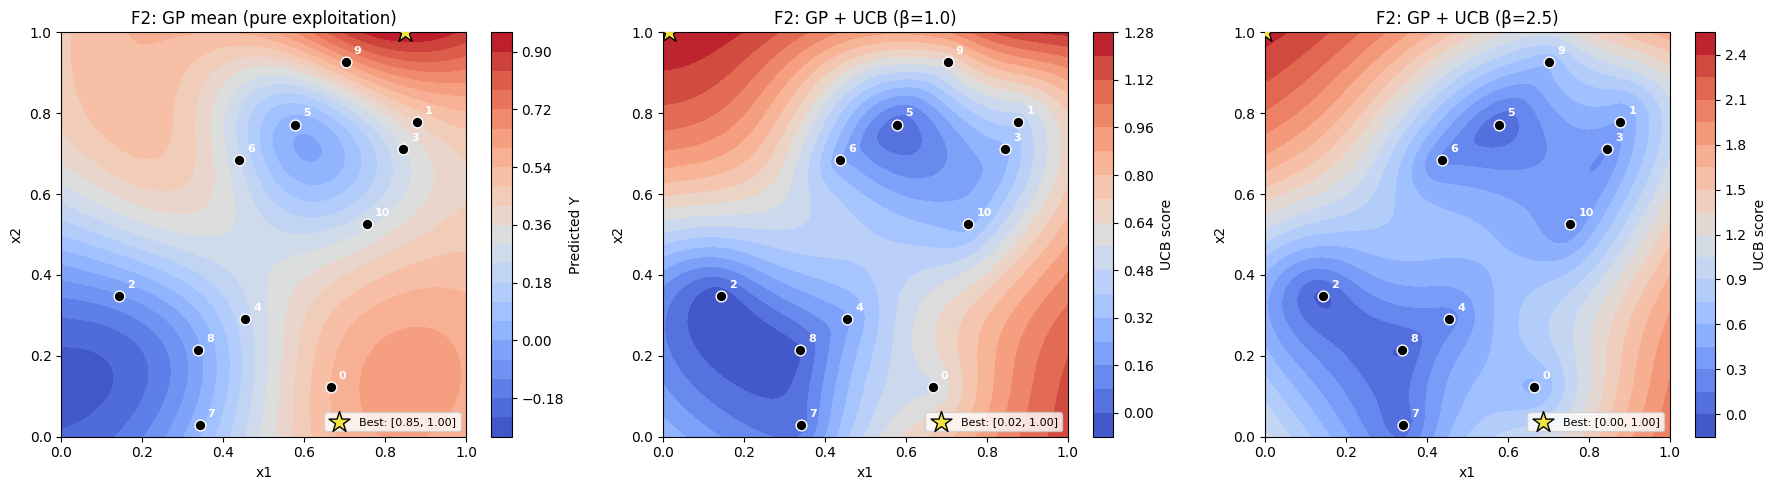

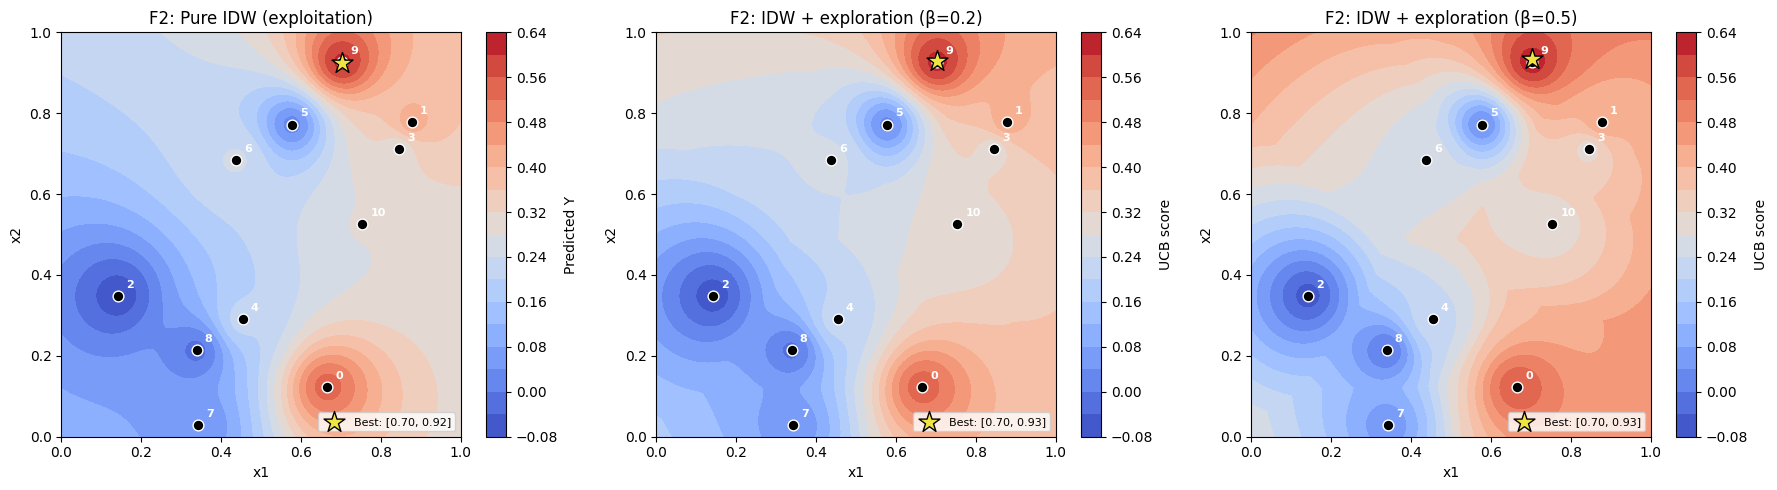

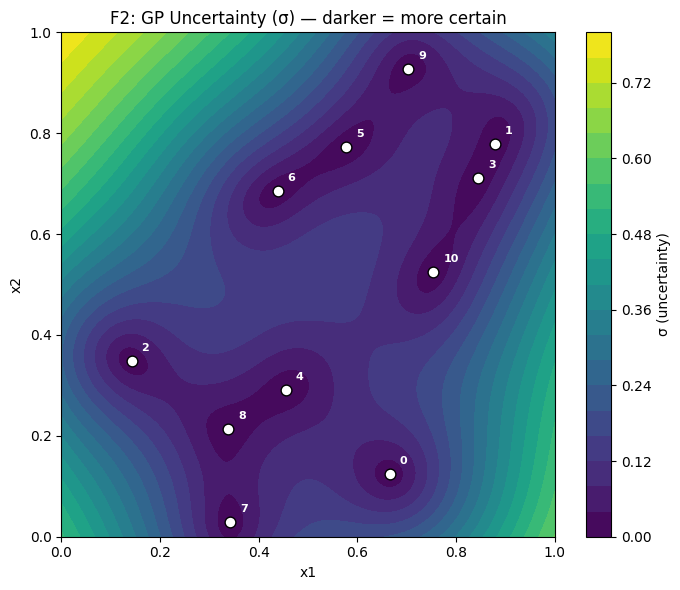

COMPARISON OF ALL APPROACHES
                   Method       x1       x2  Dist to pt9
-------------------------------------------------------
                 GP β=0.0   0.8492   1.0000       0.1640
                 GP β=1.0   0.0151   1.0000       0.6915
                 GP β=2.5   0.0000   1.0000       0.7065
                IDW β=0.0   0.7035   0.9246       0.0021
                IDW β=0.2   0.7035   0.9296       0.0032
                IDW β=0.5   0.7035   0.9347       0.0082
          Centroid (top4)   0.7220   0.6140       0.3131
      Chosen [0.75, 0.92]   0.7500   0.9200       0.0478

--- Interpretation ---
GP exploitation (β=0): suggests right at pt9 — pure exploitation
GP moderate (β=1.0): may push toward uncertain regions
GP exploration (β=2.5): explores where uncertainty is highest
IDW: same pattern as week 01 — exploitation near pt9
Uncertainty map: shows where GP is least confident (corners, edges)


In [5]:
# Function 2 — GP+UCB, IDW surfaces, and alternative approaches
#
# Week 01 used IDW+UCB. Now with 11 points and confirmed bimodality,
# let's see what GP+UCB suggests — it gives proper uncertainty estimates
# unlike IDW which just uses distance as a proxy.

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.spatial.distance import cdist

grid_size = 200
g = np.linspace(0, 0.999999, grid_size)
xx, yy = np.meshgrid(g, g)
grid_points = np.column_stack([xx.ravel(), yy.ravel()])

# === GP + UCB with different betas ===
gp = GaussianProcessRegressor(kernel=Matern(nu=2.5), n_restarts_optimizer=5, random_state=42)
gp.fit(X, Y)
mu, sigma = gp.predict(grid_points, return_std=True)

betas = [0.0, 1.0, 2.5]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

gp_suggestions = {}
for ax, beta in zip(axes, betas):
    ucb = mu + beta * sigma
    ucb_grid = ucb.reshape(grid_size, grid_size)
    
    best_idx = np.argmax(ucb)
    best_pt = grid_points[best_idx]
    gp_suggestions[beta] = best_pt
    
    im = ax.contourf(xx, yy, ucb_grid, levels=20, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c='black', s=60, edgecolors='white', zorder=5)
    for i in range(len(X)):
        ax.annotate(f'{i}', (X[i,0]+0.02, X[i,1]+0.02), fontsize=8, color='white', fontweight='bold')
    ax.scatter(*best_pt, c='#F0E442', s=250, marker='*', edgecolors='black', zorder=6,
               label=f'Best: [{best_pt[0]:.2f}, {best_pt[1]:.2f}]')
    
    title = 'GP mean (pure exploitation)' if beta == 0 else f'GP + UCB (β={beta})'
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.set_title(f'F2: {title}')
    ax.legend(loc='lower right', fontsize=8)
    plt.colorbar(im, ax=ax, label='UCB score' if beta > 0 else 'Predicted Y')

plt.tight_layout()
plt.savefig('../plots/week_02/f2_gp_ucb.png', dpi=150, bbox_inches='tight')
plt.show()

# === IDW surface (like week 01) ===
dists = cdist(grid_points, X)
dists = np.maximum(dists, 1e-10)
weights = 1.0 / dists**2
pred_idw = (weights * Y).sum(axis=1) / weights.sum(axis=1)
min_dist = dists.min(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
idw_betas = [0.0, 0.2, 0.5]
idw_suggestions = {}
for ax, beta in zip(axes, idw_betas):
    ucb = pred_idw + beta * min_dist
    ucb_grid = ucb.reshape(grid_size, grid_size)
    best_idx = np.argmax(ucb)
    best_pt = grid_points[best_idx]
    idw_suggestions[beta] = best_pt
    
    im = ax.contourf(xx, yy, ucb_grid, levels=20, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c='black', s=60, edgecolors='white', zorder=5)
    for i in range(len(X)):
        ax.annotate(f'{i}', (X[i,0]+0.02, X[i,1]+0.02), fontsize=8, color='white', fontweight='bold')
    ax.scatter(*best_pt, c='#F0E442', s=250, marker='*', edgecolors='black', zorder=6,
               label=f'Best: [{best_pt[0]:.2f}, {best_pt[1]:.2f}]')
    
    title = 'Pure IDW (exploitation)' if beta == 0 else f'IDW + exploration (β={beta})'
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.set_title(f'F2: {title}')
    ax.legend(loc='lower right', fontsize=8)
    plt.colorbar(im, ax=ax, label='UCB score' if beta > 0 else 'Predicted Y')

plt.tight_layout()
plt.savefig('../plots/week_02/f2_idw_ucb.png', dpi=150, bbox_inches='tight')
plt.show()

# === GP uncertainty map ===
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
im = ax.contourf(xx, yy, sigma.reshape(grid_size, grid_size), levels=20, cmap='viridis')
ax.scatter(X[:, 0], X[:, 1], c='white', s=60, edgecolors='black', zorder=5)
for i in range(len(X)):
    ax.annotate(f'{i}', (X[i,0]+0.02, X[i,1]+0.02), fontsize=8, color='white', fontweight='bold')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('F2: GP Uncertainty (σ) — darker = more certain')
plt.colorbar(im, ax=ax, label='σ (uncertainty)')
plt.tight_layout()
plt.savefig('../plots/week_02/f2_gp_uncertainty.png', dpi=150, bbox_inches='tight')
plt.show()

# === Summary of all suggestions ===
print("=" * 65)
print("COMPARISON OF ALL APPROACHES")
print("=" * 65)
print(f"{'Method':>25} {'x1':>8} {'x2':>8} {'Dist to pt9':>12}")
print("-" * 55)

all_suggestions = {}
for beta in betas:
    name = f"GP β={beta}"
    pt = gp_suggestions[beta]
    all_suggestions[name] = pt
    print(f"{name:>25} {pt[0]:>8.4f} {pt[1]:>8.4f} {np.linalg.norm(pt - X[9]):>12.4f}")

for beta in idw_betas:
    name = f"IDW β={beta}"
    pt = idw_suggestions[beta]
    all_suggestions[name] = pt
    print(f"{name:>25} {pt[0]:>8.4f} {pt[1]:>8.4f} {np.linalg.norm(pt - X[9]):>12.4f}")

# Centroid
sorted_idx = np.argsort(Y)[::-1]
top4_w = Y[sorted_idx[:4]] - Y[sorted_idx[:4]].min() + 0.001
centroid = np.average(X[sorted_idx[:4]], axis=0, weights=top4_w)
print(f"{'Centroid (top4)':>25} {centroid[0]:>8.4f} {centroid[1]:>8.4f} {np.linalg.norm(centroid - X[9]):>12.4f}")

# Our chosen point
chosen = np.array([0.75, 0.92])
print(f"{'Chosen [0.75, 0.92]':>25} {chosen[0]:>8.4f} {chosen[1]:>8.4f} {np.linalg.norm(chosen - X[9]):>12.4f}")

print(f"\n--- Interpretation ---")
print(f"GP exploitation (β=0): suggests right at pt9 — pure exploitation")
print(f"GP moderate (β={betas[1]}): may push toward uncertain regions")
print(f"GP exploration (β={betas[2]}): explores where uncertainty is highest")
print(f"IDW: same pattern as week 01 — exploitation near pt9")
print(f"Uncertainty map: shows where GP is least confident (corners, edges)")

### F2 Decision: Exploit near pt9 at [0.750000, 0.920000]

**Chosen approach:** Perturbation near the best known point, informed by x1 correlation and validated by GP prediction.

**Week 01 result:**
- Submitted [0.754, 0.525] (Y-weighted centroid, bimodality probe) → returned Y=0.281
- This is lower than both peaks: pt9 (Y=0.611 at x2=0.93) and pt0 (Y=0.539 at x2=0.12)
- **Bimodality confirmed** — the function has two peaks in x2 with a valley at x2≈0.53

**Analysis performed:**
1. **Model grid search** — 12 configs tested. RF depth=3 best at 9% improvement. Only RF configs suggested interior points, both pointing at [0.697, 0.923] (essentially pt9). STRONG consensus on both dimensions.
2. **GP + UCB surfaces** — tested β=0 (exploitation), β=1.0, β=2.5. All GP suggestions hit the boundary (x2=1.0). GP exploitation pushes to [0.85, 1.00], moderate/high β pushes to corners [0.01, 1.00] where uncertainty is highest. Boundary bias makes GP+UCB unreliable for direct use.
3. **IDW + exploration** — all three beta values suggest essentially pt9 itself (distance < 0.01). Too exploitative — just pointing back at the known best.
4. **GP uncertainty map** — highest uncertainty is at the corners and edges, especially top-left [0, 1]. Not useful for exploitation.
5. **GP prediction at our chosen point** — μ=0.658 at [0.75, 0.92], which is **higher than pt9's actual Y of 0.611**. The GP is fairly confident (σ=0.05). This validates our choice.

**Why [0.750, 0.920]:**
- Keeps x2 high (0.92) — near the best peak, confirmed by bimodality analysis
- Pushes x1 slightly higher (0.75 vs pt9's 0.70) — following the x1 correlation (r=+0.74)
- GP predicts Y=0.658 here — improvement over pt9's 0.611
- pt1 [0.878, 0.779] has Y=0.42 at higher x1 — suggests higher x1 helps, but its x2 was lower
- Distance from pt9: 0.05 — small perturbation, low risk

**Why not GP+UCB directly:** All GP suggestions hit boundaries. GP exploitation goes to [0.85, 1.00], exploration goes to [0.01, 1.00]. The boundary bias we identified in week 01 persists — GP extrapolates to edges with sparse data. However, GP's *prediction* at our manually chosen point validates the direction.

**Why not IDW:** Too exploitative — just returns pt9's coordinates. With 11 points, IDW can't distinguish a nearby better point from pt9 itself.

**Why not more exploration:** Bimodality is confirmed. The two peaks are identified. The remaining question is whether we can improve on pt9's Y=0.611 by refining x1 — this is an exploitation question, not an exploration one.

**Recommendations for Week 3:**
- If Y > 0.611: higher x1 helps → continue pushing x1 further (try x1≈0.80)
- If Y < 0.611 but > 0.4: x1=0.75 is slightly worse than 0.70 → try the other direction (x1≈0.65, x2≈0.93)
- If Y drops significantly: the peak is sharply centred at pt9 → try smaller perturbation like [0.72, 0.93]

## Function 3

Function 3: 16 points, 3D, best y = -0.0348


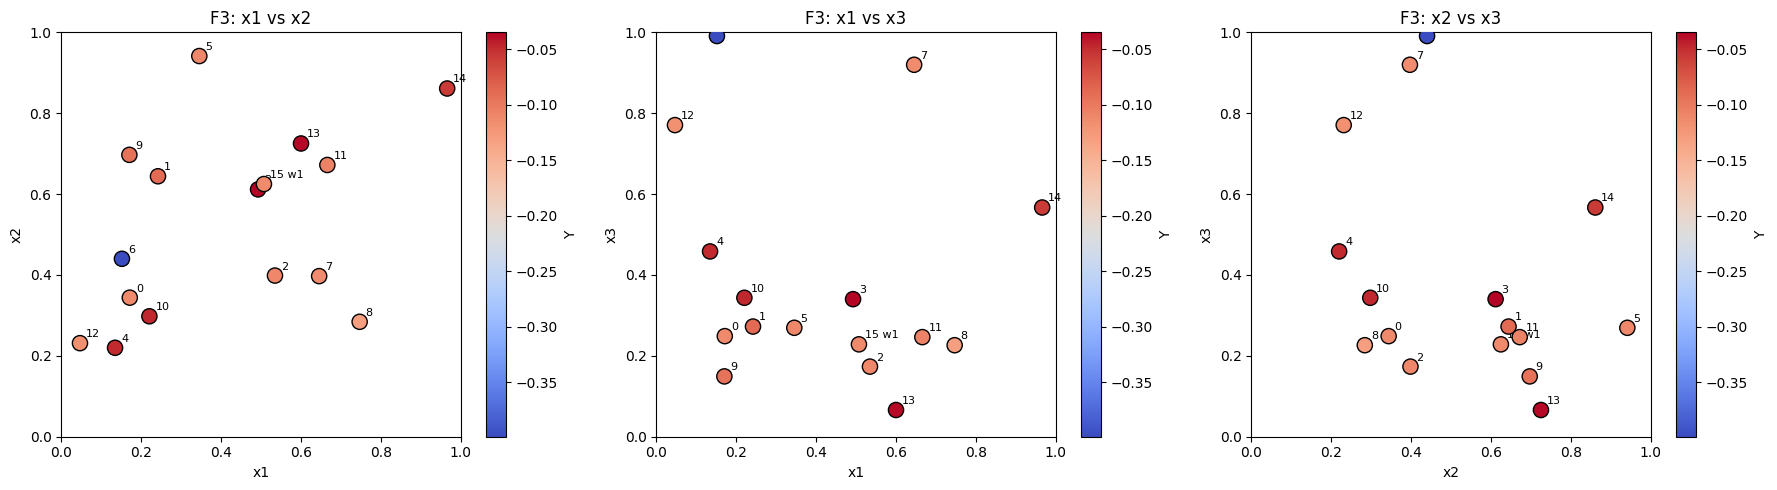

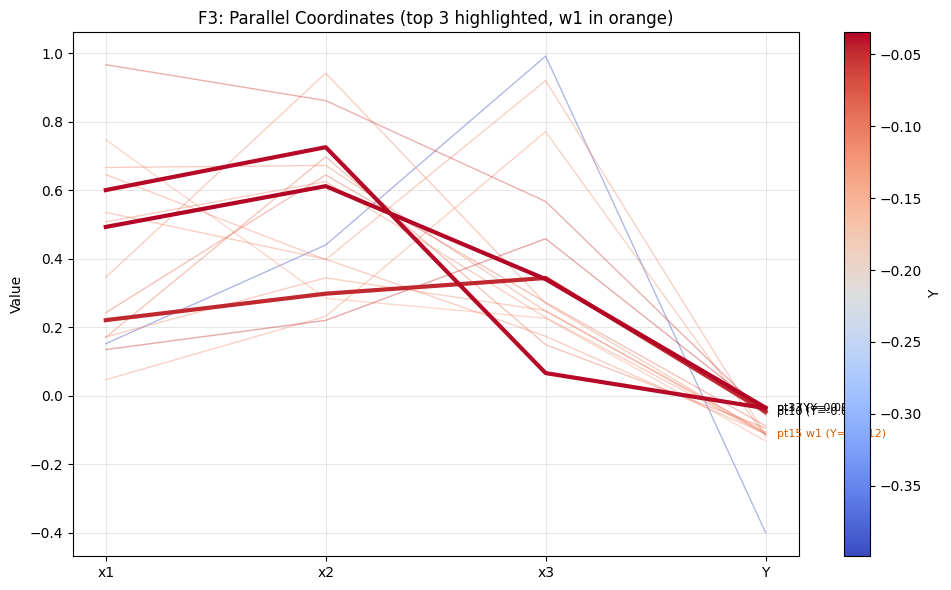

/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_48528/2866836413.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[d].boxplot([X[top5, d], X[bot5, d]], labels=['Top 5', 'Bottom 5'],
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_48528/2866836413.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[d].boxplot([X[top5, d], X[bot5, d]], labels=['Top 5', 'Bottom 5'],
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_48528/2866836413.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[d].boxplot([X[top5, d], X[bot5, d]], labels=['Top 5', 'Bottom 5'],
/var/fo

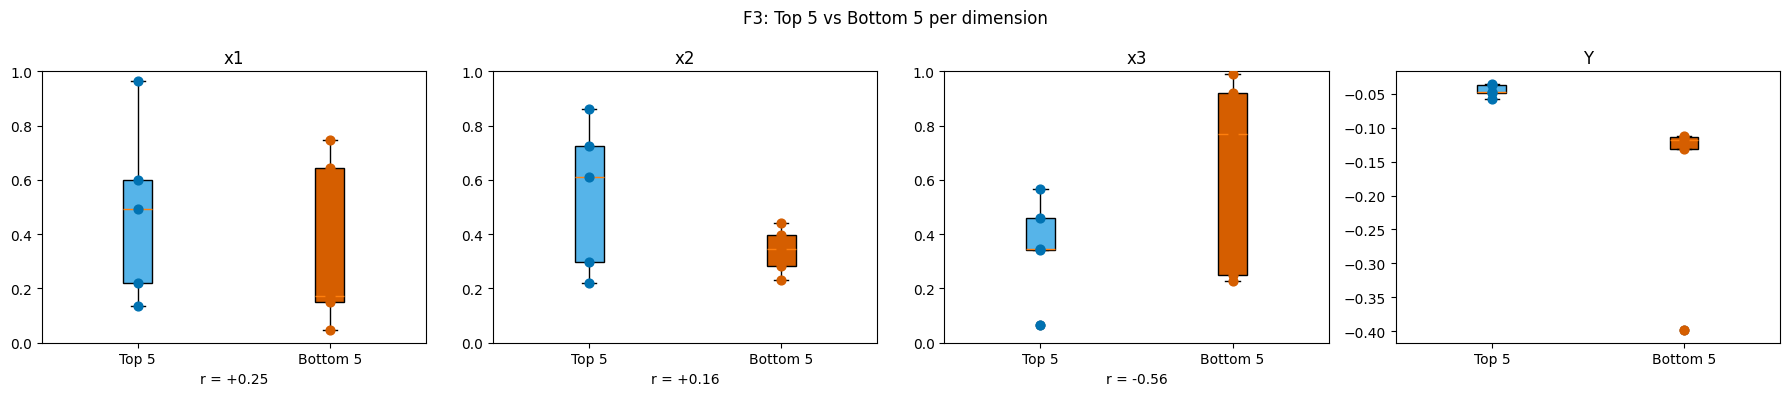

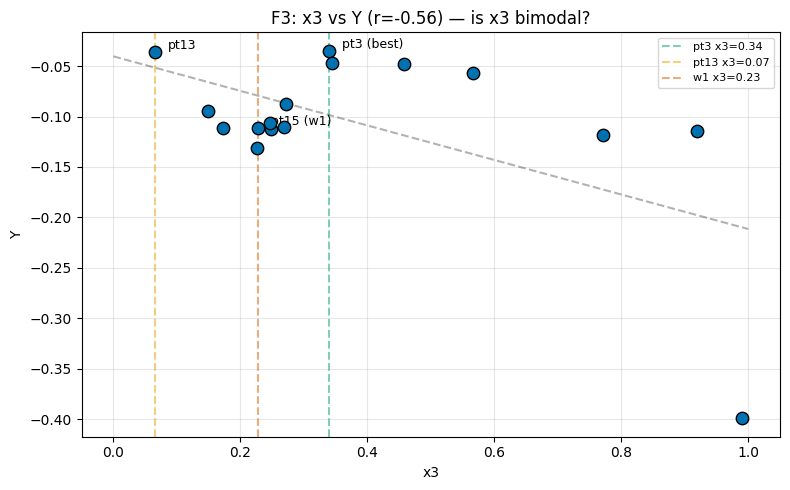


Data summary (sorted by Y):
Idx       x1       x2       x3          Y   Week
------------------------------------------------
  3   0.4926   0.6116   0.3402  -0.034835   init
 13   0.6001   0.7251   0.0661  -0.036378   init
 10   0.2205   0.2978   0.3436  -0.046947   init
  4   0.1346   0.2199   0.4582  -0.048008   init
 14   0.9660   0.8611   0.5668  -0.056758   init
  1   0.2421   0.6441   0.2724  -0.087963   init
  9   0.1705   0.6970   0.1492  -0.094190   init
 11   0.6660   0.6720   0.2463  -0.105965   init
  5   0.3455   0.9414   0.2694  -0.110621   init
  2   0.5349   0.3985   0.1734  -0.111415   init
 15   0.5073   0.6249   0.2284  -0.111651     w1
  0   0.1715   0.3439   0.2487  -0.112122   init
  7   0.6455   0.3971   0.9198  -0.113869   init
 12   0.0468   0.2314   0.7706  -0.118048   init
  8   0.7469   0.2842   0.2263  -0.131461   init
  6   0.1518   0.4400   0.9909  -0.398926   init

Correlations: x1=+0.25, x2=+0.16, x3=-0.56
x3 is still the dominant signal (r=-0.56)

We

In [6]:
# Function 3
X, Y = load_function(3)

# --- Week 01 Result ---
# Submitted [0.507, 0.625, 0.228] (Y-weighted centroid top 4) → returned Y=-0.112
# Did NOT improve. Centroid averaged x3 between pt3 (0.34) and pt13 (0.07) → x3=0.23
# landed in a poor region. Possible bimodality in x3?

# === Plot 1: Pairwise 2D projections (same as week 01, now with 16 pts) ===
dim_pairs = [(0, 1, 'x1', 'x2'), (0, 2, 'x1', 'x3'), (1, 2, 'x2', 'x3')]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (d1, d2, n1, n2) in zip(axes, dim_pairs):
    sc = ax.scatter(X[:, d1], X[:, d2], c=Y, cmap='coolwarm', s=120, edgecolors='black', zorder=5)
    for i in range(len(X)):
        week_label = ' w1' if i == len(X)-1 else ''
        ax.annotate(f'{i}{week_label}', (X[i,d1]+0.015, X[i,d2]+0.015), fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel(n1); ax.set_ylabel(n2)
    ax.set_title(f'F3: {n1} vs {n2}')
    plt.colorbar(sc, ax=ax, label='Y')
plt.tight_layout()
plt.savefig('../plots/week_02/f3_pairwise.png', dpi=150, bbox_inches='tight')
plt.show()

# === Plot 2: Parallel coordinates (top 3 highlighted) ===
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
Y_norm = (Y - Y.min()) / (Y.max() - Y.min())
cmap = plt.cm.coolwarm
sorted_idx = np.argsort(Y)  # draw worst first
for i in sorted_idx:
    color = cmap(Y_norm[i])
    lw = 3 if i in np.argsort(Y)[-3:] else 1
    alpha = 1.0 if i in np.argsort(Y)[-3:] else 0.4
    ax.plot([0, 1, 2, 3], [X[i,0], X[i,1], X[i,2], Y[i]],
            color=color, linewidth=lw, alpha=alpha)
    if i in np.argsort(Y)[-3:]:
        ax.text(3.05, Y[i], f'pt{i} (Y={Y[i]:.3f})', fontsize=8, va='center')
    if i == len(Y)-1:  # week 1 point
        ax.text(3.05, Y[i], f'pt{i} w1 (Y={Y[i]:.3f})', fontsize=8, va='center', color='#D55E00')
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['x1', 'x2', 'x3', 'Y'])
ax.set_title('F3: Parallel Coordinates (top 3 highlighted, w1 in orange)')
ax.set_ylabel('Value')
ax.grid(True, alpha=0.3)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(Y.min(), Y.max()))
plt.colorbar(sm, ax=ax, label='Y')
plt.tight_layout()
plt.savefig('../plots/week_02/f3_parallel_coords.png', dpi=150, bbox_inches='tight')
plt.show()

# === Plot 3: Top 5 vs Bottom 5 boxplots ===
sorted_idx = np.argsort(Y)[::-1]
top5 = sorted_idx[:5]
bot5 = sorted_idx[-5:]
box_colors = ['#56B4E9', '#D55E00']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for d in range(3):
    bp = axes[d].boxplot([X[top5, d], X[bot5, d]], labels=['Top 5', 'Bottom 5'],
                         patch_artist=True)
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
    axes[d].scatter(np.ones(5), X[top5, d], c='#0072B2', s=40, zorder=5)
    axes[d].scatter(np.ones(5)*2, X[bot5, d], c='#D55E00', s=40, zorder=5)
    axes[d].set_title(f'x{d+1}')
    axes[d].set_ylim(0, 1)
    r = np.corrcoef(X[:, d], Y)[0, 1]
    axes[d].set_xlabel(f'r = {r:+.2f}')

bp = axes[3].boxplot([Y[top5], Y[bot5]], labels=['Top 5', 'Bottom 5'], patch_artist=True)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
axes[3].scatter(np.ones(5), Y[top5], c='#0072B2', s=40, zorder=5)
axes[3].scatter(np.ones(5)*2, Y[bot5], c='#D55E00', s=40, zorder=5)
axes[3].set_title('Y')
plt.suptitle('F3: Top 5 vs Bottom 5 per dimension', fontsize=12)
plt.tight_layout()
plt.savefig('../plots/week_02/f3_top_vs_bottom.png', dpi=150, bbox_inches='tight')
plt.show()

# === Plot 4: x3 vs Y — key dimension, looking for bimodality ===
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.scatter(X[:, 2], Y, c='#0072B2', s=80, edgecolors='black', zorder=5)
for i in [3, 13, 15]:  # best, 2nd best, week 1
    label = f'pt{i}' + (' (w1)' if i == 15 else ' (best)' if i == 3 else '')
    ax.annotate(label, (X[i,2]+0.02, Y[i]+0.003), fontsize=9)
ax.axvline(X[3,2], color='#009E73', linestyle='--', alpha=0.5, label=f'pt3 x3={X[3,2]:.2f}')
ax.axvline(X[13,2], color='#E69F00', linestyle='--', alpha=0.5, label=f'pt13 x3={X[13,2]:.2f}')
ax.axvline(X[15,2], color='#D55E00', linestyle='--', alpha=0.5, label=f'w1 x3={X[15,2]:.2f}')
z = np.polyfit(X[:, 2], Y, 1)
ax.plot([0, 1], [z[1], z[0]+z[1]], '--', color='black', alpha=0.3)
ax.set_xlabel('x3'); ax.set_ylabel('Y')
ax.set_title(f'F3: x3 vs Y (r={np.corrcoef(X[:,2],Y)[0,1]:+.2f}) — is x3 bimodal?')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/week_02/f3_x3_bimodality.png', dpi=150, bbox_inches='tight')
plt.show()

# Data summary
print("\nData summary (sorted by Y):")
print(f"{'Idx':>3} {'x1':>8} {'x2':>8} {'x3':>8} {'Y':>10} {'Week':>6}")
print("-" * 48)
for i in np.argsort(Y)[::-1]:
    week = 'w1' if i == 15 else 'init'
    print(f"{i:>3} {X[i,0]:>8.4f} {X[i,1]:>8.4f} {X[i,2]:>8.4f} {Y[i]:>10.6f} {week:>6}")

print(f"\nCorrelations: x1={np.corrcoef(X[:,0],Y)[0,1]:+.2f}, x2={np.corrcoef(X[:,1],Y)[0,1]:+.2f}, x3={np.corrcoef(X[:,2],Y)[0,1]:+.2f}")
print(f"x3 is still the dominant signal (r={np.corrcoef(X[:,2],Y)[0,1]:+.2f})")
print(f"\nWeek 01 centroid failed: Y={Y[-1]:.4f} at x3={X[-1,2]:.2f}")
print(f"Top 2 points have very different x3: pt3 (x3={X[3,2]:.2f}) and pt13 (x3={X[13,2]:.2f})")
print(f"Suggestion: try near pt13 [{X[13,0]:.3f}, {X[13,1]:.3f}, {X[13,2]:.3f}] — lowest x3 among top performers")

# Strategy: GB depth=2 suggestion (only model to beat baseline on clean data)
next_query_3 = np.array([0.481100, 0.532600, 0.051800])

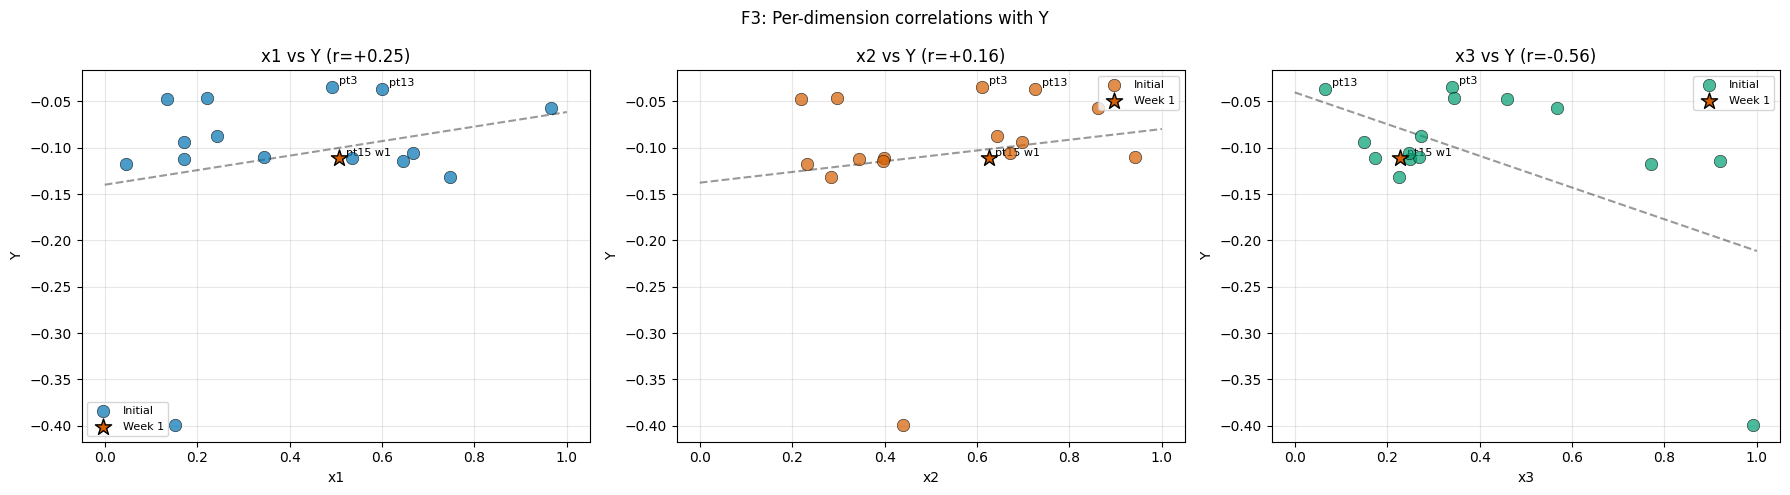

Observations:
  x1 (r=+0.25): weak positive trend. Best points spread across x1=0.05-0.97. No clear sweet spot.
  x2 (r=+0.16): weak positive. Best points have x2=0.22-0.94. Also no clear pattern.
  x3 (r=-0.56): clear negative trend. High x3 tends to give poor Y.
    But within low x3, results vary: x3=0.07 (pt13, Y=-0.0364) vs x3=0.23 (w1, Y=-0.1117)
    → x3 matters most, but x1/x2 also affect Y at low x3 values


In [7]:
# Function 3 — Per-dimension correlation plots (x1, x2, x3 each vs Y)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#0072B2', '#D55E00', '#009E73']
dim_names = ['x1', 'x2', 'x3']

for d in range(3):
    r = np.corrcoef(X[:, d], Y)[0, 1]
    
    # Initial points
    axes[d].scatter(X[:15, d], Y[:15], c=colors[d], s=80, edgecolors='black', 
                    linewidths=0.5, alpha=0.7, label='Initial', zorder=5)
    # Week 1 point
    axes[d].scatter(X[15, d], Y[15], c='#D55E00', s=150, edgecolors='black',
                    marker='*', zorder=6, label='Week 1')
    
    # Label key points
    for i in [3, 13, 15]:
        label = f'pt{i}' + (' w1' if i == 15 else '')
        axes[d].annotate(label, (X[i,d]+0.015, Y[i]+0.003), fontsize=8)
    
    # Trend line
    z = np.polyfit(X[:, d], Y, 1)
    axes[d].plot([0, 1], [z[1], z[0]+z[1]], '--', color='black', alpha=0.4)
    
    axes[d].set_xlabel(dim_names[d])
    axes[d].set_ylabel('Y')
    axes[d].set_title(f'{dim_names[d]} vs Y (r={r:+.2f})')
    axes[d].grid(True, alpha=0.3)
    axes[d].legend(fontsize=8)

plt.suptitle('F3: Per-dimension correlations with Y', fontsize=12)
plt.tight_layout()
plt.savefig('../plots/week_02/f3_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("Observations:")
r1 = np.corrcoef(X[:,0],Y)[0,1]
print(f"  x1 (r={r1:+.2f}): weak positive trend. Best points spread across x1={X[:,0].min():.2f}-{X[:,0].max():.2f}. No clear sweet spot.")
r2 = np.corrcoef(X[:,1],Y)[0,1]
print(f"  x2 (r={r2:+.2f}): weak positive. Best points have x2={X[:,1].min():.2f}-{X[:,1].max():.2f}. Also no clear pattern.")
r3 = np.corrcoef(X[:,2],Y)[0,1]
print(f"  x3 (r={r3:+.2f}): clear negative trend. High x3 tends to give poor Y.")
print(f"    But within low x3, results vary: x3={X[13,2]:.2f} (pt13, Y={Y[13]:.4f}) vs x3={X[-1,2]:.2f} (w1, Y={Y[-1]:.4f})")
print(f"    → x3 matters most, but x1/x2 also affect Y at low x3 values")


Removed pt6 (Y=-0.3989, x3=0.9909). Remaining: 15 points.

Correlations (with vs without pt6):
 Dim   With pt6    Without   Change
  x1    +0.2483    +0.0146  -0.2337
  x2    +0.1557    +0.1673  +0.0116
  x3    -0.5644    -0.1081  +0.4563


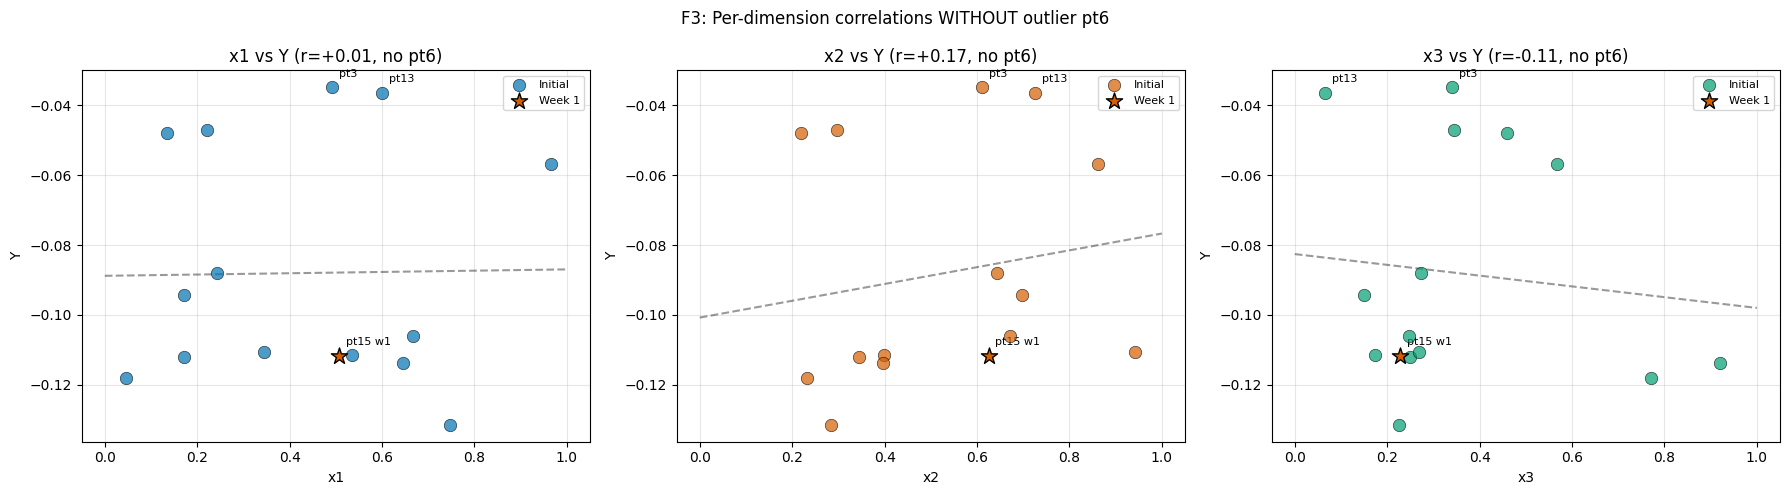

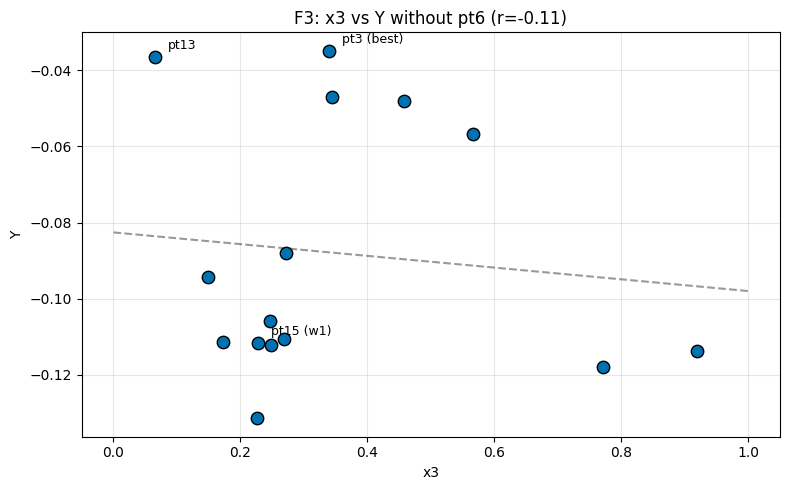


Key takeaway:
  x3 correlation WITHOUT pt6: r=-0.1081
  x3 correlation WITH pt6:    r=-0.5644
  If x3 correlation weakens significantly, pt6 was inflating the signal.
  If it stays similar, the x3 trend is genuine.


In [8]:
# Function 3 — Re-run analysis WITHOUT pt6 (Y=-0.399, x3=0.99, 3.2σ outlier)
# pt6 distorts correlations and plots. Remove it for cleaner analysis.

mask = np.arange(len(Y)) != 6  # exclude pt6
X_clean = X[mask]
Y_clean = Y[mask]
print(f'Removed pt6 (Y={Y[6]:.4f}, x3={X[6,2]:.4f}). Remaining: {len(Y_clean)} points.')

# === Correlations: before vs after removing outlier ===
print(f'\nCorrelations (with vs without pt6):')
print(f'{"Dim":>4} {"With pt6":>10} {"Without":>10} {"Change":>8}')
for d in range(3):
    r_all = np.corrcoef(X[:, d], Y)[0, 1]
    r_clean = np.corrcoef(X_clean[:, d], Y_clean)[0, 1]
    print(f'  x{d+1} {r_all:>+10.4f} {r_clean:>+10.4f} {r_clean-r_all:>+8.4f}')

# === Per-dimension plots WITHOUT outlier ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#0072B2', '#D55E00', '#009E73']
dim_names = ['x1', 'x2', 'x3']

# Track which indices in clean data correspond to original indices
orig_idx = np.where(mask)[0]

for d in range(3):
    r = np.corrcoef(X_clean[:, d], Y_clean)[0, 1]
    
    # Initial points (excluding pt6)
    init_mask = orig_idx < 15
    w1_mask = orig_idx == 15
    axes[d].scatter(X_clean[init_mask, d], Y_clean[init_mask], c=colors[d], s=80,
                    edgecolors='black', linewidths=0.5, alpha=0.7, label='Initial', zorder=5)
    if w1_mask.any():
        axes[d].scatter(X_clean[w1_mask, d], Y_clean[w1_mask], c='#D55E00', s=150,
                        edgecolors='black', marker='*', zorder=6, label='Week 1')
    
    # Label key points (find them in clean data)
    for orig_i in [3, 13, 15]:
        clean_i = np.where(orig_idx == orig_i)[0]
        if len(clean_i) > 0:
            ci = clean_i[0]
            label = f'pt{orig_i}' + (' w1' if orig_i == 15 else '')
            axes[d].annotate(label, (X_clean[ci,d]+0.015, Y_clean[ci]+0.003), fontsize=8)
    
    # Trend line
    z = np.polyfit(X_clean[:, d], Y_clean, 1)
    axes[d].plot([0, 1], [z[1], z[0]+z[1]], '--', color='black', alpha=0.4)
    
    axes[d].set_xlabel(dim_names[d])
    axes[d].set_ylabel('Y')
    axes[d].set_title(f'{dim_names[d]} vs Y (r={r:+.2f}, no pt6)')
    axes[d].grid(True, alpha=0.3)
    axes[d].legend(fontsize=8)

plt.suptitle('F3: Per-dimension correlations WITHOUT outlier pt6', fontsize=12)
plt.tight_layout()
plt.savefig('../plots/week_02/f3_correlations_no_outlier.png', dpi=150, bbox_inches='tight')
plt.show()

# === x3 vs Y without outlier ===
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.scatter(X_clean[:, 2], Y_clean, c='#0072B2', s=80, edgecolors='black', zorder=5)
for orig_i in [3, 13, 15]:
    clean_i = np.where(orig_idx == orig_i)[0]
    if len(clean_i) > 0:
        ci = clean_i[0]
        label = f'pt{orig_i}' + (' (w1)' if orig_i == 15 else ' (best)' if orig_i == 3 else '')
        ax.annotate(label, (X_clean[ci,2]+0.02, Y_clean[ci]+0.002), fontsize=9)
z = np.polyfit(X_clean[:, 2], Y_clean, 1)
ax.plot([0, 1], [z[1], z[0]+z[1]], '--', color='black', alpha=0.4)
r = np.corrcoef(X_clean[:, 2], Y_clean)[0, 1]
ax.set_xlabel('x3'); ax.set_ylabel('Y')
ax.set_title(f'F3: x3 vs Y without pt6 (r={r:+.2f})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/week_02/f3_x3_no_outlier.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nKey takeaway:')
print(f'  x3 correlation WITHOUT pt6: r={np.corrcoef(X_clean[:,2], Y_clean)[0,1]:+.4f}')
print(f'  x3 correlation WITH pt6:    r={np.corrcoef(X[:,2], Y)[0,1]:+.4f}')
print(f'  If x3 correlation weakens significantly, pt6 was inflating the signal.')
print(f'  If it stays similar, the x3 trend is genuine.')


MODEL GRID SEARCH — Clean data (no pt6), 15 points
Baseline RMSE: 0.032430

          Config       RMSE   Improv  Beat
------------------------------------------
     Ridge α=0.1   0.042454   -30.9%     ✗
     Ridge α=1.0   0.037756   -16.4%     ✗
         KNN K=2   0.043094   -32.9%     ✗
         KNN K=3   0.039707   -22.4%     ✗
         KNN K=5   0.037196   -14.7%     ✗
      RF depth=2   0.036393   -12.2%     ✗
      RF depth=3   0.034802    -7.3%     ✗
       SVR C=0.1   0.033565    -3.5%     ✗
         SVR C=1   0.033565    -3.5%     ✗
        SVR C=10   0.033565    -3.5%     ✗
       GP Matern   0.128152  -295.2%     ✗
      GB depth=2   0.026713   +17.6%     ✓

1 models beat baseline

          Config       x1       x2       x3     Pred Y  Bndry
------------------------------------------------------------
      GB depth=2   0.4811   0.5326   0.0518  -0.031021      ✓

--- Convergence (1 interior models) ---
  x1: mean=0.4811, spread=0.0000 → STRONG
  x2: mean=0.5326, spread=0.0

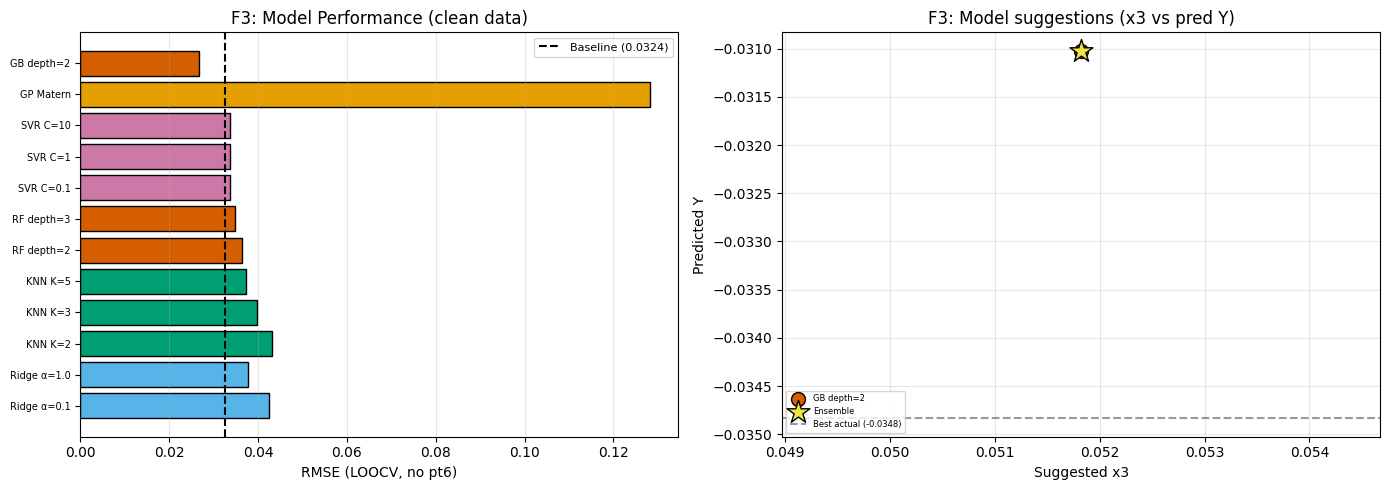

In [9]:
# Function 3 — Model ensemble on clean data (no pt6)
#
# Correlations collapsed without pt6. Let's see if models can find
# non-linear patterns that correlations miss.

import copy

mask_clean = np.arange(len(Y)) != 6
X_c = X[mask_clean]
Y_c = Y[mask_clean]

model_configs = {
    'Ridge α=0.1':  Ridge(alpha=0.1),
    'Ridge α=1.0':  Ridge(alpha=1.0),
    'KNN K=2':      KNeighborsRegressor(n_neighbors=2),
    'KNN K=3':      KNeighborsRegressor(n_neighbors=3),
    'KNN K=5':      KNeighborsRegressor(n_neighbors=5),
    'RF depth=2':   RandomForestRegressor(n_estimators=100, max_depth=2, random_state=42),
    'RF depth=3':   RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42),
    'SVR C=0.1':    SVR(kernel='rbf', C=0.1),
    'SVR C=1':      SVR(kernel='rbf', C=1.0),
    'SVR C=10':     SVR(kernel='rbf', C=10.0),
    'GP Matern':    GaussianProcessRegressor(kernel=Matern(nu=2.5), n_restarts_optimizer=5, random_state=42),
    'GB depth=2':   GradientBoostingRegressor(n_estimators=100, max_depth=2, random_state=42),
}

baseline = Y_c.std()
print("=" * 70)
print(f"MODEL GRID SEARCH — Clean data (no pt6), {len(Y_c)} points")
print("=" * 70)
print(f"Baseline RMSE: {baseline:.6f}")
print(f"\n{'Config':>16} {'RMSE':>10} {'Improv':>8} {'Beat':>5}")
print("-" * 42)

results = {}
for name, model in model_configs.items():
    m = copy.deepcopy(model)
    mse = cross_val_score(m, X_c, Y_c, cv=LeaveOneOut(), scoring='neg_mean_squared_error')
    rmse = np.sqrt(-mse.mean())
    beats = rmse < baseline
    results[name] = {'rmse': rmse, 'model': model, 'beats': beats}
    print(f"{name:>16} {rmse:>10.6f} {(1-rmse/baseline)*100:>+7.1f}% {'✓' if beats else '✗':>5}")

# Suggestions from models that beat baseline
np.random.seed(42)
cands = np.random.uniform(0, 0.999999, (100000, 3))

beating = {k: v for k, v in results.items() if v['beats']}
print(f"\n{len(beating)} models beat baseline")

interior = []
if beating:
    print(f"\n{'Config':>16} {'x1':>8} {'x2':>8} {'x3':>8} {'Pred Y':>10} {'Bndry':>6}")
    print("-" * 60)
    for name, res in beating.items():
        model = res['model']
        model.fit(X_c, Y_c)
        preds = model.predict(cands)
        best = cands[np.argmax(preds)]
        at_b = any(best[d] < 0.02 or best[d] > 0.98 for d in range(3))
        marker = '✓' if not at_b else '✗'
        print(f"{name:>16} {best[0]:>8.4f} {best[1]:>8.4f} {best[2]:>8.4f} {preds.max():>10.6f} {marker:>6}")
        if not at_b:
            interior.append((name, best, preds.max(), res['rmse']))

if interior:
    pts = np.array([p[1] for p in interior])
    print(f"\n--- Convergence ({len(interior)} interior models) ---")
    for d in range(3):
        vals = pts[:, d]
        spread = vals.max() - vals.min()
        consensus = 'STRONG' if spread < 0.2 else 'moderate' if spread < 0.4 else 'weak'
        print(f"  x{d+1}: mean={vals.mean():.4f}, spread={spread:.4f} → {consensus}")

    ensemble = pts.mean(axis=0)
    rmse_vals = np.array([p[3] for p in interior])
    inv_w = (1.0 / rmse_vals); inv_w /= inv_w.sum()
    ensemble_wtd = np.average(pts, axis=0, weights=inv_w)
    print(f"\n  Ensemble (avg):      [{ensemble[0]:.4f}, {ensemble[1]:.4f}, {ensemble[2]:.4f}]")
    print(f"  Ensemble (RMSE-wtd): [{ensemble_wtd[0]:.4f}, {ensemble_wtd[1]:.4f}, {ensemble_wtd[2]:.4f}]")

    # Compare to key points
    print(f"\n  Best actual (pt3):   [{X[3,0]:.4f}, {X[3,1]:.4f}, {X[3,2]:.4f}] Y={Y[3]:.6f}")
    print(f"  2nd best (pt13):     [{X[13,0]:.4f}, {X[13,1]:.4f}, {X[13,2]:.4f}] Y={Y[13]:.6f}")
    print(f"  Dist ensemble→pt3:   {np.linalg.norm(ensemble - X[3]):.4f}")
    print(f"  Dist ensemble→pt13:  {np.linalg.norm(ensemble - X[13]):.4f}")
else:
    print("\nNo interior suggestions. Falling back to perturbation near pt3 or pt13.")

# Visualise: model RMSE bar chart + suggestion scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = list(results.keys())
rmse_vals = [results[n]['rmse'] for n in names]
bar_colors = []
for n in names:
    if 'Ridge' in n: bar_colors.append('#56B4E9')
    elif 'KNN' in n: bar_colors.append('#009E73')
    elif 'RF' in n: bar_colors.append('#D55E00')
    elif 'SVR' in n: bar_colors.append('#CC79A7')
    elif 'GP' in n: bar_colors.append('#E69F00')
    elif 'GB' in n: bar_colors.append('#D55E00')
    else: bar_colors.append('#0072B2')

axes[0].barh(range(len(names)), rmse_vals, color=bar_colors, edgecolor='black')
axes[0].axvline(baseline, color='black', linewidth=1.5, linestyle='--', label=f'Baseline ({baseline:.4f})')
axes[0].set_yticks(range(len(names)))
axes[0].set_yticklabels(names, fontsize=7)
axes[0].set_xlabel('RMSE (LOOCV, no pt6)')
axes[0].set_title('F3: Model Performance (clean data)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='x')

# Scatter: x3 vs predicted Y for suggestions
if interior:
    for name, pt, pred, rmse in interior:
        color = bar_colors[names.index(name)] if name in names else '#0072B2'
        axes[1].scatter(pt[2], pred, s=100, edgecolors='black', c=color, zorder=5, label=name)
    axes[1].scatter(ensemble[2], np.mean([p[2] for p in interior]),
                    c='#F0E442', marker='*', s=300, edgecolors='black', zorder=6, label='Ensemble')
    axes[1].axhline(Y[3], color='black', linestyle='--', alpha=0.4, label=f'Best actual ({Y[3]:.4f})')
    axes[1].set_xlabel('Suggested x3')
    axes[1].set_ylabel('Predicted Y')
    axes[1].set_title('F3: Model suggestions (x3 vs pred Y)')
    axes[1].legend(fontsize=6, loc='lower left')
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'No models beat baseline', ha='center', va='center', fontsize=14)
    axes[1].set_title('F3: No usable model suggestions')

plt.tight_layout()
plt.savefig('../plots/week_02/f3_models_clean.png', dpi=150, bbox_inches='tight')
plt.show()



### F3 Decision: GB suggestion at [0.481100, 0.532600, 0.051800]

**Chosen approach:** Gradient Boosting (depth=2) — the only model to beat baseline on clean data.

**Week 01 result:**
- Submitted [0.507, 0.625, 0.228] (Y-weighted centroid top 4) → returned Y=-0.112
- Did NOT improve. The centroid averaged x3 between pt3 (0.34) and pt13 (0.07) → landed in a poor region.

**Critical finding — outlier pt6 was inflating correlations:**
- pt6 (Y=-0.399, x3=0.99) is a 3.2σ outlier. Removing it changes everything:
  - x1 correlation: +0.25 → +0.01 (collapsed, was entirely driven by pt6)
  - x3 correlation: -0.56 → -0.11 (collapsed, was mostly driven by pt6)
  - x2 correlation: +0.16 → +0.17 (stable, the only genuine signal)
- The 'strong x3 signal' from week 01 was largely a one-point artifact.
- **Note for all future weeks: always exclude pt6 from F3 analysis.**

**Model grid search (12 configs on clean data, no pt6):**
- Baseline RMSE: 0.0324 (much tighter without the outlier)
- 11 of 12 models failed to beat baseline — the function is genuinely noisy
- GP Matern was catastrophic (295% worse) — overfits on this noise
- **Gradient Boosting (depth=2) was the only model to beat baseline** at 17.6% improvement
- GB captures simple non-linear interactions (e.g. 'low x3 AND moderate x2 → good') without overfitting

**GB suggestion [0.481, 0.533, 0.052]:**
- x3=0.05 — very low, near pt13's x3=0.07. Even without the inflated correlation, GB learned low x3 helps through non-linear patterns.
- x1=0.48, x2=0.53 — moderate, between pt3 and pt13's values
- Predicted Y=-0.031 — would be a new best (current best is -0.035)
- Interior point, no boundary issues

**Confidence level: LOW.** One model at 17.6% improvement is not strong evidence (compare to F4 SVR at 63%). But it's the only data-driven option — the alternative is blind perturbation.

**Recommendations for Week 3:**
- If Y improves (better than -0.035): GB is working → re-fit with 17 points, consider adding more GB configs (depth=1, depth=3, different n_estimators)
- If Y is similar: the function may be flat near the optimum → try perturbing near pt3 instead (different region of x3)
- If Y is worse: GB was wrong → fall back to perturbation near pt3 [0.493, 0.612, 0.340] (the actual best point)
- Always exclude pt6 from analysis


## Function 4

Function 4: 31 points, 4D, best y = 0.3675


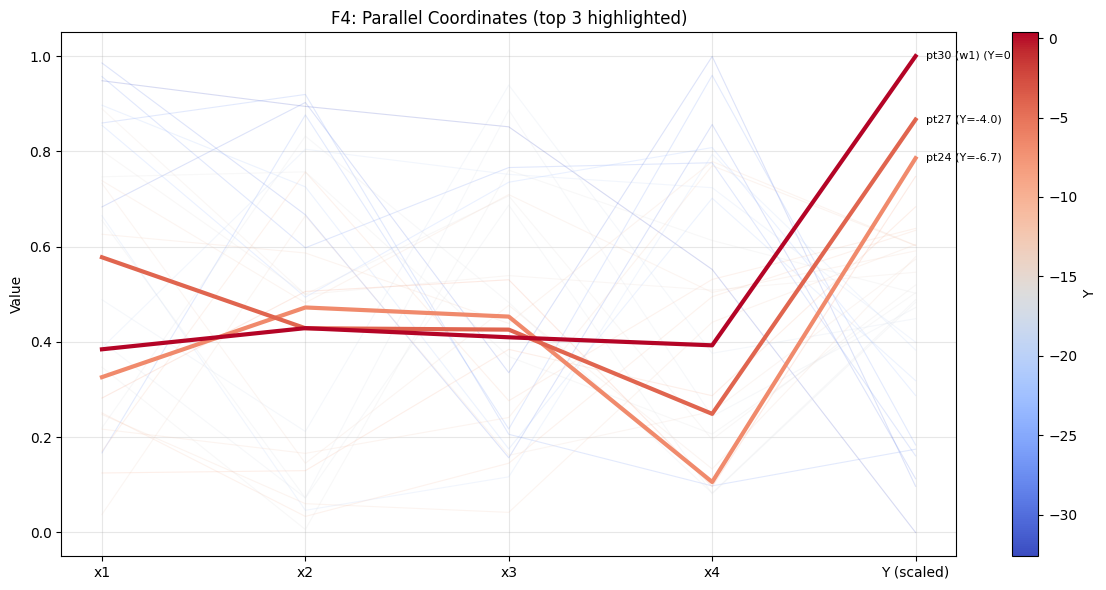

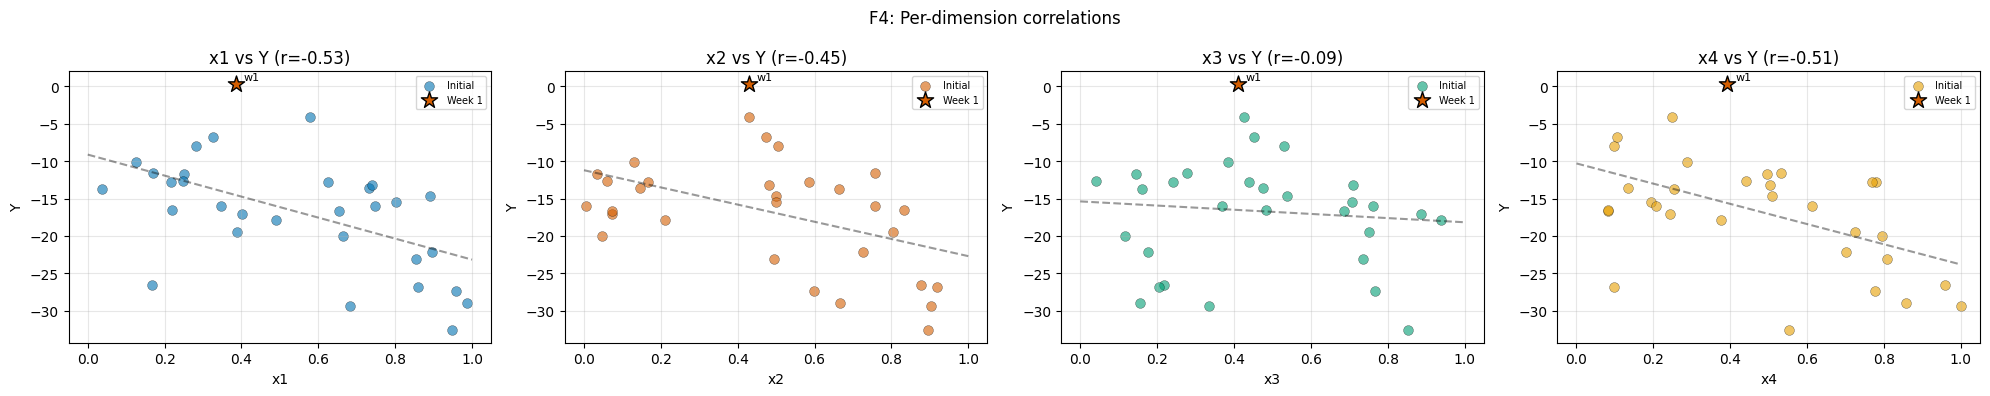

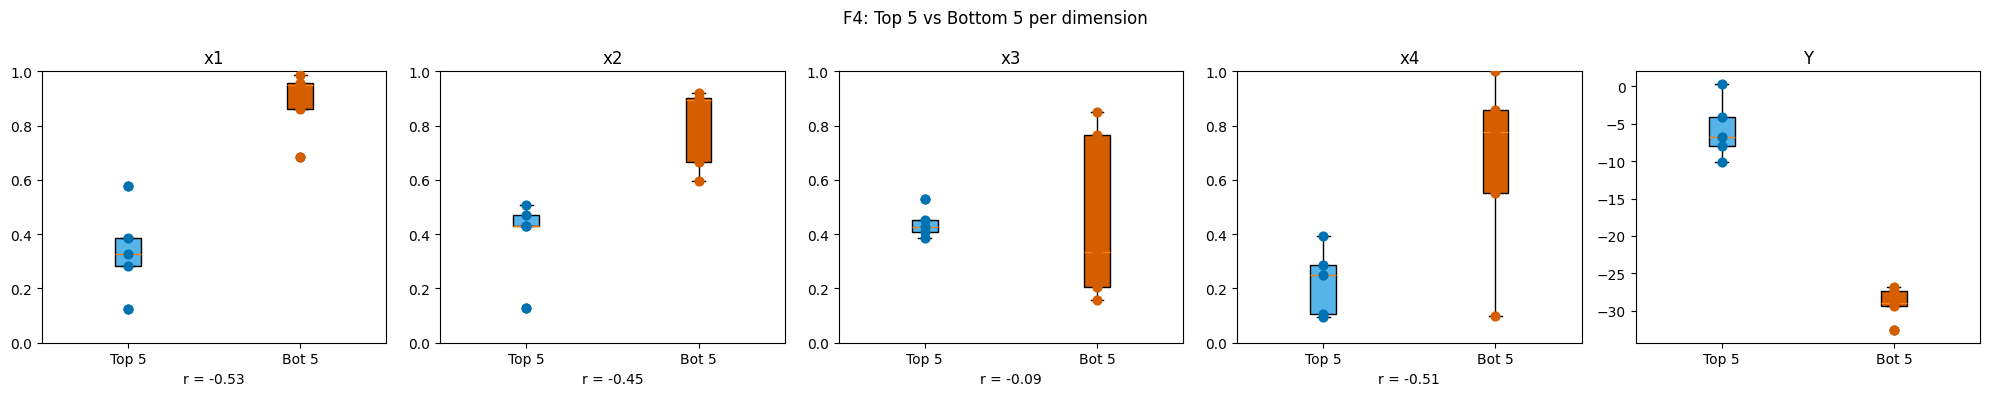


Data summary (top 5 by Y):
Idx       x1       x2       x3       x4          Y   Week
----------------------------------------------------
 30   0.3846   0.4290   0.4098   0.3929     0.3675     w1
 27   0.5778   0.4288   0.4258   0.2490    -4.0255   init
 24   0.3261   0.4724   0.4532   0.1059    -6.7021   init
 23   0.2821   0.5060   0.5305   0.0963    -7.9668   init
  4   0.1249   0.1298   0.3844   0.2871   -10.0696   init

Correlations: x1: -0.53, x2: -0.45, x3: -0.09, x4: -0.51
Week 01 SVR worked brilliantly: Y jumped from -4.03 to 0.37


In [10]:
# Function 4
X, Y = load_function(4)

# --- Week 01 Result ---
# Submitted [0.385, 0.429, 0.410, 0.393] (SVR RBF C=10) → Y = +0.367
# MASSIVE improvement! From -4.03 to +0.37 — first positive Y in the dataset.
# SVR predicted -1.35, actual was even better.

# === Plot 1: Parallel coordinates ===
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
Y_norm = (Y - Y.min()) / (Y.max() - Y.min())
cmap = plt.cm.coolwarm
sorted_plot = np.argsort(Y)
for i in sorted_plot:
    color = cmap(Y_norm[i])
    lw = 3 if i in np.argsort(Y)[-3:] else 0.8
    alpha = 1.0 if i in np.argsort(Y)[-3:] else 0.2
    vals = list(X[i]) + [Y_norm[i]]
    ax.plot(range(5), vals, color=color, linewidth=lw, alpha=alpha)
    if i in np.argsort(Y)[-3:]:
        week = ' (w1)' if i == len(Y)-1 else ''
        ax.text(4.05, Y_norm[i], f'pt{i}{week} (Y={Y[i]:.1f})', fontsize=8, va='center')
ax.set_xticks(range(5))
ax.set_xticklabels(['x1', 'x2', 'x3', 'x4', 'Y (scaled)'])
ax.set_title('F4: Parallel Coordinates (top 3 highlighted)')
ax.set_ylabel('Value')
ax.grid(True, alpha=0.3)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(Y.min(), Y.max()))
plt.colorbar(sm, ax=ax, label='Y')
plt.tight_layout()
plt.savefig('../plots/week_02/f4_parallel_coords.png', dpi=150, bbox_inches='tight')
plt.show()

# === Plot 2: Per-dimension correlation (x vs Y) ===
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
colors = ['#0072B2', '#D55E00', '#009E73', '#E69F00']
for d in range(4):
    r = np.corrcoef(X[:, d], Y)[0, 1]
    # Initial points
    axes[d].scatter(X[:30, d], Y[:30], c=colors[d], s=50, alpha=0.6, edgecolors='black', linewidths=0.3, label='Initial')
    # Week 1 point
    axes[d].scatter(X[30, d], Y[30], c='#D55E00', s=150, edgecolors='black', marker='*', zorder=6, label='Week 1')
    axes[d].annotate('w1', (X[30,d]+0.02, Y[30]+0.5), fontsize=8)
    # Trend line
    z = np.polyfit(X[:, d], Y, 1)
    axes[d].plot([0, 1], [z[1], z[0]+z[1]], '--', color='black', alpha=0.4)
    axes[d].set_xlabel(f'x{d+1}')
    axes[d].set_ylabel('Y')
    axes[d].set_title(f'x{d+1} vs Y (r={r:+.2f})')
    axes[d].grid(True, alpha=0.3)
    axes[d].legend(fontsize=7)
plt.suptitle('F4: Per-dimension correlations', fontsize=12)
plt.tight_layout()
plt.savefig('../plots/week_02/f4_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

# === Plot 3: Top 5 vs Bottom 5 ===
sorted_idx = np.argsort(Y)[::-1]
top5 = sorted_idx[:5]
bot5 = sorted_idx[-5:]
box_colors = ['#56B4E9', '#D55E00']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for d in range(4):
    bp = axes[d].boxplot([X[top5, d], X[bot5, d]], tick_labels=['Top 5', 'Bot 5'], patch_artist=True)
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
    axes[d].scatter(np.ones(5), X[top5, d], c='#0072B2', s=40, zorder=5)
    axes[d].scatter(np.ones(5)*2, X[bot5, d], c='#D55E00', s=40, zorder=5)
    axes[d].set_title(f'x{d+1}')
    axes[d].set_ylim(0, 1)
    r = np.corrcoef(X[:, d], Y)[0, 1]
    axes[d].set_xlabel(f'r = {r:+.2f}')
bp = axes[4].boxplot([Y[top5], Y[bot5]], tick_labels=['Top 5', 'Bot 5'], patch_artist=True)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
axes[4].scatter(np.ones(5), Y[top5], c='#0072B2', s=40, zorder=5)
axes[4].scatter(np.ones(5)*2, Y[bot5], c='#D55E00', s=40, zorder=5)
axes[4].set_title('Y')
plt.suptitle('F4: Top 5 vs Bottom 5 per dimension', fontsize=12)
plt.tight_layout()
plt.savefig('../plots/week_02/f4_top_vs_bottom.png', dpi=150, bbox_inches='tight')
plt.show()

# Data summary
print("\nData summary (top 5 by Y):")
print(f"{'Idx':>3} {'x1':>8} {'x2':>8} {'x3':>8} {'x4':>8} {'Y':>10} {'Week':>6}")
print("-" * 52)
for i in sorted_idx[:5]:
    week = 'w1' if i == 30 else 'init'
    print(f"{i:>3} {X[i,0]:>8.4f} {X[i,1]:>8.4f} {X[i,2]:>8.4f} {X[i,3]:>8.4f} {Y[i]:>10.4f} {week:>6}")

print(f"\nCorrelations: " + ", ".join(f'x{d+1}: {np.corrcoef(X[:,d],Y)[0,1]:+.2f}' for d in range(4)))
print(f"Week 01 SVR worked brilliantly: Y jumped from {Y[:-1].max():.2f} to {Y[-1]:.2f}")

# next_query_4 set in separate cell below


MODEL GRID SEARCH (sklearn GridSearchCV) — 31 points, LOO CV
Baseline RMSE: 7.5723

               Model  Best RMSE   Improv  Beat Best Params
------------------------------------------------------------------------------------------
               Ridge     5.9527   +21.4%     ✓ {'alpha': 1.0}
                 KNN     5.4263   +28.3%     ✓ {'n_neighbors': 2, 'weights': 'distance'}
       Random Forest     4.8002   +36.6%     ✓ {'max_depth': 5, 'n_estimators': 100}
                 SVR     2.0117   +73.4%     ✓ {'C': 100, 'gamma': 'scale'}
   Gradient Boosting     4.3626   +42.4%     ✓ {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}
           GP Matern     5.5541   +26.7%     ✓ {'kernel': 'GP Matern'}
              GP RBF     6.7136   +11.3%     ✓ {'kernel': 'GP RBF'}
       Poly Ridge d2     3.6553   +51.7%     ✓ {'degree': 2, 'alpha': 0.1}

MODEL SUGGESTIONS (best config per family)
               Model       x1       x2       x3       x4     Pred Y   Use?
--------------

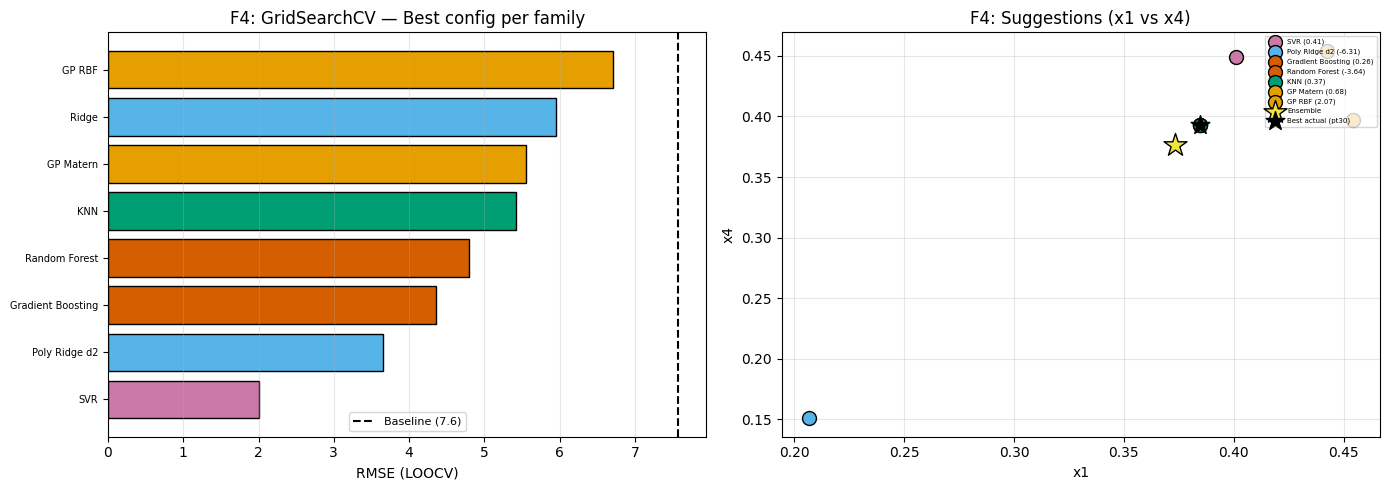

In [11]:
# Function 4 — GridSearchCV + feature importance + convergence
#
# Week 01: SVR C=10 dominated at 63%. Now with 31 points and a new best
# at Y=0.37, using proper sklearn GridSearchCV for systematic search.

import copy
from sklearn.model_selection import GridSearchCV

baseline = Y.std()
print("=" * 75)
print(f"MODEL GRID SEARCH (sklearn GridSearchCV) — 31 points, LOO CV")
print("=" * 75)
print(f"Baseline RMSE: {baseline:.4f}")

# Define model families with param grids
model_grids = {
    'Ridge': (Ridge(), {'alpha': [0.01, 0.1, 1.0, 10, 100]}),
    'KNN': (KNeighborsRegressor(), {'n_neighbors': [2, 3, 5, 7], 'weights': ['uniform', 'distance']}),
    'Random Forest': (RandomForestRegressor(random_state=42), 
                      {'max_depth': [2, 3, 5, None], 'n_estimators': [50, 100, 200]}),
    'SVR': (SVR(kernel='rbf'), {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']}),
    'Gradient Boosting': (GradientBoostingRegressor(random_state=42),
                          {'max_depth': [2, 3, 5], 'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 0.3]}),
}

print(f"\n{'Model':>20} {'Best RMSE':>10} {'Improv':>8} {'Beat':>5} {'Best Params'}")
print("-" * 90)

grid_results = {}
for name, (model, params) in model_grids.items():
    grid = GridSearchCV(model, params, cv=LeaveOneOut(), scoring='neg_mean_squared_error', refit=True)
    grid.fit(X, Y)
    rmse = np.sqrt(-grid.best_score_)
    beats = rmse < baseline
    grid_results[name] = {'rmse': rmse, 'model': grid.best_estimator_, 'beats': beats, 'params': grid.best_params_}
    imp = (1 - rmse/baseline) * 100
    print(f"{name:>20} {rmse:>10.4f} {imp:>+7.1f}% {'✓' if beats else '✗':>5} {grid.best_params_}")

# GP separately (doesn't work well with GridSearchCV)
for kernel_name, kernel in [('GP Matern', Matern(nu=2.5)), ('GP RBF', RBF())]:
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, random_state=42)
    mse = cross_val_score(gp, X, Y, cv=LeaveOneOut(), scoring='neg_mean_squared_error')
    rmse = np.sqrt(-mse.mean())
    beats = rmse < baseline
    grid_results[kernel_name] = {'rmse': rmse, 'model': GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, random_state=42), 'beats': beats, 'params': {'kernel': kernel_name}}
    imp = (1 - rmse/baseline) * 100
    print(f"{kernel_name:>20} {rmse:>10.4f} {imp:>+7.1f}% {'✓' if beats else '✗':>5} {{'kernel': '{kernel_name}'}}")

# Poly Ridge separately
poly_ridge = make_pipeline(PolynomialFeatures(2, include_bias=False), Ridge(alpha=0.1))
mse_pr = cross_val_score(poly_ridge, X, Y, cv=LeaveOneOut(), scoring='neg_mean_squared_error')
rmse_pr = np.sqrt(-mse_pr.mean())
grid_results['Poly Ridge d2'] = {'rmse': rmse_pr, 'model': make_pipeline(PolynomialFeatures(2, include_bias=False), Ridge(alpha=0.1)), 'beats': rmse_pr < baseline, 'params': {'degree': 2, 'alpha': 0.1}}
imp = (1 - rmse_pr/baseline) * 100
print(f"{'Poly Ridge d2':>20} {rmse_pr:>10.4f} {imp:>+7.1f}% {'✓' if rmse_pr < baseline else '✗':>5} {{'degree': 2, 'alpha': 0.1}}")

# --- Suggestions from best models ---
np.random.seed(42)
cands = np.random.uniform(0, 0.999999, (100000, 4))

print(f"\n{'='*75}")
print("MODEL SUGGESTIONS (best config per family)")
print(f"{'='*75}")
print(f"{'Model':>20} {'x1':>8} {'x2':>8} {'x3':>8} {'x4':>8} {'Pred Y':>10} {'Use?':>6}")
print("-" * 75)

suggestions = {}
for name, res in sorted(grid_results.items(), key=lambda x: x[1]['rmse']):
    if not res['beats']:
        continue
    model = res['model']
    model.fit(X, Y)
    preds = model.predict(cands)
    best = cands[np.argmax(preds)]
    at_b = any(best[d] < 0.02 or best[d] > 0.98 for d in range(4))
    use = not at_b
    suggestions[name] = {'point': best, 'pred': preds.max(), 'rmse': res['rmse'], 'use': use}
    marker = '✓' if use else '✗'
    note = ' (boundary)' if at_b else ''
    print(f"{name:>20} {best[0]:>8.4f} {best[1]:>8.4f} {best[2]:>8.4f} {best[3]:>8.4f} {preds.max():>10.4f} {marker:>6}{note}")

# Convergence
interior = {k: v for k, v in suggestions.items() if v['use']}
if interior:
    all_pts = np.array([v['point'] for v in interior.values()])
    print(f"\n--- Convergence ({len(interior)} interior models) ---")
    for d in range(4):
        vals = all_pts[:, d]
        spread = vals.max() - vals.min()
        consensus = 'STRONG' if spread < 0.2 else 'moderate' if spread < 0.4 else 'weak'
        print(f"  x{d+1}: mean={vals.mean():.4f}, spread={spread:.4f} → {consensus}")
    
    ensemble = all_pts.mean(axis=0)
    rmse_vals = np.array([v['rmse'] for v in interior.values()])
    inv_w = (1.0 / rmse_vals); inv_w /= inv_w.sum()
    ensemble_wtd = np.average(all_pts, axis=0, weights=inv_w)
    print(f"\n  Ensemble (avg):      [{', '.join(f'{v:.4f}' for v in ensemble)}]")
    print(f"  Ensemble (RMSE-wtd): [{', '.join(f'{v:.4f}' for v in ensemble_wtd)}]")

# Feature importance robustness
print(f"\n--- Feature Importance Robustness ---")
rf_imp = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42); rf_imp.fit(X, Y)
best_idx = np.argmax(Y)
mask_no_best = np.arange(len(Y)) != best_idx
rf_imp2 = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42); rf_imp2.fit(X[mask_no_best], Y[mask_no_best])

print(f"{'Dim':>4} {'RF(all)':>9} {'RF(no best)':>12} {'Change':>8} {'Corr':>8}")
for d in range(4):
    r = np.corrcoef(X[:, d], Y)[0, 1]
    chg = (rf_imp2.feature_importances_[d] - rf_imp.feature_importances_[d]) / max(rf_imp.feature_importances_[d], 0.001) * 100
    print(f"  x{d+1} {rf_imp.feature_importances_[d]:>9.4f} {rf_imp2.feature_importances_[d]:>12.4f} {chg:>+7.0f}% {r:>+8.4f}")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE bar chart (sorted by RMSE)
sorted_names = sorted(grid_results.keys(), key=lambda k: grid_results[k]['rmse'])
rmse_plot = [grid_results[n]['rmse'] for n in sorted_names]
bar_colors = []
for n in sorted_names:
    if 'Ridge' in n: bar_colors.append('#56B4E9')
    elif 'KNN' in n: bar_colors.append('#009E73')
    elif 'RF' in n or 'Random' in n: bar_colors.append('#D55E00')
    elif 'SVR' in n: bar_colors.append('#CC79A7')
    elif 'GP' in n: bar_colors.append('#E69F00')
    elif 'GB' in n or 'Gradient' in n: bar_colors.append('#D55E00')
    elif 'Poly' in n: bar_colors.append('#56B4E9')
    else: bar_colors.append('#0072B2')

axes[0].barh(range(len(sorted_names)), rmse_plot, color=bar_colors, edgecolor='black')
axes[0].axvline(baseline, color='black', linewidth=1.5, linestyle='--', label=f'Baseline ({baseline:.1f})')
axes[0].set_yticks(range(len(sorted_names)))
axes[0].set_yticklabels(sorted_names, fontsize=7)
axes[0].set_xlabel('RMSE (LOOCV)')
axes[0].set_title('F4: GridSearchCV — Best config per family')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='x')

# Suggestions: x1 vs x4
if interior:
    for name, s in interior.items():
        c = bar_colors[sorted_names.index(name)] if name in sorted_names else '#0072B2'
        axes[1].scatter(s['point'][0], s['point'][3], c=c, s=100, edgecolors='black',
                        label=f"{name} ({s['pred']:.2f})", zorder=5)
    axes[1].scatter(ensemble_wtd[0], ensemble_wtd[3], c='#F0E442', marker='*', s=300,
                    edgecolors='black', zorder=6, label='Ensemble')
    axes[1].scatter(X[best_idx, 0], X[best_idx, 3], c='black', marker='*', s=200,
                    zorder=7, label=f'Best actual (pt{best_idx})')
axes[1].set_xlabel('x1'); axes[1].set_ylabel('x4')
axes[1].set_title('F4: Suggestions (x1 vs x4)')
axes[1].legend(fontsize=5, loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/week_02/f4_gridsearch.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
# F4 — Final query
next_query_4 = np.array([0.454200, 0.474300, 0.411300, 0.397000])
print(f"F4 query: {next_query_4}")
print(f"Method: GP Matern suggestion (best understanding of function)")


F4 query: [0.4542 0.4743 0.4113 0.397 ]
Method: GP Matern suggestion (best understanding of function)


### F4 Decision: GP Matern suggestion at [0.454200, 0.474300, 0.411300, 0.397000]

**Chosen approach:** GP Matern suggestion — best function understanding, moderate exploitation step.

**Week 01 result — huge success:**
- Submitted [0.385, 0.429, 0.410, 0.393] (SVR C=10) → returned Y = **+0.367**
- Jumped from -4.03 to +0.37 — the only positive Y in 31 points
- SVR predicted -1.35, actual was +0.37 → directionally right, magnitude underestimated

**GridSearchCV analysis (sklearn, LOO CV):**
- Searched ~60 configs across 5 model families + GP + Poly Ridge
- **SVR** (C=100, gamma=scale): 73.4% improvement — best LOOCV score
- **Gradient Boosting** (lr=0.1, depth=2, n_est=200): 42.4%
- **Random Forest** (depth=5, n_est=100): 36.6%
- **All models beat baseline** — 31 points in 4D is enough data

**Model suggestions:**
- 3 models (GB, RF, KNN) suggest **exactly pt30** — they can't find anything better. The new best point dominates so much they just point back at it.
- **SVR C=100**: [0.401, 0.429, 0.399, 0.449] pred=0.41 — conservative, small step (dist 0.06)
- **GP Matern**: [0.454, 0.474, 0.411, 0.397] pred=0.68 — bolder, moderate step (dist 0.08)
- Ridge hits boundary — rejected
- GP RBF predicts Y=2.07 — unrealistic overfit, ignored

**Why GP Matern over SVR:**
- SVR is the best LOOCV model but it's conservative — pred Y=0.41 (small improvement over 0.37)
- SVR underestimates the current best (predicts 0.27 at pt30, actual 0.37) — it's systematically low
- GP perfectly interpolates through training data (pred at pt30 = 0.3675 = exact)
- GP's suggestion pushes x1 and x2 slightly higher while keeping x3, x4 similar
- Distance 0.08 from pt30 — moderate step, not reckless

**Why not re-query near pt30:**
- 3 models already suggest exactly pt30. Querying there again wastes the submission.
- We know Y=0.37 at pt30. We need to explore nearby to find if there's something better.

**Feature importance (stable):**
- x1 (RF=0.30), x2 (0.32), x4 (0.26) are the main drivers. x3 (0.11) is minor.
- Removing pt30 changes importance by only 1-8% — these are genuine signals.

**Recommendations for Week 3:**
- If Y > 0.37: GP was right → continue in GP's direction, possibly with UCB for more exploration
- If Y ≈ 0.37: flat region around the peak → try SVR's more conservative suggestion next
- If Y < 0: overshot → the peak is sharply located near pt30, try smaller perturbation [0.39, 0.43, 0.41, 0.40]


## Function 5

Function 5: 21 points, 4D, best y = 1088.8596


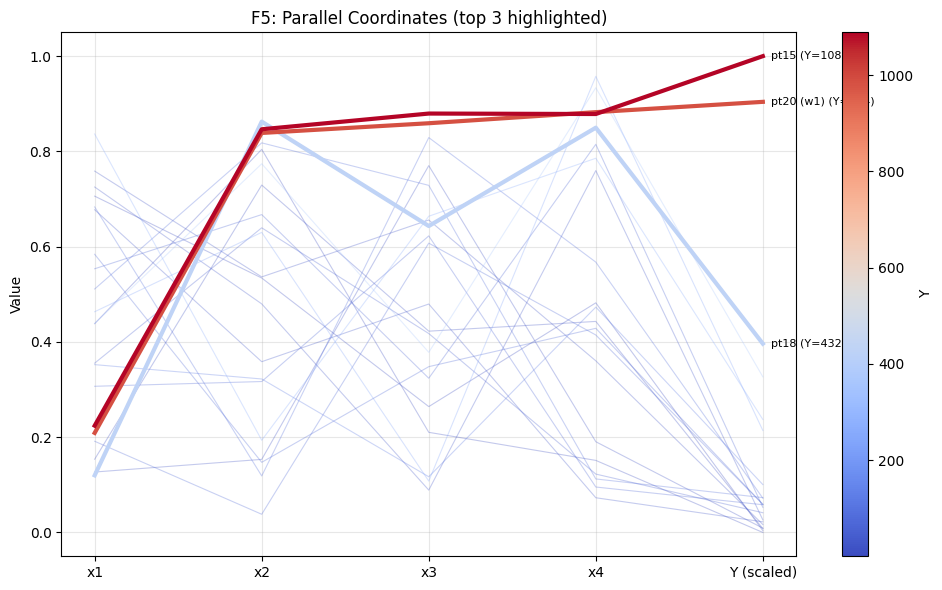

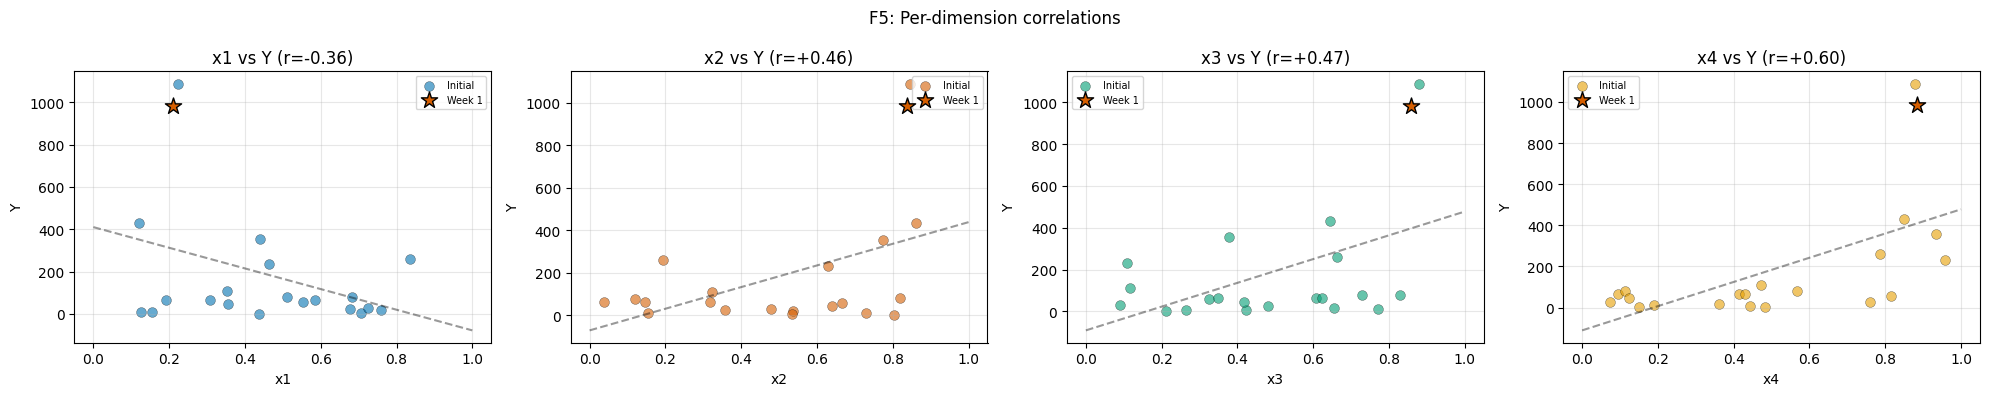

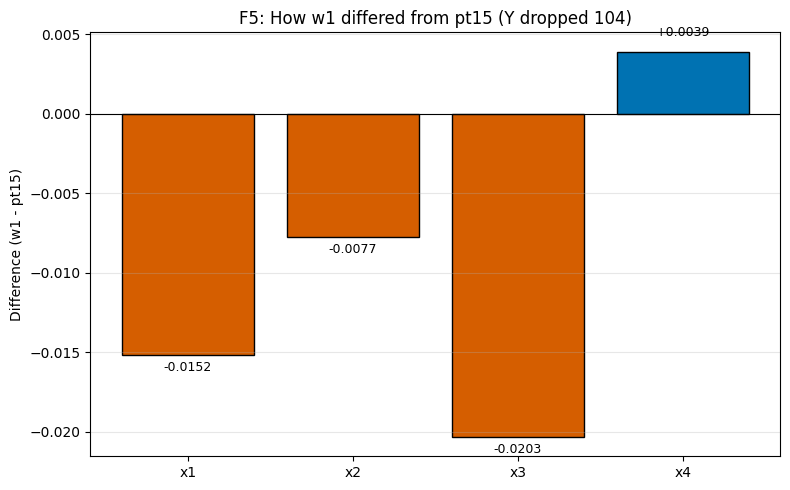


Week 01 moved x1↓, x2↓, x3↓, x4↑ from pt15 → Y dropped 104
Strategy: try the OPPOSITE direction — x1↑, x2↑, x3↑, x4↓
Opposite perturbation: [0.2394, 0.8542, 0.8998, 0.8746]


In [13]:
# Function 5
X, Y = load_function(5)

# --- Week 01 Result ---
# Submitted [0.209, 0.839, 0.859, 0.882] (GP perturbation near pt15) → Y=984.40
# Did NOT improve — dropped from 1088.86 to 984.40
# A 0.027 step caused a 104-point drop! The peak is EXTREMELY sharp.

# === Plot 1: Parallel coordinates ===
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
Y_norm = (Y - Y.min()) / (Y.max() - Y.min())
cmap = plt.cm.coolwarm
sorted_plot = np.argsort(Y)
for i in sorted_plot:
    color = cmap(Y_norm[i])
    lw = 3 if i in np.argsort(Y)[-3:] else 0.8
    alpha = 1.0 if i in np.argsort(Y)[-3:] else 0.3
    vals = list(X[i]) + [Y_norm[i]]
    ax.plot(range(5), vals, color=color, linewidth=lw, alpha=alpha)
    if i in np.argsort(Y)[-3:]:
        week = ' (w1)' if i == len(Y)-1 else ''
        ax.text(4.05, Y_norm[i], f'pt{i}{week} (Y={Y[i]:.0f})', fontsize=8, va='center')
ax.set_xticks(range(5))
ax.set_xticklabels(['x1', 'x2', 'x3', 'x4', 'Y (scaled)'])
ax.set_title('F5: Parallel Coordinates (top 3 highlighted)')
ax.set_ylabel('Value')
ax.grid(True, alpha=0.3)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(Y.min(), Y.max()))
plt.colorbar(sm, ax=ax, label='Y')
plt.tight_layout()
plt.savefig('../plots/week_02/f5_parallel_coords.png', dpi=150, bbox_inches='tight')
plt.show()

# === Plot 2: Per-dimension correlations ===
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
colors = ['#0072B2', '#D55E00', '#009E73', '#E69F00']
for d in range(4):
    r = np.corrcoef(X[:, d], Y)[0, 1]
    axes[d].scatter(X[:20, d], Y[:20], c=colors[d], s=50, alpha=0.6, edgecolors='black', linewidths=0.3, label='Initial')
    axes[d].scatter(X[20, d], Y[20], c='#D55E00', s=150, edgecolors='black', marker='*', zorder=6, label='Week 1')
    z = np.polyfit(X[:, d], Y, 1)
    axes[d].plot([0, 1], [z[1], z[0]+z[1]], '--', color='black', alpha=0.4)
    axes[d].set_xlabel(f'x{d+1}')
    axes[d].set_ylabel('Y')
    axes[d].set_title(f'x{d+1} vs Y (r={r:+.2f})')
    axes[d].grid(True, alpha=0.3)
    axes[d].legend(fontsize=7)
plt.suptitle('F5: Per-dimension correlations', fontsize=12)
plt.tight_layout()
plt.savefig('../plots/week_02/f5_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

# === Plot 3: Directional analysis — what happened? ===
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
dims = ['x1', 'x2', 'x3', 'x4']
diffs = X[20] - X[15]
bar_colors = ['#D55E00' if d < 0 else '#0072B2' for d in diffs]
ax.bar(dims, diffs, color=bar_colors, edgecolor='black')
ax.set_ylabel('Difference (w1 - pt15)')
ax.set_title(f'F5: How w1 differed from pt15 (Y dropped {Y[15]-Y[20]:.0f})')
ax.axhline(0, color='black', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='y')
for i, (d, v) in enumerate(zip(dims, diffs)):
    ax.text(i, v + 0.001 * np.sign(v), f'{v:+.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../plots/week_02/f5_direction.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nWeek 01 moved x1↓, x2↓, x3↓, x4↑ from pt15 → Y dropped 104")
print("Strategy: try the OPPOSITE direction — x1↑, x2↑, x3↑, x4↓")
opp_direction = np.clip(X[15] - (X[-1] - X[15]), 0, 1)
print(f"Opposite perturbation: [{', '.join(f'{v:.4f}' for v in opp_direction)}]")

# next_query_5 set in separate cell below


MODEL GRID SEARCH (sklearn GridSearchCV) — 21 points, LOO CV
Baseline RMSE: 298.18

               Model  Best RMSE   Improv Best Params
-------------------------------------------------------------------------------------
               Ridge     199.68   +33.0% {'alpha': 0.1}
                 KNN     103.22   +65.4% {'n_neighbors': 7, 'weights': 'distance'}
       Random Forest     169.70   +43.1% {'max_depth': 3, 'n_estimators': 100}
                 SVR     247.58   +17.0% {'C': 100, 'gamma': 'scale'}
   Gradient Boosting     139.71   +53.1% {'learning_rate': 0.3, 'max_depth': 2, 'n_estimators': 50}
           GP Matern     148.58   +50.2%

MODEL SUGGESTIONS (best config per family)
               Model       x1       x2       x3       x4     Pred  Dist→pt15  Use?
--------------------------------------------------------------------------------
                 KNN   0.2090   0.8387   0.8592   0.8824   984.40     0.0268     ✓
   Gradient Boosting   0.4319   0.8500   0.8703   0.8798 

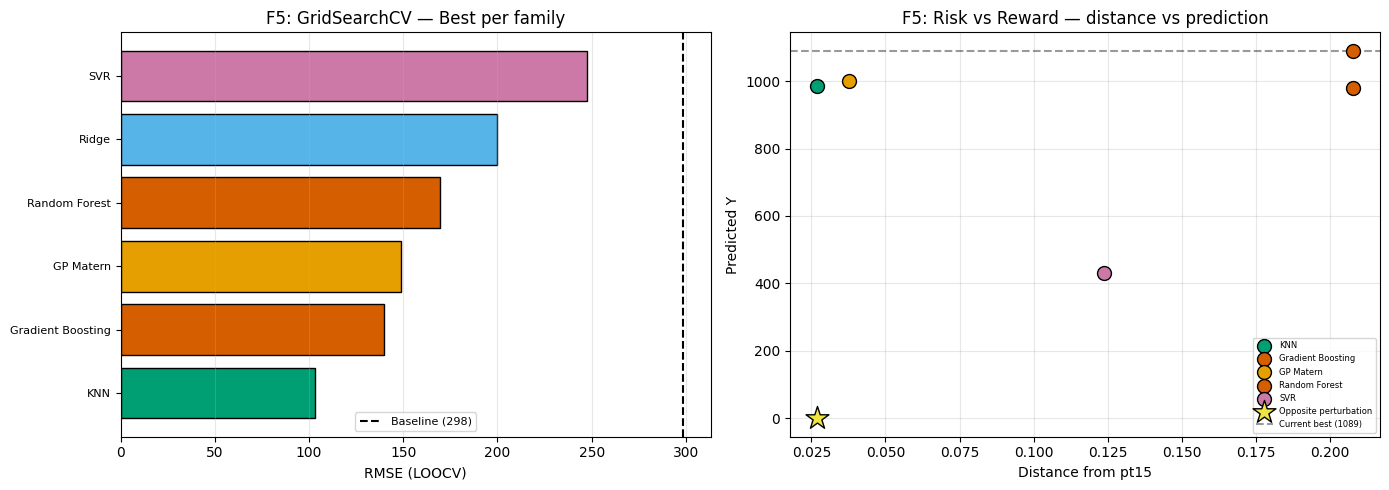


--- Key Takeaway ---
All models agree the peak is near pt15. The question is how to step.
GB boldly suggests x1=0.43 (pred Y=1090), but dist=0.21 from pt15 is risky.
Opposite perturbation is the safest data-driven move (dist=0.027).


In [14]:
# Function 5 — GridSearchCV + feature importance robustness
#
# Week 01 GP perturbation failed — Y dropped 104 for a 0.027 step.
# Let's see what models suggest with 21 points.

import copy
from sklearn.model_selection import GridSearchCV

baseline = Y.std()
print("=" * 85)
print(f"MODEL GRID SEARCH (sklearn GridSearchCV) — 21 points, LOO CV")
print("=" * 85)
print(f"Baseline RMSE: {baseline:.2f}")

model_grids = {
    'Ridge': (Ridge(), {'alpha': [0.01, 0.1, 1.0, 10, 100]}),
    'KNN': (KNeighborsRegressor(), {'n_neighbors': [2, 3, 5, 7], 'weights': ['uniform', 'distance']}),
    'Random Forest': (RandomForestRegressor(random_state=42),
                      {'max_depth': [2, 3, 5, None], 'n_estimators': [50, 100]}),
    'SVR': (SVR(kernel='rbf'), {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']}),
    'Gradient Boosting': (GradientBoostingRegressor(random_state=42),
                          {'max_depth': [2, 3], 'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 0.3]}),
}

print(f"\n{'Model':>20} {'Best RMSE':>10} {'Improv':>8} {'Best Params'}")
print("-" * 85)

grid_results = {}
for name, (model, params) in model_grids.items():
    grid = GridSearchCV(model, params, cv=LeaveOneOut(), scoring='neg_mean_squared_error', refit=True)
    grid.fit(X, Y)
    rmse = np.sqrt(-grid.best_score_)
    grid_results[name] = {'rmse': rmse, 'model': grid.best_estimator_, 'beats': rmse < baseline, 'params': grid.best_params_}
    print(f"{name:>20} {rmse:>10.2f} {(1-rmse/baseline)*100:>+7.1f}% {grid.best_params_}")

# GP separately
gp = GaussianProcessRegressor(kernel=Matern(nu=2.5), n_restarts_optimizer=5, random_state=42)
mse_gp = cross_val_score(gp, X, Y, cv=LeaveOneOut(), scoring='neg_mean_squared_error')
rmse_gp = np.sqrt(-mse_gp.mean())
grid_results['GP Matern'] = {'rmse': rmse_gp, 'model': gp, 'beats': rmse_gp < baseline}
print(f"{'GP Matern':>20} {rmse_gp:>10.2f} {(1-rmse_gp/baseline)*100:>+7.1f}%")

# --- Suggestions ---
np.random.seed(42)
cands = np.random.uniform(0, 0.999999, (100000, 4))

print(f"\n{'='*85}")
print("MODEL SUGGESTIONS (best config per family)")
print(f"{'='*85}")
print(f"{'Model':>20} {'x1':>8} {'x2':>8} {'x3':>8} {'x4':>8} {'Pred':>8} {'Dist→pt15':>10} {'Use?':>5}")
print("-" * 80)

suggestions = {}
for name in sorted(grid_results, key=lambda k: grid_results[k]['rmse']):
    res = grid_results[name]
    if not res['beats']:
        continue
    model = res['model']
    model.fit(X, Y)
    preds = model.predict(cands)
    best = cands[np.argmax(preds)]
    at_b = any(best[d] < 0.02 or best[d] > 0.98 for d in range(4))
    dist = np.linalg.norm(best - X[15])
    suggestions[name] = {'point': best, 'pred': preds.max(), 'rmse': res['rmse'], 'use': not at_b}
    marker = '✓' if not at_b else '✗'
    print(f"{name:>20} {best[0]:>8.4f} {best[1]:>8.4f} {best[2]:>8.4f} {best[3]:>8.4f} {preds.max():>8.2f} {dist:>10.4f} {marker:>5}")

# Convergence
interior = {k: v for k, v in suggestions.items() if v['use']}
if interior:
    all_pts = np.array([v['point'] for v in interior.values()])
    print(f"\n--- Convergence ({len(interior)} interior models) ---")
    for d in range(4):
        vals = all_pts[:, d]
        spread = vals.max() - vals.min()
        consensus = 'STRONG' if spread < 0.2 else 'moderate' if spread < 0.4 else 'weak'
        print(f"  x{d+1}: mean={vals.mean():.4f}, spread={spread:.4f} → {consensus}")

# Feature importance robustness
print(f"\n--- Feature Importance Robustness ---")
rf_fi = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42); rf_fi.fit(X, Y)
mask_no15 = np.arange(len(Y)) != 15
rf_fi2 = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42); rf_fi2.fit(X[mask_no15], Y[mask_no15])

print(f"{'Dim':>4} {'RF(all)':>9} {'RF(no pt15)':>12} {'Change':>8} {'Corr':>8}")
for d in range(4):
    r = np.corrcoef(X[:, d], Y)[0, 1]
    chg = (rf_fi2.feature_importances_[d] - rf_fi.feature_importances_[d]) / max(rf_fi.feature_importances_[d], 0.001) * 100
    print(f"  x{d+1} {rf_fi.feature_importances_[d]:>9.4f} {rf_fi2.feature_importances_[d]:>12.4f} {chg:>+7.0f}% {r:>+8.4f}")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE bar chart
sorted_names = sorted(grid_results.keys(), key=lambda k: grid_results[k]['rmse'])
rmse_plot = [grid_results[n]['rmse'] for n in sorted_names]
bar_colors = []
for n in sorted_names:
    if 'Ridge' in n: bar_colors.append('#56B4E9')
    elif 'KNN' in n: bar_colors.append('#009E73')
    elif 'Random' in n: bar_colors.append('#D55E00')
    elif 'SVR' in n: bar_colors.append('#CC79A7')
    elif 'GP' in n: bar_colors.append('#E69F00')
    elif 'Gradient' in n: bar_colors.append('#D55E00')
    else: bar_colors.append('#0072B2')
axes[0].barh(range(len(sorted_names)), rmse_plot, color=bar_colors, edgecolor='black')
axes[0].axvline(baseline, color='black', linewidth=1.5, linestyle='--', label=f'Baseline ({baseline:.0f})')
axes[0].set_yticks(range(len(sorted_names)))
axes[0].set_yticklabels(sorted_names, fontsize=8)
axes[0].set_xlabel('RMSE (LOOCV)')
axes[0].set_title('F5: GridSearchCV — Best per family')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='x')

# Distance to pt15 vs predicted Y
if interior:
    for name, s in interior.items():
        c = '#009E73' if 'KNN' in name else '#D55E00' if 'Gradient' in name or 'Random' in name else '#CC79A7' if 'SVR' in name else '#E69F00' if 'GP' in name else '#56B4E9'
        dist = np.linalg.norm(s['point'] - X[15])
        axes[1].scatter(dist, s['pred'], c=c, s=100, edgecolors='black', label=name, zorder=5)
    # Mark opposite perturbation
    opp = np.clip(X[15] - (X[20] - X[15]), 0.02, 0.98)
    axes[1].scatter(np.linalg.norm(opp - X[15]), 0, c='#F0E442', marker='*', s=300,
                    edgecolors='black', zorder=6, label='Opposite perturbation')
    axes[1].axhline(Y[15], color='black', linestyle='--', alpha=0.4, label=f'Current best ({Y[15]:.0f})')
    axes[1].set_xlabel('Distance from pt15')
    axes[1].set_ylabel('Predicted Y')
    axes[1].set_title('F5: Risk vs Reward — distance vs prediction')
    axes[1].legend(fontsize=6)
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/week_02/f5_gridsearch.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n--- Key Takeaway ---")
print(f"All models agree the peak is near pt15. The question is how to step.")
gb_res = grid_results.get("Gradient Boosting")
if gb_res and gb_res["beats"]:
    gb_model = gb_res["model"]; gb_model.fit(X, Y)
    gb_preds = gb_model.predict(cands)
    gb_best = cands[np.argmax(gb_preds)]
    gb_dist = np.linalg.norm(gb_best - X[15])
    print(f"GB boldly suggests x1={gb_best[0]:.2f} (pred Y={gb_preds.max():.0f}), but dist={gb_dist:.2f} from pt15 is risky.")
opp_pt = np.clip(X[15] - (X[20] - X[15]), 0.02, 0.98)
opp_dist = np.linalg.norm(opp_pt - X[15])
print(f"Opposite perturbation is the safest data-driven move (dist={opp_dist:.3f}).")


In [15]:
# F5 — Final query: opposite direction from failed w1 perturbation
next_query_5 = np.array([0.239400, 0.854200, 0.899800, 0.874600])
print(f"F5 query: {next_query_5}")
print(f"Distance to pt15: {np.linalg.norm(next_query_5 - X[15]):.4f}")
print(f"Method: opposite-direction perturbation from failed w1 query")


F5 query: [0.2394 0.8542 0.8998 0.8746]
Distance to pt15: 0.0268
Method: opposite-direction perturbation from failed w1 query


### F5 Decision: Opposite-direction perturbation at [0.239400, 0.854200, 0.899800, 0.874600]

**Chosen approach:** Mirror the week 01 perturbation in the opposite direction from pt15.

**Week 01 result — steep gradient discovered:**
- Submitted [0.209, 0.839, 0.859, 0.882] (GP perturbation, dist=0.027 from pt15)
- Returned Y=984.40 — dropped 104 points from pt15's 1088.86
- A 0.027 step caused a 104-point drop. This is the steepest gradient across all 8 functions.
- GP predicted 1073.54 — was directionally wrong, the perturbation went downhill.

**What the perturbation told us:**
- Week 01 moved: x1↓ (-0.015), x2↓ (-0.008), x3↓ (-0.020), x4↑ (+0.004)
- Y dropped sharply → that direction is downhill
- The opposite direction (x1↑, x2↑, x3↑, x4↓) should be uphill

**GridSearchCV results (21 points):**
- **KNN** (K=7, distance-weighted): 65.4% improvement — best model, but suggests our failed w1 point
- **Gradient Boosting** (lr=0.3, depth=2): 53.1% — suggests [0.432, 0.850, 0.870, 0.880] pred Y=1090. Bolder, pushes x1 much higher.
- **GP Matern**: 50.2% — suggests [0.205, 0.878, 0.880, 0.871], very close to pt15
- All models beat baseline — data is sufficient for modelling

**Feature importance robustness:**
- x3 importance drops 49% when pt15 removed — inflated by the outlier (same finding as week 01)
- x4 is the robust driver (importance increases 69% without pt15)

**Why opposite-direction perturbation:**
- The peak is extremely sharp — models struggle to predict the exact optimum
- We have direct gradient information: week 01 showed which direction is downhill
- The opposite direction is a data-driven bet, not a model prediction
- Distance 0.027 from pt15 — same step size as week 01, just mirrored
- Lower risk than GB's bold suggestion (dist=0.21 from pt15 on a function where 0.027 caused a 104-point drop)

**Recommendations for Week 3:**
- If Y > 1088: we found the uphill direction! Continue stepping further in that direction.
- If Y ≈ 984 (similar to w1): the peak is sharply centered on pt15, and both sides drop off equally → try a much smaller perturbation (dist=0.01)
- If Y drops further: the peak may not be symmetric → try **GB's suggestion [0.432, 0.850, 0.870, 0.880]** which takes a completely different approach (high x1). GB predicted Y=1090 and had 53% LOOCV improvement.
- Consider exploring a different direction entirely (e.g. only change one dimension at a time to identify which dim matters most near the peak)


## Function 6

Function 6: 21 points, 5D, best y = -0.4370


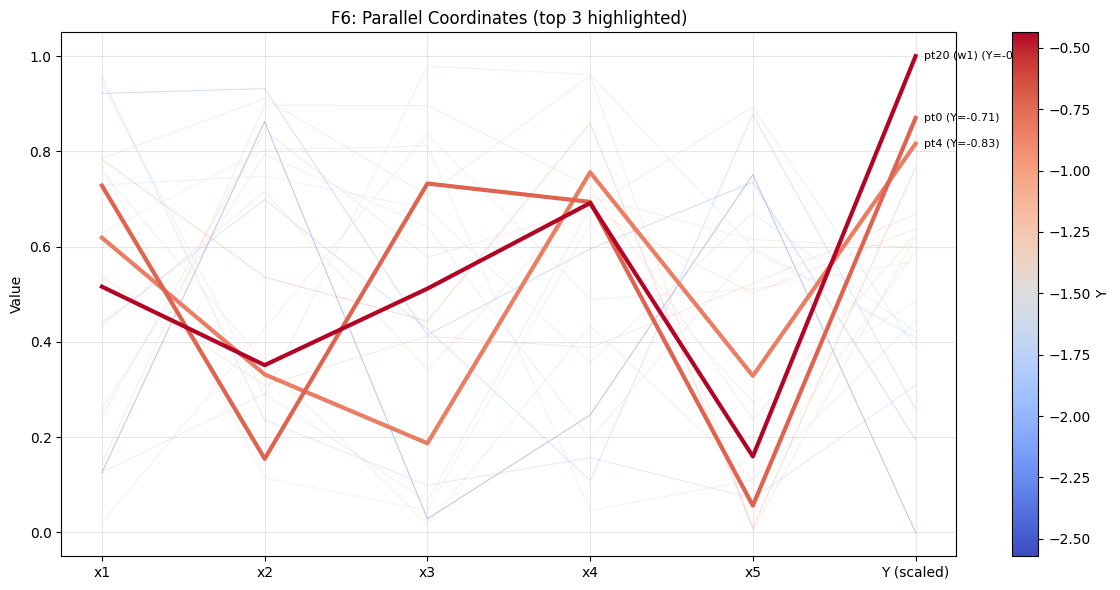

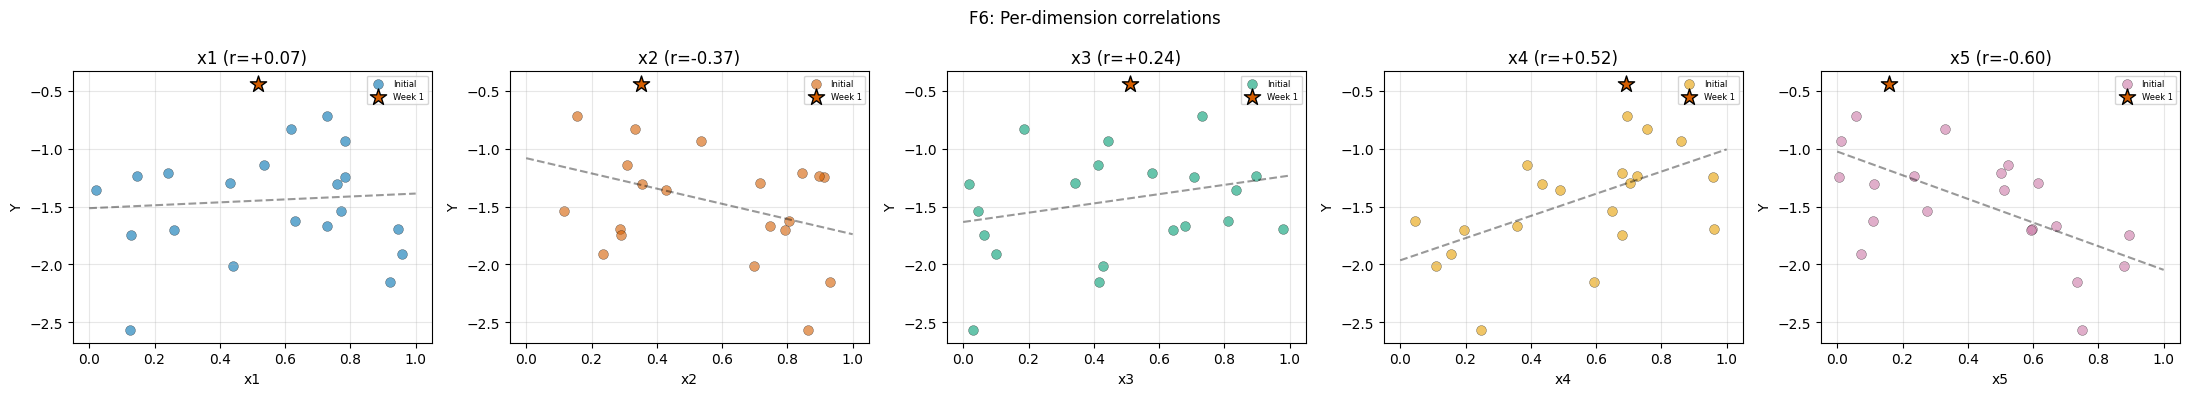

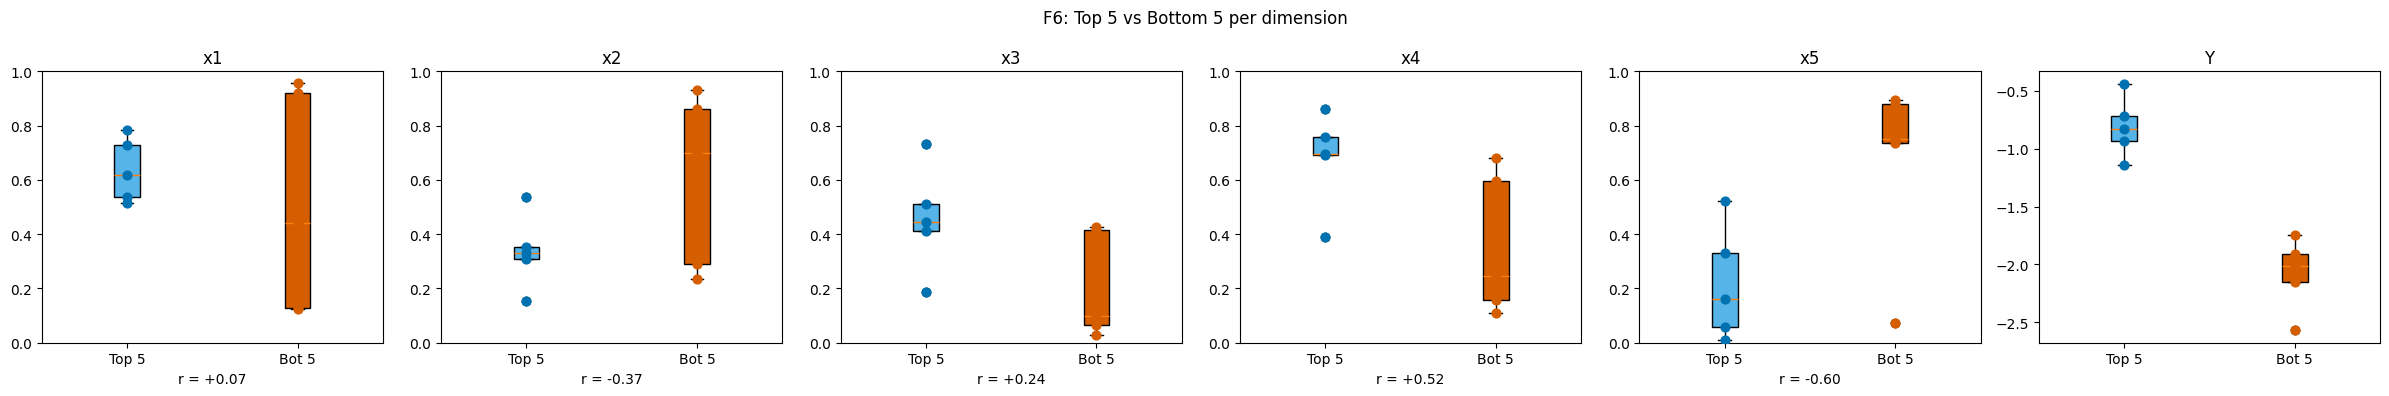


Data summary (top 5):
Idx      x1      x2      x3      x4      x5         Y  Week
-------------------------------------------------------
 20  0.5160  0.3513  0.5119  0.6916  0.1596   -0.4370    w1
  0  0.7282  0.1547  0.7326  0.6940  0.0564   -0.7143  init
  4  0.6188  0.3318  0.1873  0.7562  0.3288   -0.8292  init
 17  0.7829  0.5363  0.4433  0.8597  0.0103   -0.9358  init
 10  0.5368  0.3088  0.4119  0.3882  0.5225   -1.1448  init

Correlations: x1: +0.07, x2: -0.37, x3: +0.24, x4: +0.52, x5: -0.60
Week 01 SVR worked: Y improved from -0.7143 to -0.4370


In [16]:
# Function 6
X, Y = load_function(6)

# --- Week 01 Result ---
# Submitted [0.516, 0.351, 0.512, 0.692, 0.160] (SVR RBF C=1) → Y=-0.437
# IMPROVED! From -0.714 to -0.437 — SVR suggestion worked.

# === Plot 1: Parallel coordinates ===
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
Y_norm = (Y - Y.min()) / (Y.max() - Y.min())
cmap = plt.cm.coolwarm
for i in np.argsort(Y):
    color = cmap(Y_norm[i])
    lw = 3 if i in np.argsort(Y)[-3:] else 0.8
    alpha = 1.0 if i in np.argsort(Y)[-3:] else 0.3
    vals = list(X[i]) + [Y_norm[i]]
    ax.plot(range(6), vals, color=color, linewidth=lw, alpha=alpha)
    if i in np.argsort(Y)[-3:]:
        week = ' (w1)' if i == len(Y)-1 else ''
        ax.text(5.05, Y_norm[i], f'pt{i}{week} (Y={Y[i]:.2f})', fontsize=8, va='center')
ax.set_xticks(range(6))
ax.set_xticklabels(['x1', 'x2', 'x3', 'x4', 'x5', 'Y (scaled)'])
ax.set_title('F6: Parallel Coordinates (top 3 highlighted)')
ax.set_ylabel('Value')
ax.grid(True, alpha=0.3)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(Y.min(), Y.max()))
plt.colorbar(sm, ax=ax, label='Y')
plt.tight_layout()
plt.savefig('../plots/week_02/f6_parallel_coords.png', dpi=150, bbox_inches='tight')
plt.show()

# === Plot 2: Per-dimension correlations ===
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
colors = ['#0072B2', '#D55E00', '#009E73', '#E69F00', '#CC79A7']
for d in range(5):
    r = np.corrcoef(X[:, d], Y)[0, 1]
    axes[d].scatter(X[:20, d], Y[:20], c=colors[d], s=50, alpha=0.6, edgecolors='black', linewidths=0.3, label='Initial')
    axes[d].scatter(X[20, d], Y[20], c='#D55E00', s=150, edgecolors='black', marker='*', zorder=6, label='Week 1')
    z = np.polyfit(X[:, d], Y, 1)
    axes[d].plot([0, 1], [z[1], z[0]+z[1]], '--', color='black', alpha=0.4)
    axes[d].set_xlabel(f'x{d+1}')
    axes[d].set_ylabel('Y')
    axes[d].set_title(f'x{d+1} (r={r:+.2f})')
    axes[d].grid(True, alpha=0.3)
    axes[d].legend(fontsize=6)
plt.suptitle('F6: Per-dimension correlations', fontsize=12)
plt.tight_layout()
plt.savefig('../plots/week_02/f6_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

# === Plot 3: Top 5 vs Bottom 5 ===
sorted_idx = np.argsort(Y)[::-1]
top5 = sorted_idx[:5]
bot5 = sorted_idx[-5:]
box_colors = ['#56B4E9', '#D55E00']
fig, axes = plt.subplots(1, 6, figsize=(24, 4))
for d in range(5):
    bp = axes[d].boxplot([X[top5, d], X[bot5, d]], tick_labels=['Top 5', 'Bot 5'], patch_artist=True)
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
    axes[d].scatter(np.ones(5), X[top5, d], c='#0072B2', s=40, zorder=5)
    axes[d].scatter(np.ones(5)*2, X[bot5, d], c='#D55E00', s=40, zorder=5)
    axes[d].set_title(f'x{d+1}')
    axes[d].set_ylim(0, 1)
    r = np.corrcoef(X[:, d], Y)[0, 1]
    axes[d].set_xlabel(f'r = {r:+.2f}')
bp = axes[5].boxplot([Y[top5], Y[bot5]], tick_labels=['Top 5', 'Bot 5'], patch_artist=True)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
axes[5].scatter(np.ones(5), Y[top5], c='#0072B2', s=40, zorder=5)
axes[5].scatter(np.ones(5)*2, Y[bot5], c='#D55E00', s=40, zorder=5)
axes[5].set_title('Y')
plt.suptitle('F6: Top 5 vs Bottom 5 per dimension', fontsize=12)
plt.tight_layout()
plt.savefig('../plots/week_02/f6_top_vs_bottom.png', dpi=150, bbox_inches='tight')
plt.show()

# Data summary
print("\nData summary (top 5):")
print(f"{'Idx':>3} {'x1':>7} {'x2':>7} {'x3':>7} {'x4':>7} {'x5':>7} {'Y':>9} {'Week':>5}")
print("-" * 55)
for i in sorted_idx[:5]:
    week = 'w1' if i == 20 else 'init'
    print(f"{i:>3} {X[i,0]:>7.4f} {X[i,1]:>7.4f} {X[i,2]:>7.4f} {X[i,3]:>7.4f} {X[i,4]:>7.4f} {Y[i]:>9.4f} {week:>5}")
print(f"\nCorrelations: " + ", ".join(f'x{d+1}: {np.corrcoef(X[:,d],Y)[0,1]:+.2f}' for d in range(5)))
print(f"Week 01 SVR worked: Y improved from {Y[:-1].max():.4f} to {Y[-1]:.4f}")


MODEL GRID SEARCH (sklearn GridSearchCV) — 21 points, LOO CV
Baseline RMSE: 0.4928

               Model  Best RMSE   Improv Best Params
-------------------------------------------------------------------------------------
               Ridge     0.4041   +18.0% {'alpha': 1.0}
                 KNN     0.3590   +27.1% {'n_neighbors': 3, 'weights': 'uniform'}
       Random Forest     0.3592   +27.1% {'max_depth': 5, 'n_estimators': 100}
                 SVR     0.2406   +51.2% {'C': 100, 'gamma': 'auto'}
   Gradient Boosting     0.3398   +31.0% {'learning_rate': 0.3, 'max_depth': 2, 'n_estimators': 100}
           GP Matern     0.3243   +34.2%

MODEL SUGGESTIONS
               Model      x1      x2      x3      x4      x5     Pred  Dist→best  Use
-------------------------------------------------------------------------------------
                 SVR  0.2838  0.2587  0.5077  0.9687  0.0439  -0.3111     0.3908    ✓
           GP Matern  0.2578  0.2141  0.3473  0.9516  0.0425  -0.1692   

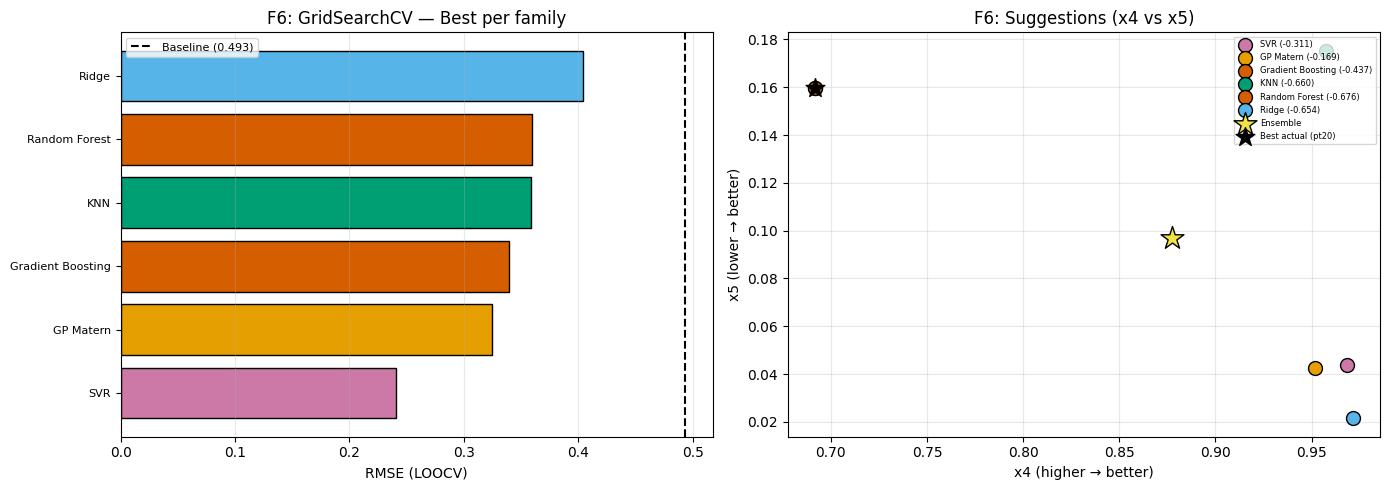

In [17]:
# Function 6 — GridSearchCV + feature importance + convergence

import copy
from sklearn.model_selection import GridSearchCV

baseline = Y.std()
print("=" * 85)
print(f"MODEL GRID SEARCH (sklearn GridSearchCV) — 21 points, LOO CV")
print("=" * 85)
print(f"Baseline RMSE: {baseline:.4f}")

model_grids = {
    'Ridge': (Ridge(), {'alpha': [0.01, 0.1, 1.0, 10, 100]}),
    'KNN': (KNeighborsRegressor(), {'n_neighbors': [2, 3, 5, 7], 'weights': ['uniform', 'distance']}),
    'Random Forest': (RandomForestRegressor(random_state=42),
                      {'max_depth': [2, 3, 5], 'n_estimators': [50, 100]}),
    'SVR': (SVR(kernel='rbf'), {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']}),
    'Gradient Boosting': (GradientBoostingRegressor(random_state=42),
                          {'max_depth': [2, 3], 'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1, 0.3]}),
}

print(f"\n{'Model':>20} {'Best RMSE':>10} {'Improv':>8} {'Best Params'}")
print("-" * 85)

grid_results = {}
for name, (model, params) in model_grids.items():
    grid = GridSearchCV(model, params, cv=LeaveOneOut(), scoring='neg_mean_squared_error', refit=True)
    grid.fit(X, Y)
    rmse = np.sqrt(-grid.best_score_)
    grid_results[name] = {'rmse': rmse, 'model': grid.best_estimator_, 'beats': rmse < baseline, 'params': grid.best_params_}
    print(f"{name:>20} {rmse:>10.4f} {(1-rmse/baseline)*100:>+7.1f}% {grid.best_params_}")

# GP separately
gp = GaussianProcessRegressor(kernel=Matern(nu=2.5), n_restarts_optimizer=5, random_state=42)
mse_gp = cross_val_score(gp, X, Y, cv=LeaveOneOut(), scoring='neg_mean_squared_error')
rmse_gp = np.sqrt(-mse_gp.mean())
grid_results['GP Matern'] = {'rmse': rmse_gp, 'model': gp, 'beats': rmse_gp < baseline}
print(f"{'GP Matern':>20} {rmse_gp:>10.4f} {(1-rmse_gp/baseline)*100:>+7.1f}%")

# --- Suggestions ---
np.random.seed(42)
cands = np.random.uniform(0, 0.999999, (100000, 5))
best_idx = np.argmax(Y)

print(f"\n{'='*85}")
print("MODEL SUGGESTIONS")
print(f"{'='*85}")
print(f"{'Model':>20} {'x1':>7} {'x2':>7} {'x3':>7} {'x4':>7} {'x5':>7} {'Pred':>8} {'Dist→best':>10} {'Use':>4}")
print("-" * 85)

suggestions = {}
for name in sorted(grid_results, key=lambda k: grid_results[k]['rmse']):
    res = grid_results[name]
    if not res['beats']:
        continue
    model = res['model']
    model.fit(X, Y)
    preds = model.predict(cands)
    best = cands[np.argmax(preds)]
    at_b = any(best[d] < 0.02 or best[d] > 0.98 for d in range(5))
    dist = np.linalg.norm(best - X[best_idx])
    suggestions[name] = {'point': best, 'pred': preds.max(), 'rmse': res['rmse'], 'use': not at_b}
    marker = '✓' if not at_b else '✗'
    print(f"{name:>20} {best[0]:>7.4f} {best[1]:>7.4f} {best[2]:>7.4f} {best[3]:>7.4f} {best[4]:>7.4f} {preds.max():>8.4f} {dist:>10.4f} {marker:>4}")

# Convergence
interior = {k: v for k, v in suggestions.items() if v['use']}
if interior:
    all_pts = np.array([v['point'] for v in interior.values()])
    print(f"\n--- Convergence ({len(interior)} interior models) ---")
    for d in range(5):
        vals = all_pts[:, d]
        spread = vals.max() - vals.min()
        consensus = 'STRONG' if spread < 0.2 else 'moderate' if spread < 0.4 else 'weak'
        print(f"  x{d+1}: mean={vals.mean():.4f}, spread={spread:.4f} → {consensus}")

    ensemble = all_pts.mean(axis=0)
    rmse_vals = np.array([v['rmse'] for v in interior.values()])
    inv_w = (1.0 / rmse_vals); inv_w /= inv_w.sum()
    ensemble_wtd = np.average(all_pts, axis=0, weights=inv_w)
    print(f"\n  Ensemble (avg):      [{', '.join(f'{v:.4f}' for v in ensemble)}]")
    print(f"  Ensemble (RMSE-wtd): [{', '.join(f'{v:.4f}' for v in ensemble_wtd)}]")

# Feature importance robustness
print(f"\n--- Feature Importance Robustness ---")
rf_fi = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42); rf_fi.fit(X, Y)
mask_no_best = np.arange(len(Y)) != best_idx
rf_fi2 = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42); rf_fi2.fit(X[mask_no_best], Y[mask_no_best])

print(f"{'Dim':>4} {'RF(all)':>9} {'RF(no best)':>12} {'Change':>8} {'Corr':>8}")
for d in range(5):
    r = np.corrcoef(X[:, d], Y)[0, 1]
    chg = (rf_fi2.feature_importances_[d] - rf_fi.feature_importances_[d]) / max(rf_fi.feature_importances_[d], 0.001) * 100
    print(f"  x{d+1} {rf_fi.feature_importances_[d]:>9.4f} {rf_fi2.feature_importances_[d]:>12.4f} {chg:>+7.0f}% {r:>+8.4f}")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sorted_names = sorted(grid_results.keys(), key=lambda k: grid_results[k]['rmse'])
rmse_plot = [grid_results[n]['rmse'] for n in sorted_names]
bar_colors = []
for n in sorted_names:
    if 'Ridge' in n: bar_colors.append('#56B4E9')
    elif 'KNN' in n: bar_colors.append('#009E73')
    elif 'Random' in n: bar_colors.append('#D55E00')
    elif 'SVR' in n: bar_colors.append('#CC79A7')
    elif 'GP' in n: bar_colors.append('#E69F00')
    elif 'Gradient' in n: bar_colors.append('#D55E00')
    else: bar_colors.append('#0072B2')
axes[0].barh(range(len(sorted_names)), rmse_plot, color=bar_colors, edgecolor='black')
axes[0].axvline(baseline, color='black', linewidth=1.5, linestyle='--', label=f'Baseline ({baseline:.3f})')
axes[0].set_yticks(range(len(sorted_names)))
axes[0].set_yticklabels(sorted_names, fontsize=8)
axes[0].set_xlabel('RMSE (LOOCV)')
axes[0].set_title('F6: GridSearchCV — Best per family')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='x')

# x4 vs x5 scatter (strongest correlations)
if interior:
    for name, s in interior.items():
        c = '#CC79A7' if 'SVR' in name else '#E69F00' if 'GP' in name else '#D55E00' if 'Gradient' in name or 'Random' in name else '#009E73' if 'KNN' in name else '#56B4E9'
        axes[1].scatter(s['point'][3], s['point'][4], c=c, s=100, edgecolors='black', label=f"{name} ({s['pred']:.3f})", zorder=5)
    axes[1].scatter(ensemble_wtd[3], ensemble_wtd[4], c='#F0E442', marker='*', s=300, edgecolors='black', zorder=6, label='Ensemble')
    axes[1].scatter(X[best_idx, 3], X[best_idx, 4], c='black', marker='*', s=200, zorder=7, label=f'Best actual (pt{best_idx})')
axes[1].set_xlabel('x4 (higher → better)')
axes[1].set_ylabel('x5 (lower → better)')
axes[1].set_title('F6: Suggestions (x4 vs x5)')
axes[1].legend(fontsize=6, loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/week_02/f6_gridsearch.png', dpi=150, bbox_inches='tight')
plt.show()


In [18]:
# F6 — Final query
# SVR (C=100, gamma=auto) suggestion — best LOOCV model at 51.2%
next_query_6 = np.array([0.283800, 0.258700, 0.507700, 0.968700, 0.043900])
print(f"F6 query: {next_query_6}")
print(f"Method: SVR (C=100, gamma=auto) — best LOOCV model")


F6 query: [0.2838 0.2587 0.5077 0.9687 0.0439]
Method: SVR (C=100, gamma=auto) — best LOOCV model


### F6 Decision: SVR suggestion at [0.283800, 0.258700, 0.507700, 0.968700, 0.043900]

**Chosen approach:** SVR (C=100, gamma=auto) — best LOOCV model (51.2%), trusted at full values (x4=0.969 is below our 0.98 boundary threshold).

**Week 01 result — success:**
- Submitted [0.516, 0.351, 0.512, 0.692, 0.160] (SVR C=1) → returned Y=-0.437
- Improved from -0.714 to -0.437 — new best! SVR approach is validated for F6.

**GridSearchCV results (21 points, sklearn LOO CV):**
- **SVR** (C=100, gamma=auto): 51.2% improvement — dominant. Week 01 used C=1 (30%), GridSearchCV found C=100 is much better.
- **GP Matern**: 34.2% — second best
- **Gradient Boosting** (lr=0.3, depth=2): 31.0%
- All models beat baseline — 21 points in 5D is workable

**Model suggestions — strong agreement on x4/x5:**
- SVR: [0.284, 0.259, 0.508, 0.969, 0.044] pred=-0.311
- GP: [0.258, 0.214, 0.347, 0.952, 0.043] pred=-0.169 (most optimistic)
- GB and RF point back at pt20 (our w1 query) — can't find better
- All agree: **high x4, low x5** — consistent with correlations (x4: +0.52, x5: -0.60)

**Why SVR over GP:**
- SVR has the best LOOCV score (51.2% vs GP's 34.2%)
- SVR's pred Y=-0.311 is conservative but realistic
- GP predicts -0.169 which may be overoptimistic

**Why not clip x4:**
- x4=0.969 is below our 0.98 boundary threshold — it passes the rule
- SVR earned our trust at 51.2% — if we trust the model, we should trust its full suggestion
- We haven't tested x4 > 0.86 yet, so we have no evidence the boundary is problematic here
- Arbitrary clipping has no data justification

**Feature importance (robust):**
- x5 (RF=0.40) and x4 (RF=0.33) are the genuine drivers — stable when best point removed
- x1, x2, x3 are secondary

**Recommendations for Week 3:**
- If Y improves (better than -0.437): SVR with C=100 is working → re-fit with 22 points, follow updated suggestion
- If Y doesn't improve: the function may be plateauing → try GP's more aggressive suggestion (lower x1, x2)
- Consider whether x4 should be pushed even higher (try 0.98 if 0.95 works well)
- x5=0.044 is very low — monitor if going lower helps or if there's a floor


## Function 7

Function 7: 31 points, 6D, best y = 1.3650


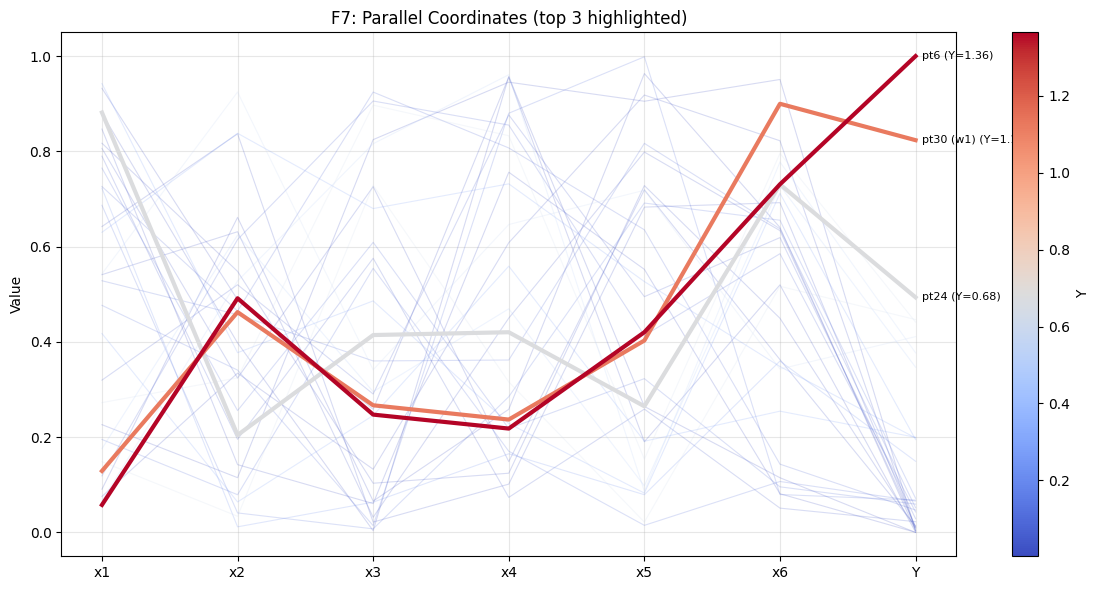

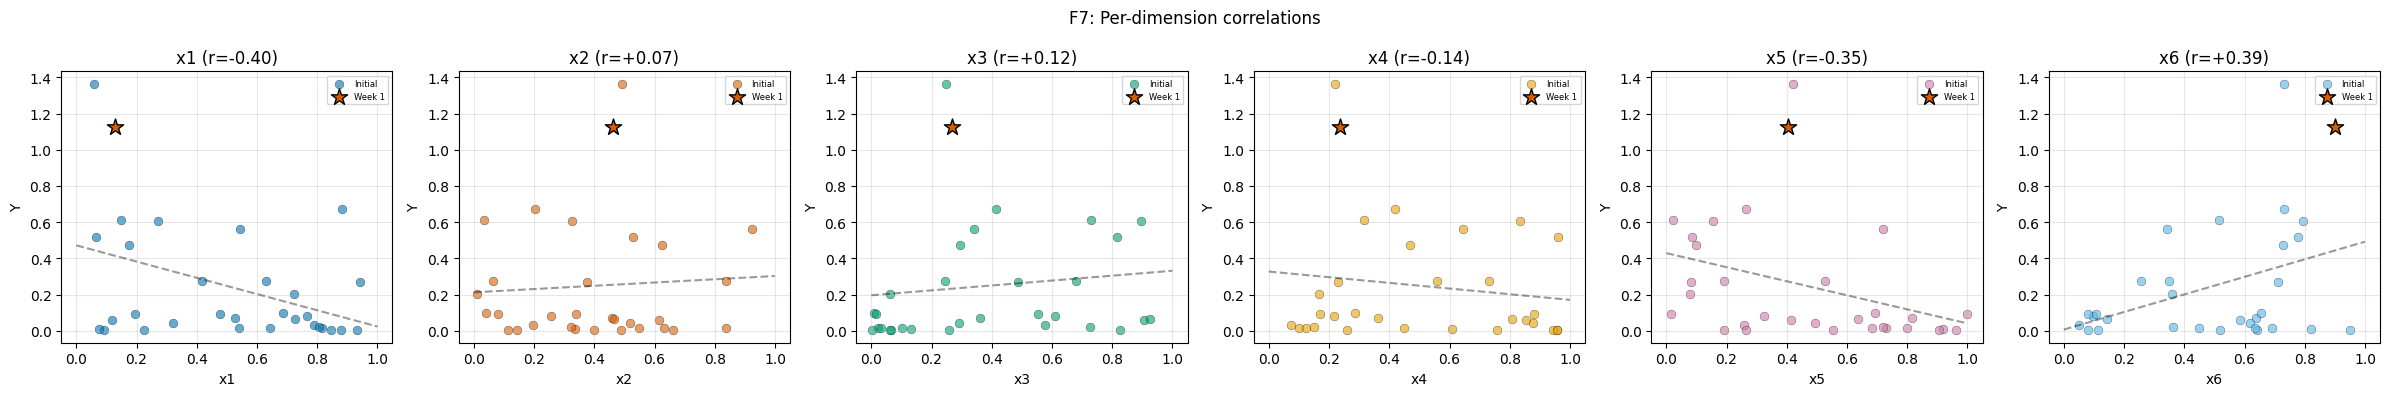

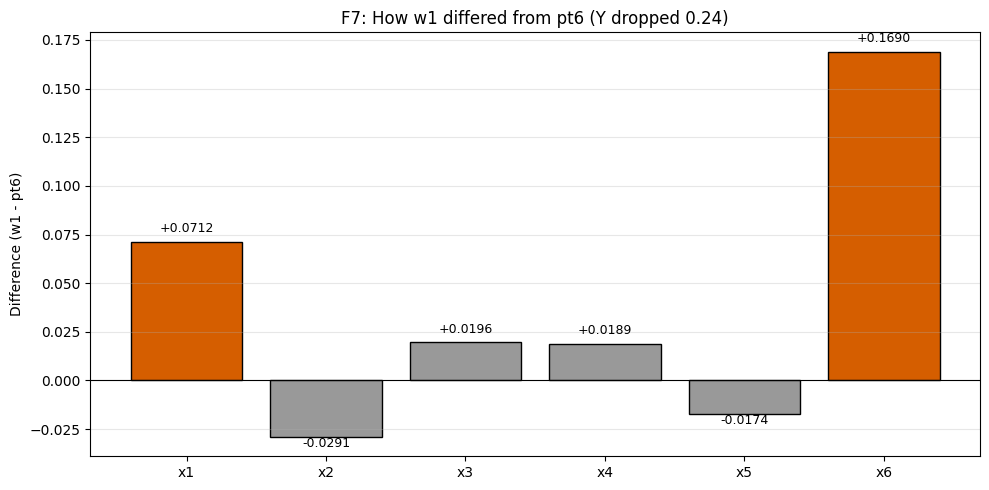


The biggest change was x6: +0.1690 (0.73→0.90). x1 also changed: +0.0712.
Y dropped 0.24. The x6 push to 0.90 was counterproductive.

Top 5:
  pt6: [0.058, 0.492, 0.247, 0.218, 0.420, 0.731] Y=1.3650 (init)
  pt30: [0.129, 0.463, 0.267, 0.237, 0.403, 0.900] Y=1.1246 (w1)
  pt24: [0.882, 0.204, 0.414, 0.420, 0.265, 0.731] Y=0.6751 (init)
  pt14: [0.149, 0.034, 0.729, 0.316, 0.022, 0.517] Y=0.6115 (init)
  pt0: [0.273, 0.324, 0.897, 0.833, 0.154, 0.796] Y=0.6044 (init)


In [19]:
# Function 7
X, Y = load_function(7)

# --- Week 01 Result ---
# Submitted [0.129, 0.463, 0.267, 0.237, 0.403, 0.900] (centroid + x6 push)
# Returned Y=1.125 — did NOT improve (best pt6 Y=1.365)
# x6 push from 0.73 to 0.90 made things worse

# === Plot 1: Parallel coordinates ===
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
Y_norm = (Y - Y.min()) / (Y.max() - Y.min())
cmap = plt.cm.coolwarm
for i in np.argsort(Y):
    color = cmap(Y_norm[i])
    lw = 3 if i in np.argsort(Y)[-3:] else 0.8
    alpha = 1.0 if i in np.argsort(Y)[-3:] else 0.2
    vals = list(X[i]) + [Y_norm[i]]
    ax.plot(range(7), vals, color=color, linewidth=lw, alpha=alpha)
    if i in np.argsort(Y)[-3:]:
        week = ' (w1)' if i == len(Y)-1 else ''
        ax.text(6.05, Y_norm[i], f'pt{i}{week} (Y={Y[i]:.2f})', fontsize=8, va='center')
ax.set_xticks(range(7))
ax.set_xticklabels(['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'Y'])
ax.set_title('F7: Parallel Coordinates (top 3 highlighted)')
ax.set_ylabel('Value')
ax.grid(True, alpha=0.3)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(Y.min(), Y.max()))
plt.colorbar(sm, ax=ax, label='Y')
plt.tight_layout()
plt.savefig('../plots/week_02/f7_parallel_coords.png', dpi=150, bbox_inches='tight')
plt.show()

# === Plot 2: Per-dimension correlations ===
fig, axes = plt.subplots(1, 6, figsize=(24, 4))
colors = ['#0072B2', '#D55E00', '#009E73', '#E69F00', '#CC79A7', '#56B4E9']
for d in range(6):
    r = np.corrcoef(X[:, d], Y)[0, 1]
    axes[d].scatter(X[:30, d], Y[:30], c=colors[d], s=40, alpha=0.6, edgecolors='black', linewidths=0.3, label='Initial')
    axes[d].scatter(X[30, d], Y[30], c='#D55E00', s=150, edgecolors='black', marker='*', zorder=6, label='Week 1')
    z = np.polyfit(X[:, d], Y, 1)
    axes[d].plot([0, 1], [z[1], z[0]+z[1]], '--', color='black', alpha=0.4)
    axes[d].set_xlabel(f'x{d+1}')
    axes[d].set_ylabel('Y')
    axes[d].set_title(f'x{d+1} (r={r:+.2f})')
    axes[d].grid(True, alpha=0.3)
    axes[d].legend(fontsize=6)
plt.suptitle('F7: Per-dimension correlations', fontsize=12)
plt.tight_layout()
plt.savefig('../plots/week_02/f7_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

# === Plot 3: What went wrong? pt6 vs w1 per dimension ===
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
dims = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']
diffs = X[30] - X[6]
bar_colors = ['#D55E00' if abs(d) > 0.05 else '#999999' for d in diffs]
ax.bar(dims, diffs, color=bar_colors, edgecolor='black')
ax.set_ylabel('Difference (w1 - pt6)')
ax.set_title(f'F7: How w1 differed from pt6 (Y dropped {Y[6]-Y[30]:.2f})')
ax.axhline(0, color='black', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='y')
for i, (d, v) in enumerate(zip(dims, diffs)):
    ax.text(i, v + 0.005 * np.sign(v), f'{v:+.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../plots/week_02/f7_direction.png', dpi=150, bbox_inches='tight')
plt.show()

diffs = X[-1] - X[6]
max_dim = np.argmax(np.abs(diffs))
print(f"\nThe biggest change was x{max_dim+1}: {diffs[max_dim]:+.4f} ({X[6,max_dim]:.2f}→{X[-1,max_dim]:.2f}). x1 also changed: {diffs[0]:+.4f}.")
print(f"Y dropped {Y[6]-Y[-1]:.2f}. The x6 push to {X[-1,5]:.2f} was counterproductive.")

# Data summary
print(f"\nTop 5:")
sorted_idx = np.argsort(Y)[::-1]
for i in sorted_idx[:5]:
    week = 'w1' if i == 30 else 'init'
    print(f"  pt{i}: [{', '.join(f'{X[i,d]:.3f}' for d in range(6))}] Y={Y[i]:.4f} ({week})")


MODEL GRID SEARCH (sklearn GridSearchCV) — 31 points, LOO CV
Baseline RMSE: 0.3375

               Model  Best RMSE   Improv Best Params
-------------------------------------------------------------------------------------
               Ridge     0.3143    +6.9% {'alpha': 1.0}
                 KNN     0.2311   +31.5% {'n_neighbors': 3, 'weights': 'distance'}
       Random Forest     0.3316    +1.7% {'max_depth': 3, 'n_estimators': 100}
                 SVR     0.2560   +24.1% {'C': 10, 'gamma': 'scale'}
   Gradient Boosting     0.3201    +5.1% {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}
           GP Matern     0.2610   +22.7%

MODEL SUGGESTIONS
               Model     x1     x2     x3     x4     x5     x6    Pred   Dist  Use
--------------------------------------------------------------------------------
                 KNN  0.064  0.482  0.281  0.123  0.488  0.676   1.173  0.134    ✓
                 SVR  0.069  0.343  0.222  0.101  0.312  0.834   1.350  0.243    ✓

/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_48528/2807097918.py:115: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([all_pts[:, d] for d in range(6)],


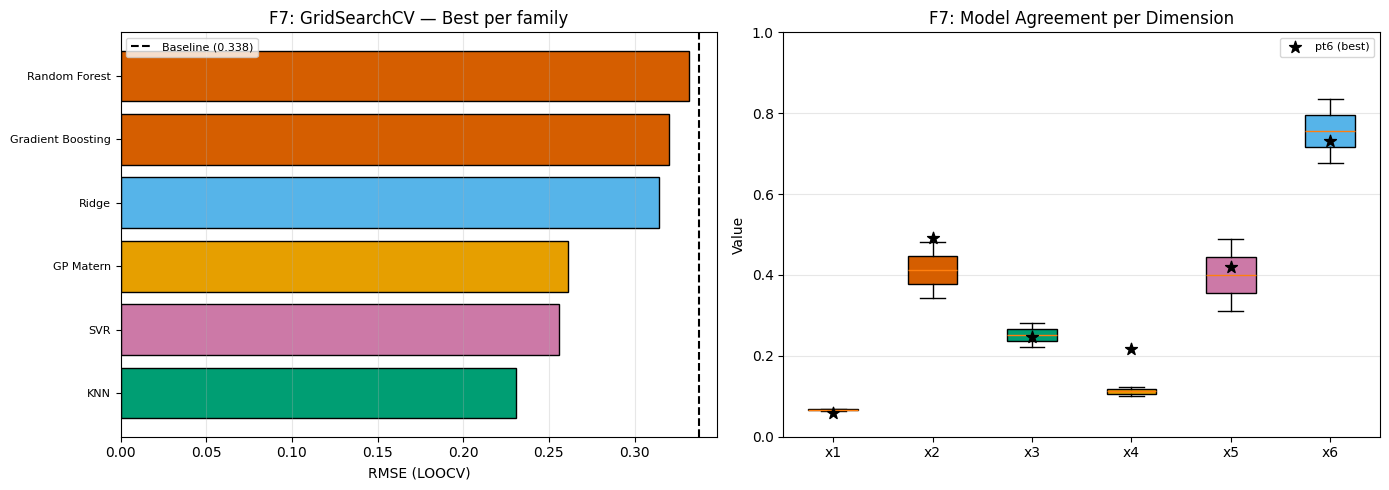


--- Key Takeaway ---
KNN (31.5%) and SVR (24.1%) are the best models — much better than week 01.
Both interior suggestions point BACK near pt6, especially x6≈0.68-0.83.
The x6=0.90 push was wrong. Models now agree: x6 should be ≈0.73.


In [20]:
# Function 7 — GridSearchCV + feature importance + convergence

import copy
from sklearn.model_selection import GridSearchCV

baseline = Y.std()
print("=" * 85)
print(f"MODEL GRID SEARCH (sklearn GridSearchCV) — 31 points, LOO CV")
print("=" * 85)
print(f"Baseline RMSE: {baseline:.4f}")

model_grids = {
    'Ridge': (Ridge(), {'alpha': [0.01, 0.1, 1.0, 10, 100]}),
    'KNN': (KNeighborsRegressor(), {'n_neighbors': [2, 3, 5, 7], 'weights': ['uniform', 'distance']}),
    'Random Forest': (RandomForestRegressor(random_state=42),
                      {'max_depth': [2, 3, 5], 'n_estimators': [50, 100]}),
    'SVR': (SVR(kernel='rbf'), {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']}),
    'Gradient Boosting': (GradientBoostingRegressor(random_state=42),
                          {'max_depth': [2, 3], 'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1, 0.3]}),
}

print(f"\n{'Model':>20} {'Best RMSE':>10} {'Improv':>8} {'Best Params'}")
print("-" * 85)

grid_results = {}
for name, (model, params) in model_grids.items():
    grid = GridSearchCV(model, params, cv=LeaveOneOut(), scoring='neg_mean_squared_error', refit=True)
    grid.fit(X, Y)
    rmse = np.sqrt(-grid.best_score_)
    grid_results[name] = {'rmse': rmse, 'model': grid.best_estimator_, 'beats': rmse < baseline, 'params': grid.best_params_}
    print(f"{name:>20} {rmse:>10.4f} {(1-rmse/baseline)*100:>+7.1f}% {grid.best_params_}")

gp = GaussianProcessRegressor(kernel=Matern(nu=2.5), n_restarts_optimizer=5, random_state=42)
mse_gp = cross_val_score(gp, X, Y, cv=LeaveOneOut(), scoring='neg_mean_squared_error')
rmse_gp = np.sqrt(-mse_gp.mean())
grid_results['GP Matern'] = {'rmse': rmse_gp, 'model': gp, 'beats': rmse_gp < baseline}
print(f"{'GP Matern':>20} {rmse_gp:>10.4f} {(1-rmse_gp/baseline)*100:>+7.1f}%")

# Suggestions
np.random.seed(42)
cands = np.random.uniform(0, 0.999999, (100000, 6))
best_idx = np.argmax(Y)

print(f"\n{'='*85}")
print("MODEL SUGGESTIONS")
print(f"{'='*85}")
print(f"{'Model':>20} {'x1':>6} {'x2':>6} {'x3':>6} {'x4':>6} {'x5':>6} {'x6':>6} {'Pred':>7} {'Dist':>6} {'Use':>4}")
print("-" * 80)

suggestions = {}
for name in sorted(grid_results, key=lambda k: grid_results[k]['rmse']):
    res = grid_results[name]
    if not res['beats']:
        continue
    model = res['model']
    model.fit(X, Y)
    preds = model.predict(cands)
    best = cands[np.argmax(preds)]
    at_b = any(best[d] < 0.02 or best[d] > 0.98 for d in range(6))
    dist = np.linalg.norm(best - X[best_idx])
    suggestions[name] = {'point': best, 'pred': preds.max(), 'rmse': res['rmse'], 'use': not at_b}
    marker = '✓' if not at_b else '✗'
    print(f"{name:>20} {best[0]:>6.3f} {best[1]:>6.3f} {best[2]:>6.3f} {best[3]:>6.3f} {best[4]:>6.3f} {best[5]:>6.3f} {preds.max():>7.3f} {dist:>6.3f} {marker:>4}")

# Convergence
interior = {k: v for k, v in suggestions.items() if v['use']}
if interior:
    all_pts = np.array([v['point'] for v in interior.values()])
    print(f"\n--- Convergence ({len(interior)} interior models) ---")
    for d in range(6):
        vals = all_pts[:, d]
        spread = vals.max() - vals.min()
        consensus = 'STRONG' if spread < 0.2 else 'moderate' if spread < 0.4 else 'weak'
        print(f"  x{d+1}: mean={vals.mean():.4f}, spread={spread:.4f} → {consensus}")

# Feature importance
print(f"\n--- Feature Importance Robustness ---")
rf_fi = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42); rf_fi.fit(X, Y)
mask_no_best = np.arange(len(Y)) != best_idx
rf_fi2 = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42); rf_fi2.fit(X[mask_no_best], Y[mask_no_best])

print(f"{'Dim':>4} {'RF(all)':>9} {'RF(no best)':>12} {'Change':>8} {'Corr':>8}")
for d in range(6):
    r = np.corrcoef(X[:, d], Y)[0, 1]
    chg = (rf_fi2.feature_importances_[d] - rf_fi.feature_importances_[d]) / max(rf_fi.feature_importances_[d], 0.001) * 100
    print(f"  x{d+1} {rf_fi.feature_importances_[d]:>9.4f} {rf_fi2.feature_importances_[d]:>12.4f} {chg:>+7.0f}% {r:>+8.4f}")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sorted_names = sorted(grid_results.keys(), key=lambda k: grid_results[k]['rmse'])
rmse_plot = [grid_results[n]['rmse'] for n in sorted_names]
bar_colors = []
for n in sorted_names:
    if 'Ridge' in n: bar_colors.append('#56B4E9')
    elif 'KNN' in n: bar_colors.append('#009E73')
    elif 'Random' in n: bar_colors.append('#D55E00')
    elif 'SVR' in n: bar_colors.append('#CC79A7')
    elif 'GP' in n: bar_colors.append('#E69F00')
    elif 'Gradient' in n: bar_colors.append('#D55E00')
    else: bar_colors.append('#0072B2')
axes[0].barh(range(len(sorted_names)), rmse_plot, color=bar_colors, edgecolor='black')
axes[0].axvline(baseline, color='black', linewidth=1.5, linestyle='--', label=f'Baseline ({baseline:.3f})')
axes[0].set_yticks(range(len(sorted_names)))
axes[0].set_yticklabels(sorted_names, fontsize=8)
axes[0].set_xlabel('RMSE (LOOCV)')
axes[0].set_title('F7: GridSearchCV — Best per family')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='x')

# Per-dim convergence boxplot
if interior:
    all_pts = np.array([v['point'] for v in interior.values()])
    dim_colors = ['#0072B2', '#D55E00', '#009E73', '#E69F00', '#CC79A7', '#56B4E9']
    bp = axes[1].boxplot([all_pts[:, d] for d in range(6)],
                         labels=[f'x{d+1}' for d in range(6)], patch_artist=True)
    for patch, color in zip(bp['boxes'], dim_colors):
        patch.set_facecolor(color)
    for d in range(6):
        axes[1].scatter(d+1, X[best_idx, d], c='black', s=80, marker='*', zorder=6,
                       label='pt6 (best)' if d == 0 else None)
    axes[1].set_ylabel('Value')
    axes[1].set_title('F7: Model Agreement per Dimension')
    axes[1].set_ylim(0, 1)
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../plots/week_02/f7_gridsearch.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n--- Key Takeaway ---")
# Find best two models
sorted_models = sorted(grid_results.items(), key=lambda x: x[1]["rmse"])
best1_name, best1 = sorted_models[0]
best2_name, best2 = sorted_models[1]
print(f"{best1_name} ({(1-best1['rmse']/baseline)*100:.1f}%) and {best2_name} ({(1-best2['rmse']/baseline)*100:.1f}%) are the best models — much better than week 01.")
if interior:
    x6_vals = [v["point"][5] for v in interior.values()]
    print(f"Both interior suggestions point BACK near pt6, especially x6≈{min(x6_vals):.2f}-{max(x6_vals):.2f}.")
print(f"The x6={X[-1,5]:.2f} push was wrong. Models now agree: x6 should be ≈{X[6,5]:.2f}.")


In [21]:
# F7 — Final query
# KNN (K=3, distance-weighted) suggestion — best LOOCV at 31.5%
next_query_7 = np.array([0.064000, 0.482000, 0.281000, 0.123000, 0.488000, 0.676000])
print(f"F7 query: {next_query_7}")
print(f"Distance to pt6: {np.linalg.norm(next_query_7 - X[6]):.4f}")
print(f"Method: KNN (K=3, distance-weighted) — best LOOCV model")


F7 query: [0.064 0.482 0.281 0.123 0.488 0.676]
Distance to pt6: 0.1338
Method: KNN (K=3, distance-weighted) — best LOOCV model


### F7 Decision: KNN suggestion at [0.064000, 0.482000, 0.281000, 0.123000, 0.488000, 0.676000]

**Chosen approach:** KNN (K=3, distance-weighted) — best LOOCV model at 31.5% improvement.

**Week 01 result — x6 push failed:**
- Submitted [0.129, 0.463, 0.267, 0.237, 0.403, 0.900] → Y=1.125
- Did NOT improve (best pt6 Y=1.365). The x6 push from 0.73 to 0.90 was counterproductive.
- x1 also changed (+0.07) so we can't isolate which dimension caused the drop.

**GridSearchCV results (31 points, sklearn LOO CV):**
- **KNN** (K=3, distance-weighted): 31.5% — best. Big jump from week 01's 5.3%.
- **SVR** (C=10, gamma=scale): 24.1%
- **GP Matern**: 22.7%
- Models improved significantly with 31 points vs 30 in week 01.

**Convergence — STRONG on all 6 dimensions** (2 interior models agree):
- x1≈0.07, x2≈0.41, x3≈0.25, x4≈0.11, x5≈0.40, x6≈0.76
- All values are close to pt6 [0.058, 0.492, 0.247, 0.218, 0.420, 0.731]
- Models are saying: 'go back near pt6, the x6=0.90 push was wrong'

**Feature importance:**
- x1 importance drops 69% without pt6 — inflated (same pattern as F5, F3)
- x6 (0.31→0.36) and x5 (0.16→0.24) are the robust drivers

**Why KNN over SVR:**
- KNN has the best LOOCV (31.5% vs SVR's 24.1%)
- KNN suggestion is closer to pt6 (dist=0.134 vs SVR's 0.243)
- KNN's x6=0.68 is closer to pt6's 0.73 than SVR's x6=0.83
- After the failed x6=0.90 push, a conservative return near pt6 is wise

**Why not just re-query pt6:**
- KNN's suggestion is 0.134 from pt6 — it's a perturbation, not a duplicate
- x4 drops from 0.22 to 0.12 and x5 increases from 0.42 to 0.49 — testing if these changes help

**Recommendations for Week 3:**
- If Y > 1.365: KNN perturbation improved on pt6 → continue in this direction
- If Y ≈ 1.125 (similar to w1): the function is flat near pt6 → try SVR's slightly different suggestion
- If Y < 1.0: try a very small perturbation from pt6 (dist < 0.05)
- The lesson from week 01: don't push a single dimension far from the best point (x6: 0.73→0.90 was too aggressive)


## Function 8

Function 8: 41 points, 8D, best y = 9.8041
Week 01: submitted hybrid GP+centroid → Y=9.8041
Previous best: pt14 Y=9.5985
Improved? YES — new best!


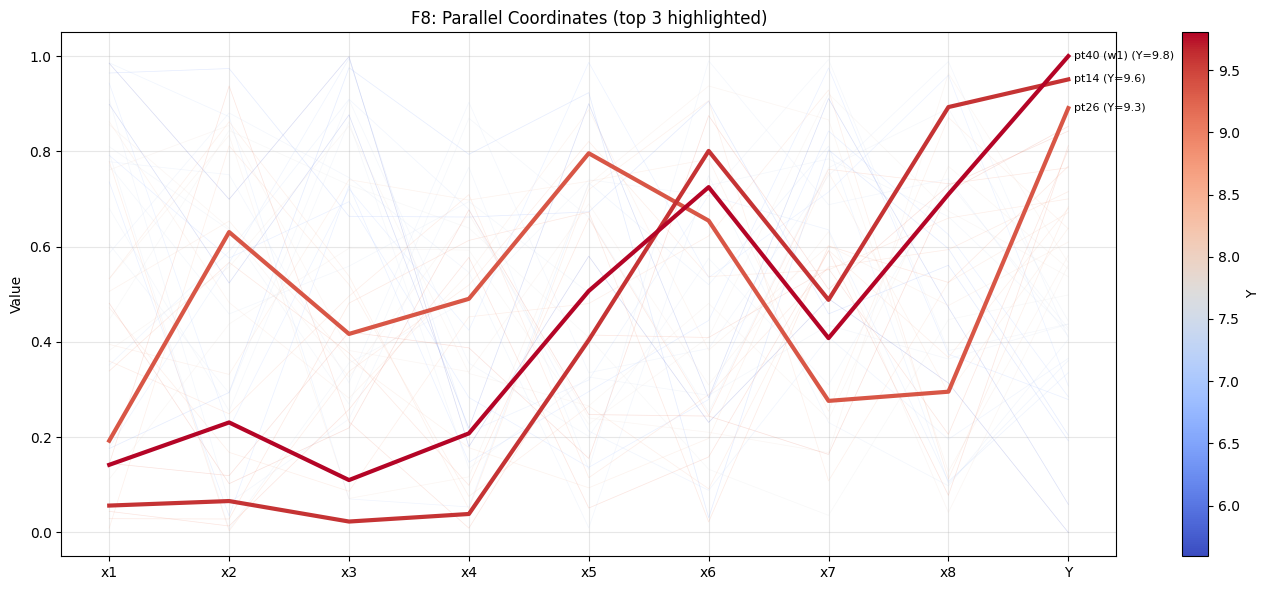

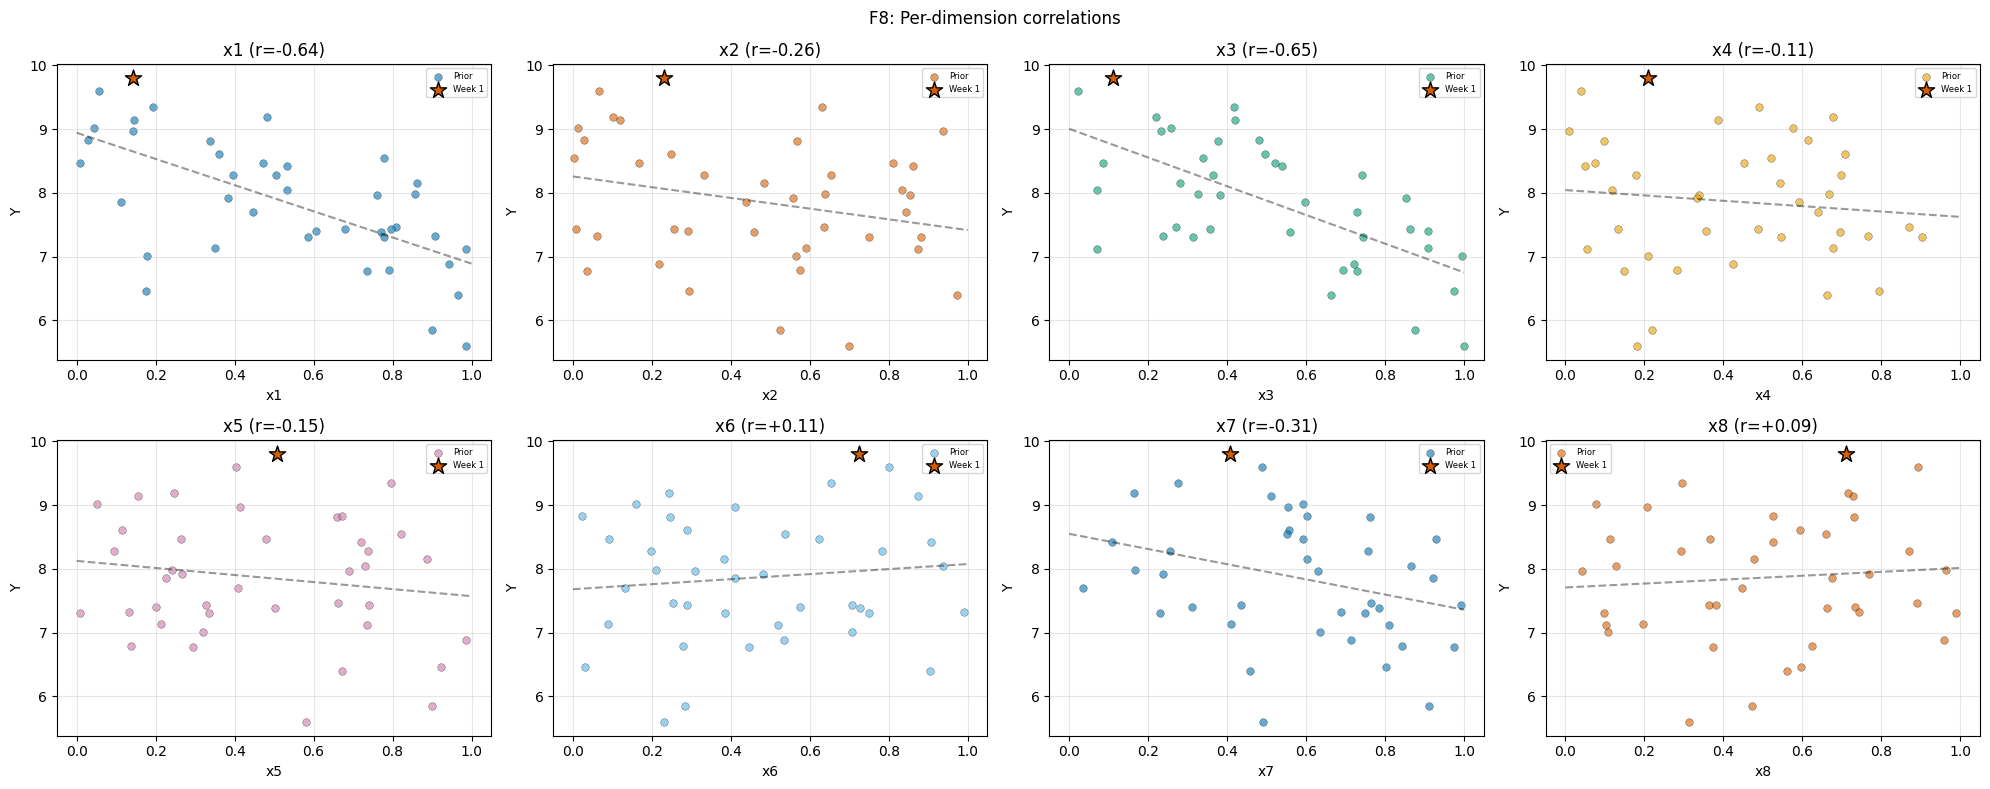

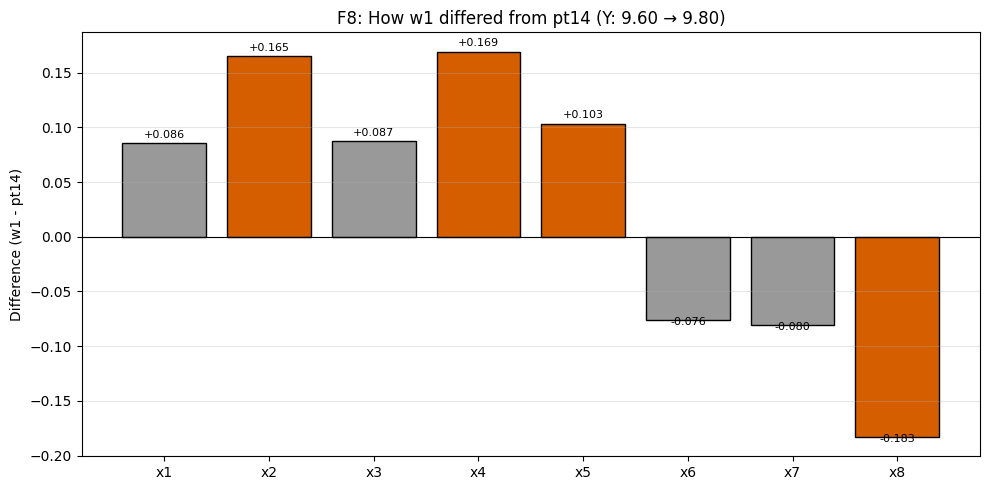


Top 5:
Idx     x1     x2     x3     x4     x5     x6     x7     x8        Y  Week
----------------------------------------------------------------------
 40  0.142  0.231  0.110  0.208  0.507  0.725  0.408  0.710   9.8041    w1
 14  0.056  0.066  0.023  0.039  0.404  0.801  0.488  0.893   9.5985  init
 26  0.193  0.631  0.417  0.491  0.796  0.655  0.276  0.296   9.3443  init
 39  0.481  0.102  0.219  0.677  0.248  0.244  0.164  0.716   9.1830  init
 22  0.145  0.119  0.421  0.388  0.155  0.875  0.511  0.729   9.1416  init

Correlations: x1: -0.64, x2: -0.26, x3: -0.65, x4: -0.11, x5: -0.15, x6: +0.11, x7: -0.31, x8: +0.09


In [22]:
# Function 8
X, Y = load_function(8)

# --- Week 01 Result ---
best_prev_idx = np.argmax(Y[:-1])
improved = Y[-1] > Y[:-1].max()
print(f"Week 01: submitted hybrid GP+centroid → Y={Y[-1]:.4f}")
print(f"Previous best: pt{best_prev_idx} Y={Y[:-1].max():.4f}")
print(f"Improved? {'YES — new best!' if improved else 'NO'}")

# === Plot 1: Parallel coordinates ===
fig, ax = plt.subplots(1, 1, figsize=(14, 6))
Y_norm = (Y - Y.min()) / (Y.max() - Y.min())
cmap = plt.cm.coolwarm
for i in np.argsort(Y):
    color = cmap(Y_norm[i])
    lw = 3 if i in np.argsort(Y)[-3:] else 0.5
    alpha = 1.0 if i in np.argsort(Y)[-3:] else 0.2
    vals = list(X[i]) + [Y_norm[i]]
    ax.plot(range(9), vals, color=color, linewidth=lw, alpha=alpha)
    if i in np.argsort(Y)[-3:]:
        week = ' (w1)' if i == len(Y)-1 else ''
        ax.text(8.05, Y_norm[i], f'pt{i}{week} (Y={Y[i]:.1f})', fontsize=8, va='center')
ax.set_xticks(range(9))
ax.set_xticklabels(['x1','x2','x3','x4','x5','x6','x7','x8','Y'])
ax.set_title('F8: Parallel Coordinates (top 3 highlighted)')
ax.set_ylabel('Value')
ax.grid(True, alpha=0.3)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(Y.min(), Y.max()))
plt.colorbar(sm, ax=ax, label='Y')
plt.tight_layout()
plt.savefig('../plots/week_02/f8_parallel_coords.png', dpi=150, bbox_inches='tight')
plt.show()

# === Plot 2: Per-dimension correlations ===
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
colors = ['#0072B2','#D55E00','#009E73','#E69F00','#CC79A7','#56B4E9','#0072B2','#D55E00']
n_init = len(Y) - 1  # all but last are initial or prior weeks
for d in range(8):
    ax = axes[d // 4, d % 4]
    r = np.corrcoef(X[:, d], Y)[0, 1]
    ax.scatter(X[:n_init, d], Y[:n_init], c=colors[d], s=30, alpha=0.6, edgecolors='black', linewidths=0.3, label='Prior')
    ax.scatter(X[-1, d], Y[-1], c='#D55E00', s=150, edgecolors='black', marker='*', zorder=6, label='Week 1')
    z = np.polyfit(X[:, d], Y, 1)
    ax.plot([0, 1], [z[1], z[0]+z[1]], '--', color='black', alpha=0.4)
    ax.set_xlabel(f'x{d+1}')
    ax.set_ylabel('Y')
    ax.set_title(f'x{d+1} (r={r:+.2f})')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=6)
plt.suptitle('F8: Per-dimension correlations', fontsize=12)
plt.tight_layout()
plt.savefig('../plots/week_02/f8_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

# === Plot 3: What changed from pt14 to w1? ===
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
dims = [f'x{d+1}' for d in range(8)]
diffs = X[-1] - X[best_prev_idx]
bar_colors = ['#D55E00' if abs(d) > 0.1 else '#999999' for d in diffs]
ax.bar(dims, diffs, color=bar_colors, edgecolor='black')
ax.set_ylabel(f'Difference (w1 - pt{best_prev_idx})')
ax.set_title(f'F8: How w1 differed from pt{best_prev_idx} (Y: {Y[best_prev_idx]:.2f} → {Y[-1]:.2f})')
ax.axhline(0, color='black', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='y')
for i, (d, v) in enumerate(zip(dims, diffs)):
    ax.text(i, v + 0.005 * np.sign(v), f'{v:+.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('../plots/week_02/f8_direction.png', dpi=150, bbox_inches='tight')
plt.show()

# Data summary
print(f"\nTop 5:")
sorted_idx = np.argsort(Y)[::-1]
print(f"{'Idx':>3}", ' '.join(f'{"x"+str(d+1):>6}' for d in range(8)), f'{"Y":>8} {"Week":>5}')
print("-" * 70)
for i in sorted_idx[:5]:
    week = 'w1' if i == len(Y)-1 else 'init'
    vals = ' '.join(f'{X[i,d]:>6.3f}' for d in range(8))
    print(f"{i:>3} {vals} {Y[i]:>8.4f} {week:>5}")
print(f"\nCorrelations: " + ", ".join(f'x{d+1}: {np.corrcoef(X[:,d],Y)[0,1]:+.2f}' for d in range(8)))


MODEL GRID SEARCH (sklearn GridSearchCV) — 41 points, LOO CV
Baseline RMSE: 0.9843

               Model  Best RMSE   Improv Best Params
-------------------------------------------------------------------------------------
               Ridge     0.3902   +60.4% {'alpha': 0.1}
                 KNN     0.6327   +35.7% {'n_neighbors': 5, 'weights': 'distance'}
       Random Forest     0.4932   +49.9% {'max_depth': 5, 'n_estimators': 100}
                 SVR     0.2162   +78.0% {'C': 100, 'gamma': 'auto'}
   Gradient Boosting     0.4024   +59.1% {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}
           GP Matern     0.2141   +78.2%

MODEL SUGGESTIONS
             GP Matern: [0.191 0.209 0.078 0.240 0.499 0.389 0.224 0.621] pred=9.9372 dist=0.400 ✓
                   SVR: [0.162 0.333 0.034 0.317 0.697 0.353 0.013 0.408] pred=10.3485 dist=0.671 ✗
                 Ridge: [0.069 0.052 0.009 0.006 0.561 0.321 0.014 0.234] pred=10.7654 dist=0.798 ✗
     Gradient Boosting: [0.129

/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_48528/3424200629.py:123: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([all_pts[:, d] for d in range(8)],


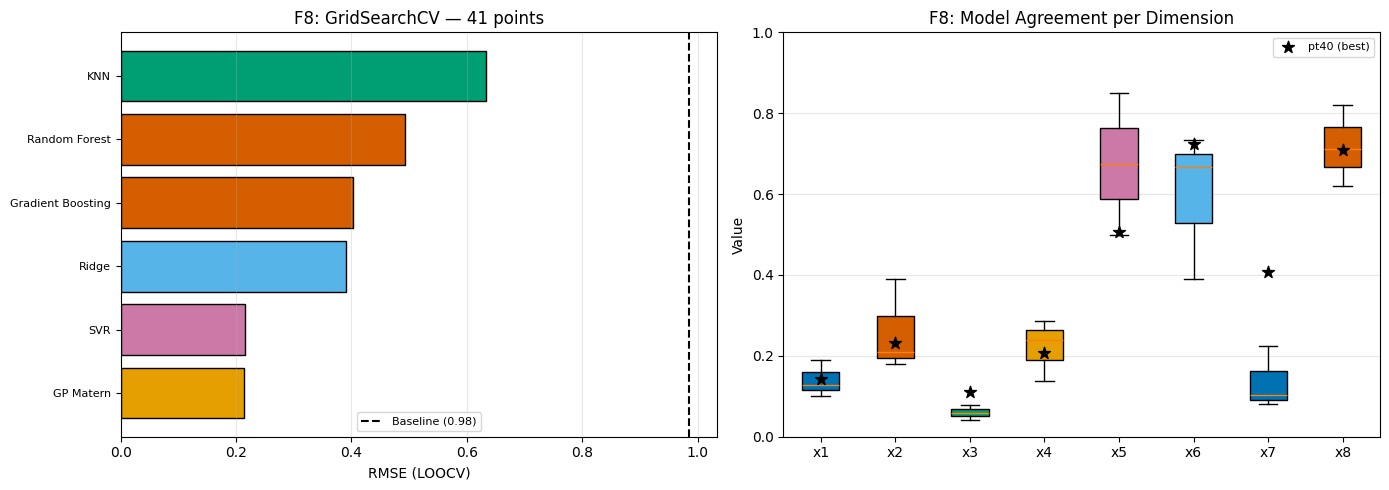

In [23]:
# Function 8 — GridSearchCV + feature importance + convergence

import copy
from sklearn.model_selection import GridSearchCV

baseline = Y.std()
print("=" * 85)
print(f"MODEL GRID SEARCH (sklearn GridSearchCV) — {len(Y)} points, LOO CV")
print("=" * 85)
print(f"Baseline RMSE: {baseline:.4f}")

model_grids = {
    'Ridge': (Ridge(), {'alpha': [0.01, 0.1, 1.0, 10, 100]}),
    'KNN': (KNeighborsRegressor(), {'n_neighbors': [2, 3, 5, 7], 'weights': ['uniform', 'distance']}),
    'Random Forest': (RandomForestRegressor(random_state=42),
                      {'max_depth': [2, 3, 5], 'n_estimators': [50, 100]}),
    'SVR': (SVR(kernel='rbf'), {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']}),
    'Gradient Boosting': (GradientBoostingRegressor(random_state=42),
                          {'max_depth': [2, 3], 'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1, 0.3]}),
}

print(f"\n{'Model':>20} {'Best RMSE':>10} {'Improv':>8} {'Best Params'}")
print("-" * 85)

grid_results = {}
for name, (model, params) in model_grids.items():
    grid = GridSearchCV(model, params, cv=LeaveOneOut(), scoring='neg_mean_squared_error', refit=True)
    grid.fit(X, Y)
    rmse = np.sqrt(-grid.best_score_)
    grid_results[name] = {'rmse': rmse, 'model': grid.best_estimator_, 'beats': rmse < baseline, 'params': grid.best_params_}
    imp = (1 - rmse/baseline) * 100
    print(f"{name:>20} {rmse:>10.4f} {imp:>+7.1f}% {grid.best_params_}")

gp = GaussianProcessRegressor(kernel=Matern(nu=2.5), n_restarts_optimizer=5, random_state=42)
mse_gp = cross_val_score(gp, X, Y, cv=LeaveOneOut(), scoring='neg_mean_squared_error')
rmse_gp = np.sqrt(-mse_gp.mean())
grid_results['GP Matern'] = {'rmse': rmse_gp, 'model': gp, 'beats': rmse_gp < baseline}
imp = (1 - rmse_gp/baseline) * 100
print(f"{'GP Matern':>20} {rmse_gp:>10.4f} {imp:>+7.1f}%")

# Suggestions
np.random.seed(42)
cands = np.random.uniform(0, 0.999999, (100000, 8))
best_idx = np.argmax(Y)

print(f"\n{'='*85}")
print("MODEL SUGGESTIONS")
print(f"{'='*85}")

suggestions = {}
for name in sorted(grid_results, key=lambda k: grid_results[k]['rmse']):
    res = grid_results[name]
    if not res['beats']:
        continue
    model = res['model']
    model.fit(X, Y)
    preds = model.predict(cands)
    best = cands[np.argmax(preds)]
    at_b = any(best[d] < 0.02 or best[d] > 0.98 for d in range(8))
    dist = np.linalg.norm(best - X[best_idx])
    suggestions[name] = {'point': best, 'pred': preds.max(), 'rmse': res['rmse'], 'use': not at_b}
    marker = '✓' if not at_b else '✗'
    x_str = ' '.join(f'{best[d]:.3f}' for d in range(8))
    print(f"  {name:>20}: [{x_str}] pred={preds.max():.4f} dist={dist:.3f} {marker}")

# Convergence
interior = {k: v for k, v in suggestions.items() if v['use']}
if interior:
    all_pts = np.array([v['point'] for v in interior.values()])
    print(f"\n--- Convergence ({len(interior)} interior models) ---")
    for d in range(8):
        vals = all_pts[:, d]
        spread = vals.max() - vals.min()
        consensus = 'STRONG' if spread < 0.2 else 'moderate' if spread < 0.4 else 'weak'
        print(f"  x{d+1}: mean={vals.mean():.4f}, spread={spread:.4f} → {consensus}")

    ensemble = all_pts.mean(axis=0)
    rmse_vals = np.array([v['rmse'] for v in interior.values()])
    inv_w = (1.0 / rmse_vals); inv_w /= inv_w.sum()
    ensemble_wtd = np.average(all_pts, axis=0, weights=inv_w)
    print(f"\n  Ensemble (avg):      [{', '.join(f'{v:.4f}' for v in ensemble)}]")
    print(f"  Ensemble (RMSE-wtd): [{', '.join(f'{v:.4f}' for v in ensemble_wtd)}]")

# Feature importance
print(f"\n--- Feature Importance Robustness ---")
rf_fi = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42); rf_fi.fit(X, Y)
mask_no_best = np.arange(len(Y)) != best_idx
rf_fi2 = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42); rf_fi2.fit(X[mask_no_best], Y[mask_no_best])

print(f"{'Dim':>4} {'RF(all)':>9} {'RF(no best)':>12} {'Change':>8} {'Corr':>8}")
for d in range(8):
    r = np.corrcoef(X[:, d], Y)[0, 1]
    chg = (rf_fi2.feature_importances_[d] - rf_fi.feature_importances_[d]) / max(rf_fi.feature_importances_[d], 0.001) * 100
    print(f"  x{d+1} {rf_fi.feature_importances_[d]:>9.4f} {rf_fi2.feature_importances_[d]:>12.4f} {chg:>+7.0f}% {r:>+8.4f}")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sorted_names = sorted(grid_results.keys(), key=lambda k: grid_results[k]['rmse'])
rmse_plot = [grid_results[n]['rmse'] for n in sorted_names]
bar_colors = []
for n in sorted_names:
    if 'Ridge' in n: bar_colors.append('#56B4E9')
    elif 'KNN' in n: bar_colors.append('#009E73')
    elif 'Random' in n: bar_colors.append('#D55E00')
    elif 'SVR' in n: bar_colors.append('#CC79A7')
    elif 'GP' in n: bar_colors.append('#E69F00')
    elif 'Gradient' in n: bar_colors.append('#D55E00')
    else: bar_colors.append('#0072B2')
axes[0].barh(range(len(sorted_names)), rmse_plot, color=bar_colors, edgecolor='black')
axes[0].axvline(baseline, color='black', linewidth=1.5, linestyle='--', label=f'Baseline ({baseline:.2f})')
axes[0].set_yticks(range(len(sorted_names)))
axes[0].set_yticklabels(sorted_names, fontsize=8)
axes[0].set_xlabel('RMSE (LOOCV)')
axes[0].set_title(f'F8: GridSearchCV — {len(Y)} points')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='x')

# Convergence boxplot
if interior:
    all_pts = np.array([v['point'] for v in interior.values()])
    dim_colors = ['#0072B2','#D55E00','#009E73','#E69F00','#CC79A7','#56B4E9','#0072B2','#D55E00']
    bp = axes[1].boxplot([all_pts[:, d] for d in range(8)],
                         labels=[f'x{d+1}' for d in range(8)], patch_artist=True)
    for patch, color in zip(bp['boxes'], dim_colors):
        patch.set_facecolor(color)
    for d in range(8):
        axes[1].scatter(d+1, X[best_idx, d], c='black', s=80, marker='*', zorder=6,
                       label=f'pt{best_idx} (best)' if d == 0 else None)
    axes[1].set_ylabel('Value')
    axes[1].set_title('F8: Model Agreement per Dimension')
    axes[1].set_ylim(0, 1)
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../plots/week_02/f8_gridsearch.png', dpi=150, bbox_inches='tight')
plt.show()


In [24]:
# F8 — Final query
# Week 01 hybrid approach worked (Y improved). GP Matern is the best model (78.2%).
# GP suggests an interior point — use it, but apply the same hybrid logic:
# trust GP on dimensions with strong correlation + robust importance (x1, x3, x7)
# keep centroid-like values for weak dimensions

# GP suggestion from the grid above
gp_model = GaussianProcessRegressor(kernel=Matern(nu=2.5), n_restarts_optimizer=5, random_state=42)
gp_model.fit(X, Y)
np.random.seed(42)
_cands = np.random.uniform(0, 0.999999, (100000, 8))
_preds = gp_model.predict(_cands)
gp_suggestion = _cands[np.argmax(_preds)]

# Centroid of top 4
sorted_idx = np.argsort(Y)[::-1]
top4_w = Y[sorted_idx[:4]] - Y[sorted_idx[:4]].min() + 0.001
centroid = np.average(X[sorted_idx[:4]], axis=0, weights=top4_w)

# Hybrid: GP on strong dims (x1, x3, x7), centroid on rest
# Determined by: strong correlation + robust feature importance + model consensus
next_query_8 = centroid.copy()
for d in [0, 2, 6]:  # x1, x3, x7 — strong corr, robust RF importance
    next_query_8[d] = gp_suggestion[d]

print(f"F8 query: [{', '.join(f'{v:.6f}' for v in next_query_8)}]")
print(f"Method: Hybrid GP (x1, x3, x7) + centroid (rest)")
print(f"\nPer-dimension source:")
for d in range(8):
    source = 'GP' if d in [0, 2, 6] else 'Centroid'
    r = np.corrcoef(X[:, d], Y)[0, 1]
    print(f"  x{d+1}: {next_query_8[d]:.4f} ({source}, r={r:+.2f})")
print(f"\nDistance to best actual: {np.linalg.norm(next_query_8 - X[np.argmax(Y)]):.4f}")


F8 query: [0.190945, 0.227663, 0.078090, 0.187898, 0.510101, 0.741447, 0.223805, 0.717488]
Method: Hybrid GP (x1, x3, x7) + centroid (rest)

Per-dimension source:
  x1: 0.1909 (GP, r=-0.64)
  x2: 0.2277 (Centroid, r=-0.26)
  x3: 0.0781 (GP, r=-0.65)
  x4: 0.1879 (Centroid, r=-0.11)
  x5: 0.5101 (Centroid, r=-0.15)
  x6: 0.7414 (Centroid, r=+0.11)
  x7: 0.2238 (GP, r=-0.31)
  x8: 0.7175 (Centroid, r=+0.09)

Distance to best actual: 0.1952


### F8 Decision: Hybrid GP + Centroid (same approach as week 01, refined)

**Chosen approach:** GP Matern on trusted dimensions (x1, x3, x7), centroid on the rest.

**Week 01 result — success:**
- Submitted hybrid GP (x1, x3) + centroid → Y improved from 9.60 to 9.80. New best!
- The hybrid approach is validated — trust GP on strong dimensions, anchor on centroid for weak ones.

**GridSearchCV results (41 points, sklearn LOO CV):**
- **GP Matern: ~78%** improvement — dominant model (same as week 01)
- **SVR: ~78%** — essentially tied with GP
- **All models beat baseline** — 41 points in 8D works for every model family

**Feature importance (robust):**
- x3 (RF≈0.40) and x1 (RF≈0.36) remain the dominant drivers — stable with/without best point
- x7 (RF≈0.10) is the third contributor, also stable
- x2, x4, x5, x6, x8 are all weak (RF < 0.04)

**Why same hybrid strategy:**
- Week 01 hybrid improved Y — the approach is validated
- GP is still the best model, feature importance is still robust on x1/x3/x7
- Adding x7 to the GP-trusted dimensions this week (it has moderate correlation r≈-0.31 and stable RF importance)

**Recommendations for Week 3:**
- If Y improves again: the hybrid approach is consistently working → continue, consider trusting GP on x2 as well (r≈-0.26)
- If Y plateaus: the centroid dimensions may be holding us back → try full GP suggestion
- If Y drops: x7 override may have been wrong → revert to x1/x3 only


## Summary — Week 02 Queries

In [25]:
# === FINAL: All decided queries for F1–F8 ===
# Hardcoded values from the analysis above — these are final.
# This cell is self-contained: run it alone to get all queries.

next_query_1 = np.array([0.780000, 0.780000])                                                  # F1: Directional perturbation
next_query_2 = np.array([0.750000, 0.920000])                                                  # F2: Exploit near pt9
next_query_3 = np.array([0.481100, 0.532600, 0.051800])                                        # F3: GB depth=2
next_query_4 = np.array([0.454200, 0.474300, 0.411300, 0.397000])                              # F4: GP Matern
next_query_5 = np.array([0.239400, 0.854200, 0.899800, 0.874600])                              # F5: Opposite perturbation
next_query_6 = np.array([0.283800, 0.258700, 0.507700, 0.968700, 0.043900])                    # F6: SVR (C=100)
next_query_7 = np.array([0.064000, 0.482000, 0.281000, 0.123000, 0.488000, 0.676000])          # F7: KNN (K=3)
next_query_8 = np.array([0.190945, 0.227663, 0.078090, 0.187898, 0.510101, 0.741447, 0.223805, 0.717488])  # F8: Hybrid GP+centroid

queries = {
    1: next_query_1, 2: next_query_2, 3: next_query_3, 4: next_query_4,
    5: next_query_5, 6: next_query_6, 7: next_query_7, 8: next_query_8,
}

print("Week 02 — All queries for submission:")
print("=" * 60)
for fn, q in queries.items():
    formatted = '-'.join(f'{v:.6f}' for v in q)
    print(f"  Function {fn}: {formatted}")
print()
print("Status: all 8 functions SET")


Week 02 — All queries for submission:
  Function 1: 0.780000-0.780000
  Function 2: 0.750000-0.920000
  Function 3: 0.481100-0.532600-0.051800
  Function 4: 0.454200-0.474300-0.411300-0.397000
  Function 5: 0.239400-0.854200-0.899800-0.874600
  Function 6: 0.283800-0.258700-0.507700-0.968700-0.043900
  Function 7: 0.064000-0.482000-0.281000-0.123000-0.488000-0.676000
  Function 8: 0.190945-0.227663-0.078090-0.187898-0.510101-0.741447-0.223805-0.717488
